# Problem Statement

The goal of this hackathon is to build an accurate and generalizable machine learning model that can predict the coefficient of thermal expansion (CTE) of inorganic compounds based on their chemical composition.
Accurate prediction of CTE is essential for designing materials that maintain dimensional stability under temperature changes — a critical property for ceramics, oxides, and functional materials used in high-temperature or thermal-cycling environments.

Participants are provided with a preprocessed and featurized dataset, where each compound’s chemical composition has already been transformed into a large set of numerical descriptors that capture underlying physical and chemical trends.
Your task is to train and validate predictive models using this dataset and explore strategies to improve prediction accuracy and robustness.

# What Has Already Been Done

A complete data preparation and feature engineering pipeline has been built and executed in advance. The dataset you will receive has already gone through the following stages:

1. Data Collection and Cleaning

The original dataset contained chemical compositions and measured CTE values for a wide range of oxide materials.

Each composition was cleaned (removal of text annotations, spaces, parentheses) and normalized (e.g., “La.4Sr.6TiO3” → “La0.4Sr0.6TiO3”) to ensure consistent parsing.

2. Feature Engineering

Three main classes of features have been computed using domain-informed and data-driven methods:

Ionic Statistics

Average ionic radius

Ionic size mismatch percentage

Atomic mass difference between constituent cations
These features capture how atomic-scale size and mass disparities influence thermal expansion behavior.

Polyhedral Descriptors

Each formula was heuristically classified into a common oxide structural prototype (e.g., perovskite, spinel, pyrochlore, garnet).

Site occupancy (“A-site”, “B-site”, etc.) and coordination preferences (tetrahedral, octahedral, multi-coordinated) were assigned to each element.

The resulting descriptors encode local geometry and oxidation states, which strongly affect lattice expansion.

Magpie Composition Features

Standardized matminer features based on elemental properties (mean, variance, range of electronegativity, atomic volume, valence electron count, etc.).

These provide a general chemical representation that complements domain heuristics.

All of these were merged into a final feature matrix — a single dataset where each row corresponds to a compound and each column represents a quantitative descriptor.

3. Baseline Modeling and Deployment Pipeline

Three baseline regression models were trained:

Linear Regression

Random Forest

Kernel Ridge Regression

Each was wrapped in a consistent preprocessing pipeline with median imputation and feature scaling.

Models were evaluated using R², MAE, and RMSE, and the best-performing model was refit on the entire dataset.

The best model and feature column list were saved as deployable artifacts (cte_best_pipeline.joblib and cte_training_feature_columns.csv).

A prediction helper was built to process new formulas — converting raw chemical strings into features and predicting CTE using the trained model.

# What Participants Need to Do

Your role as a participant is to develop and improve predictive models for CTE using the provided featurized dataset.
You can approach this as both a modeling and scientific reasoning challenge.

Required Objective:

Use the provided feature matrix (which includes CTE as the target) to train and validate an ML model that accurately predicts CTE for unseen materials.

Evaluate model performance using regression metrics such as R², MAE, and RMSE.

Suggested Approaches:

You are encouraged to explore, experiment, and justify your modeling choices. For example:

Implement cross-validation (K-fold or GroupKFold) to assess generalization.

Tune hyperparameters for the baselines or introduce advanced models:

Gradient Boosting (XGBoost, LightGBM, CatBoost)

Support Vector Regression (SVR)

Neural networks (e.g., MLPRegressor)

Perform feature selection or dimensionality reduction (e.g., PCA, mutual information, SHAP importance).

Investigate feature importance and interpretability — which physical or chemical features drive CTE behavior?

Test robustness by predicting on the provided list of unknown compositions and analyzing whether results make physical sense (e.g., RE pyrochlores having low-to-moderate CTE).

Deliverables:

At minimum, participants should provide:

A trained ML model or pipeline script (Colab/Jupyter notebook).

Evaluation metrics on the test or validation split.

(Optional) Predictions for the unknown compositions supplied.

A short explanation of the model choice, key features, and rationale.

# Installs

In [1]:
!pip install ace-tools

In [2]:
!pip install pymatgen matminer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.9/51.9 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.9/119.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 809.1/809.1 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 753.1/753.1 kB 14.3 MB/s eta 0:00:00
  Created wheel for bibtexparser: filename=bibtexparser-1.4.3-py3-none-any.whl size=4354

In [3]:
!pip install pandas openpyxl pymatgen

In [4]:
!pip install shap scikit-learn matplotlib seaborn pandas

# Data Upload and Featurization

Here you will need to upload the dataset file "CTE Values 2.xlsx"

In [5]:
import pandas as pd
import numpy as np
from pathlib import Path
from pymatgen.core.composition import Composition
from pymatgen.core.periodic_table import Element

# ---------------- CONFIG ----------------
IN_XLSX  = "CTE Values 2.xlsx"      # must have column 'Composition'
OUT_XLSX = "CTE_with_Ionic_Stats_FINAL.xlsx"
OUT_POLY = "poly_descriptor_matrix.csv"
OUT_FEAT = "feature_matrix.csv"      # ionic stats + polyhedra only (no labels)

# ---------------- IONIC STATS (your function, slightly hardened) ----------------
def compute_ionic_stats(formula):
    try:
        comp = Composition(formula)
        elements = comp.elements
        fractions = [comp.get_atomic_fraction(el) for el in elements]

        ionic_radii = []
        atomic_masses = []
        symbols = []

        for el in elements:
            # Choose a plausible oxidation state if available
            ox_states = el.common_oxidation_states
            ox_state = ox_states[0] if ox_states else None
            # Ionic radius lookup (may be None)
            # Note: Element.ionic_radii is a mapping {oxidation:int -> radius}
            radius = None
            if ox_state is not None and hasattr(el, "ionic_radii") and el.ionic_radii:
                radius = el.ionic_radii.get(ox_state, None)

            ionic_radii.append(radius)
            atomic_masses.append(float(el.atomic_mass))
            symbols.append(el.symbol)

        # Filter to valid radii
        valid = [(r, f) for r, f in zip(ionic_radii, fractions) if r is not None]
        if not valid:
            return None, None, None

        radii, fracs = zip(*valid)
        avg_radius = sum(r * f for r, f in zip(radii, fracs))
        var_radius = sum(f * (r - avg_radius) ** 2 for r, f in zip(radii, fracs))
        std_radius = var_radius ** 0.5
        mismatch_pct = (std_radius / avg_radius) * 100 if avg_radius else None

        # Cation mass spread (exclude light anions/typical framework former if you want)
        EXCLUDED = {"O"}  # adjust if you want to exclude Al/Si/B as in your note
        cation_masses = [m for m, s in zip(atomic_masses, symbols) if s not in EXCLUDED]
        cation_fracs  = [f for s, f in zip(symbols, fractions) if s not in EXCLUDED]

        if not cation_masses or not cation_fracs:
            return round(avg_radius, 4), (None if mismatch_pct is None else round(mismatch_pct, 2)), None

        total_frac = sum(cation_fracs) or 1.0
        norm_fracs = [f / total_frac for f in cation_fracs]

        mean_mass = sum(m * f for m, f in zip(cation_masses, norm_fracs))
        min_mass = min(cation_masses)
        max_mass = max(cation_masses)
        mass_diff_pct = ((max_mass - min_mass) / mean_mass) * 100 if mean_mass else None

        return (
            None if avg_radius is None else round(avg_radius, 4),
            None if mismatch_pct is None else round(mismatch_pct, 2),
            None if mass_diff_pct is None else round(mass_diff_pct, 2),
        )

    except Exception as e:
        print(f"Error parsing {formula}: {e}")
        return None, None, None

# ---------------- POLYHEDRA DESCRIPTORS ----------------
# Heuristic site buckets (A/B/C) + oxidation-state tagging → {El{ox}_tet|oct|multi: count}
RARE_EARTHS = {"La","Ce","Pr","Nd","Pm","Sm","Eu","Gd","Tb","Dy","Ho","Er","Tm","Yb","Lu","Y","Sc"}
A_LIKE = RARE_EARTHS | {"Ba","Sr","Ca","K","Na","Pb","Bi"}
B_LIKE = {"Al","Ga","In","Fe","Co","Ni","Mn","Cr","V","Nb","Ta","Ti","Zr","Hf","Sn","Ge","Si","Mo","W","Cu","Mg","Zn"}

# Narrow set of common valences; add if you need more
COMMON_VALENCES = {
    "La":[3],"Ce":[3,4],"Pr":[3,4],"Nd":[3],"Sm":[3],"Eu":[2,3],"Gd":[3],"Tb":[3,4],"Dy":[3],"Ho":[3],
    "Er":[3],"Tm":[3],"Yb":[2,3],"Lu":[3],"Y":[3],"Sc":[3],
    "Ba":[2],"Sr":[2],"Ca":[2],"K":[1],"Na":[1],
    "Al":[3],"Ga":[3],"In":[3],"Fe":[2,3],"Co":[2,3],"Ni":[2,3],"Mn":[2,3,4],"Cr":[3],"V":[3,5],
    "Nb":[5],"Ta":[5],"Ti":[4,3],"Zr":[4],"Hf":[4],"Sn":[4,2],"Ge":[4],"Si":[4],
    "Mo":[6,5],"W":[6,5],"Cu":[1,2],"Mg":[2],"Zn":[2],
    "Pb":[2,4],"Bi":[3]
}

def _detect_proto(counts):
    nO = counts.get("O", 0.0)
    metals = {k:v for k,v in counts.items() if k != "O"}
    ncat = sum(metals.values())
    # Loose matching to common cubic families
    if nO > 0 and abs(nO - 12) <= 0.3 and abs(ncat - 8) <= 0.3:  return "GARNET_A3B2C3O12"
    if nO > 0 and abs(nO - 7)  <= 0.3 and abs(ncat - 4) <= 0.3:  return "PYRO_A2B2O7"
    if nO > 0 and abs(nO - 4)  <= 0.3 and abs(ncat - 3) <= 0.3:  return "SPINEL_AB2O4"
    if nO > 0 and abs(nO - 3)  <= 0.3 and abs(ncat - 2) <= 0.3:  return "PEROV_ABO3"
    return "GEN_OXIDE"

def _split_sites_garnet(metals):
    A, B, C = {}, {}, {}
    rest = metals.copy()
    cap = {"A":3.0, "B":2.0, "C":3.0}

    # Fill A (prefer A-like)
    for el in list(rest.keys()):
        if el in A_LIKE and cap["A"] > 0:
            take = min(rest[el], cap["A"])
            A[el] = A.get(el,0)+take; rest[el]-=take; cap["A"]-=take
            if rest[el] <= 1e-12: rest.pop(el, None)
    # Now fill B, C (prefer B-like)
    for site, capacity in (("B", "B"), ("C", "C")):
        for el in list(rest.keys()):
            if el in B_LIKE and cap[site] > 0:
                take = min(rest[el], cap[site])
                (B if site=="B" else C)[el] = (B if site=="B" else C).get(el,0)+take
                rest[el]-=take; cap[site]-=take
                if rest[el] <= 1e-12: rest.pop(el, None)
    # Any leftovers: fill largest-first
    for site in ("A","B","C"):
        while cap[site] > 1e-12 and rest:
            el = max(rest.items(), key=lambda kv: kv[1])[0]
            take = min(rest[el], cap[site])
            if site=="A": A[el]=A.get(el,0)+take
            elif site=="B": B[el]=B.get(el,0)+take
            else: C[el]=C.get(el,0)+take
            rest[el]-=take; cap[site]-=take
            if rest[el] <= 1e-12: rest.pop(el, None)
    return A, B, C

def _split_sites_binary(proto, metals):
    # For ABO3: caps (A=1, B=1). For spinel: (A=1, B=2). For pyrochlore: (A=2, B=2)
    caps = {"PEROV_ABO3": (1.0,1.0), "SPINEL_AB2O4": (1.0,2.0), "PYRO_A2B2O7": (2.0,2.0)}
    capA, capB = caps.get(proto, (1.0,1.0))
    A, B = {}, {}
    rest = metals.copy()

    for el in list(rest.keys()):
        if el in A_LIKE and capA > 0:
            take = min(rest[el], capA)
            A[el] = A.get(el,0)+take; rest[el]-=take; capA-=take
            if rest[el] <= 1e-12: rest.pop(el, None)
    for el in list(rest.keys()):
        if el in B_LIKE and capB > 0:
            take = min(rest[el], capB)
            B[el] = B.get(el,0)+take; rest[el]-=take; capB-=take
            if rest[el] <= 1e-12: rest.pop(el, None)
    # fill leftovers greedily
    for el in list(rest.keys()):
        if capA > 0:
            take = min(rest[el], capA)
            A[el] = A.get(el,0)+take; rest[el]-=take; capA-=take
        if rest.get(el,0) > 0 and capB > 0:
            take = min(rest[el], capB)
            B[el] = B.get(el,0)+take; rest[el]-=take; capB-=take
        if rest.get(el,0) <= 1e-12: rest.pop(el, None)
    return A, B

def _guess_valences(metals, nO):
    # Try to match sum(valence_i * amount_i) = 2*nO (oxygen as -2)
    target = 2.0 * nO
    els = list(metals.keys())
    # Candidate lists
    cand = [COMMON_VALENCES.get(el, [3]) for el in els]
    best = None

    def backtrack(i, cur, assign):
        nonlocal best
        if best is not None:
            return
        if i == len(els):
            if abs(cur - target) < 1e-6:
                best = dict(assign)
            return
        el = els[i]; amt = metals[el]
        for v in cand[i][:3]:
            backtrack(i+1, cur + v*amt, {**assign, el: v})

    backtrack(0, 0.0, {})
    if best is None:
        # Fallback: RE=3+, others first listed; adjust last to hit target
        best = {el: (3 if el in RARE_EARTHS else cand[i][0]) for i, el in enumerate(els)}
        cur = sum(best[el]*metals[el] for el in els)
        if els and abs(target - cur) > 1e-9:
            last = els[-1]
            if metals[last] != 0:
                best[last] = best[last] + (target - cur) / metals[last]
    # Round to nearest int if close
    for k, v in list(best.items()):
        if np.isfinite(v):
            vi = int(round(v))
            best[k] = vi if abs(vi - v) < 0.25 else v
    return best

def _poly_rows_for_formula(formula):
    try:
        comp = Composition(formula).get_el_amt_dict()
    except Exception:
        return []

    if "O" not in comp:
        return []  # only oxide heuristics here
    nO = float(comp["O"])
    metals = {k: float(v) for k, v in comp.items() if k != "O" and v > 0}
    if not metals:
        return []

    proto = _detect_proto(comp)
    rows = []

    def emit(el, bucket, amt, ox=None):
        return {
            "Compound": formula,
            "Element": el,
            "CN_bucket": bucket,        # 'tet' | 'oct' | 'multi'
            "Count": float(amt),
            "Oxidation": None if ox is None else (int(ox) if float(ox).is_integer() else ox),
        }

    if proto == "GARNET_A3B2C3O12":
        A, B, C = _split_sites_garnet(metals)
        for el, amt in A.items(): rows.append(emit(el, "multi", amt))
        for el, amt in B.items(): rows.append(emit(el, "oct",   amt))
        for el, amt in C.items(): rows.append(emit(el, "tet",   amt))
    elif proto in ("PEROV_ABO3", "SPINEL_AB2O4", "PYRO_A2B2O7"):
        A, B = _split_sites_binary(proto, metals)
        if proto == "PEROV_ABO3":
            for el, amt in A.items(): rows.append(emit(el, "multi", amt))
            for el, amt in B.items(): rows.append(emit(el, "oct",   amt))
        elif proto == "SPINEL_AB2O4":
            for el, amt in A.items(): rows.append(emit(el, "tet",   amt))
            for el, amt in B.items(): rows.append(emit(el, "oct",   amt))
        else:  # pyrochlore
            for el, amt in A.items(): rows.append(emit(el, "multi", amt))
            for el, amt in B.items(): rows.append(emit(el, "oct",   amt))
    else:
        # Generic oxide fallback: count metals as octahedral
        for el, amt in metals.items():
            rows.append(emit(el, "oct", amt))

    # Add oxidation states by charge balance guess
    oxmap = _guess_valences(metals, nO)
    for r in rows:
        el = r["Element"]
        if el in oxmap and np.isfinite(oxmap[el]):
            oxv = oxmap[el]
            r["Oxidation"] = int(oxv) if float(oxv).is_integer() else oxv
    return rows

def _desc_name(el, bucket, ox):
    if ox is None or (isinstance(ox, float) and not np.isfinite(ox)):
        return f"{el}_{bucket}"
    try:
        oxi = int(round(float(ox)))
        return f"{el}{oxi}_{bucket}"
    except Exception:
        return f"{el}_{bucket}"

def build_polyhedra_descriptor_matrix(formulas):
    """Return (poly_wide_df, used_desc_cols)"""
    long_rows = []
    uniq = pd.unique(pd.Series(formulas).dropna())
    for f in uniq:
        long_rows.extend(_poly_rows_for_formula(str(f)))

    if not long_rows:
        return pd.DataFrame({"Compound": uniq}), []

    poly_long = pd.DataFrame(long_rows)
    poly_long["desc"] = poly_long.apply(
        lambda r: _desc_name(r["Element"], r["CN_bucket"], r["Oxidation"]), axis=1
    )

    poly_wide = (
        poly_long.pivot_table(index="Compound", columns="desc", values="Count",
                              aggfunc="sum", fill_value=0.0)
        .reset_index()
    )
    # Clean potential duplicate columns
    poly_wide = poly_wide.loc[:, ~poly_wide.columns.duplicated()].copy()
    desc_cols = [c for c in poly_wide.columns if c != "Compound"]
    return poly_wide, desc_cols

# ---------------- MAIN ----------------
df = pd.read_excel(IN_XLSX)
if "Composition" not in df.columns:
    raise ValueError("Input file must contain a 'Composition' column.")

# Ionic stats
ion_stats = df["Composition"].apply(compute_ionic_stats).apply(pd.Series)
ion_stats.columns = ["Avg Ionic Radius (Å)", "Ionic Size Mismatch (%)", "Atomic Mass Diff (%)"]

# Polyhedra descriptors
poly_wide, desc_cols = build_polyhedra_descriptor_matrix(df["Composition"])
# Save standalone matrix (one row per unique composition)
poly_wide.to_csv(OUT_POLY, index=False)

# Merge descriptors back to the main dataframe
df_merged = df.copy()
df_merged = df_merged.merge(poly_wide, left_on="Composition", right_on="Compound", how="left")
if "Compound" in df_merged.columns:
    df_merged = df_merged.drop(columns=["Compound"])

# Attach ionic stats
for col in ion_stats.columns:
    df_merged[col] = ion_stats[col].values

# Save combined Excel
df_merged.to_excel(OUT_XLSX, index=False)

# Optional: save a pure-feature matrix (drop obvious non-features if present)
non_feature_cols = {"Composition", "a_A", "Lattice_A", "T_K", "Temperature", "Target", "Label"}
feat_cols = [c for c in df_merged.columns if c not in non_feature_cols]
pd.DataFrame(df_merged[feat_cols]).to_csv(OUT_FEAT, index=False)

print("✅ Wrote:")
print(f"- {OUT_XLSX}  (original sheet + ionic stats + polyhedra features)")
print(f"- {OUT_POLY}   (standalone polyhedra descriptor matrix)")
print(f"- {OUT_FEAT}   (feature-only CSV)")


✅ Wrote:
- CTE_with_Ionic_Stats_FINAL.xlsx  (original sheet + ionic stats + polyhedra features)
- poly_descriptor_matrix.csv   (standalone polyhedra descriptor matrix)
- feature_matrix.csv   (feature-only CSV)


In [6]:
import pandas as pd

# Load the Excel file (make sure this file is in the same folder as your notebook)
file_path = "CTE_with_Ionic_Stats_FINAL.xlsx"
df = pd.read_excel(file_path)

# Fill all NaN values with 0
df_filled = df.fillna(0)

# Preview the cleaned DataFrame
print(df_filled.head())

# Optional: Save to a new Excel file
df_filled.to_excel("Database_CTE_Focus_Cleaned.xlsx", index=False)

                              Composition  CTE Value  Al3_oct  Al3_tet  \
0                 Y0.5Yb0.5Ta0.5Nb0.5ZrO7   0.000011      0.0      0.0   
1  Y0.4175Yb0.4175Ta0.4175Nb0.4175ZrO6.67   0.000011      0.0      0.0   
2     Al2O3Y0.6Er0.6Yb0.6Ho0.6Lu0.6Al5O12   0.000008      7.0      0.0   
3                           Al2O3Y3Al5O12   0.000008      7.0      0.0   
4          La0.4Nd0.4Sm0.4Eu0.4Gd0.4Zr2O7   0.000013      0.0      0.0   

   Ba2_oct  Be3_oct  Ca2_multi  Ca2_oct  Ce-22_oct  Ce3_multi  ...  Yb2_oct  \
0      0.0      0.0        0.0      0.0        0.0        0.0  ...      0.0   
1      0.0      0.0        0.0      0.0        0.0        0.0  ...      0.0   
2      0.0      0.0        0.0      0.0        0.0        0.0  ...      0.0   
3      0.0      0.0        0.0      0.0        0.0        0.0  ...      0.0   
4      0.0      0.0        0.0      0.0        0.0        0.0  ...      0.0   

   Yb3_multi  Yb3_oct  Zr4_multi  Zr4_oct  Zr6_oct  Zr7_oct  \
0        0.0   0.

In [7]:
import pandas as pd
import re
from pymatgen.core.composition import Composition

def clean_formula(formula):
    return re.sub(r"\s*\(.*?\)", "", formula)

def extract_parentheses_substrings(s):
    return re.findall(r'\((.*?)\)', s)

def compstr_to_fractional(compstr, decimals=4):
    comp = Composition(compstr)
    return ''.join(f"{el.symbol}{round(comp.get_atomic_fraction(el), decimals)}" for el in comp.elements)

def normalize_composition(compstr, decimals=4):
    compstr = clean_formula(compstr)
    matches = extract_parentheses_substrings(compstr)
    for sub in matches:
        try:
            normalized = compstr_to_fractional(sub, decimals)
            compstr = compstr.replace(f"({sub})", normalized)
        except:
            pass
    try:
        return compstr_to_fractional(compstr, decimals)
    except:
        return "Invalid"

def get_pretty_formula(compstr, multiplier=100):
    try:
        comp = Composition(compstr)
        comp_dict = {el.symbol: int(comp.get_atomic_fraction(el) * multiplier) for el in comp.elements}
        return Composition(comp_dict).reduced_formula
    except:
        return "Invalid"

def batch_process(comp_series):
    results = []
    for raw in comp_series:
        cleaned = clean_formula(raw)
        norm = normalize_composition(cleaned)
        pretty = get_pretty_formula(norm)
        results.append({
            "Composition": raw,
            "Composition_clean": cleaned,
            "normalized": norm,
            "pretty_formula": pretty
        })
    return pd.DataFrame(results)

# Load the full dataset
df = pd.read_excel("Database_CTE_Focus_Cleaned.xlsx")

# Process only rows with valid Composition
composition_series = df["Composition"].dropna()
processed_df = batch_process(composition_series)

# Merge results back to original dataframe
final_df = df.merge(processed_df, on="Composition", how="left")

# Save the final dataframe
final_df.to_csv("normalized_compositions_output.csv", index=False)


In [8]:
import pandas as pd
from pymatgen.core.composition import Composition
from matminer.featurizers.composition import ElementProperty

# Load your CSV with a column of normalized formulas
df = pd.read_csv("normalized_compositions_output.csv")  # or your custom path

# Filter out rows with "Invalid" compositions
df_valid = df[df["normalized"] != "Invalid"].copy()

# Create a Composition object column using the 'normalized' column
df_valid["composition_obj"] = df_valid["normalized"].apply(lambda x: Composition(x))

# Initialize featurizer
featurizer = ElementProperty.from_preset("magpie")

# Apply featurizer, ignoring errors for unrecognized elements
features_df = featurizer.featurize_dataframe(df_valid, "composition_obj", ignore_errors=True)

# Drop intermediate object column
features_df = features_df.drop(columns=["composition_obj"])

# Preview the result
display(features_df.head())

# Save the extracted features to CSV
features_df.to_csv("composition_features_pymatgen.csv", index=False)

/usr/local/lib/python3.12/dist-packages/matminer/utils/data.py:326: UserWarning: MagpieData(impute_nan=False):
In a future release, impute_nan will be set to True by default.
                    This means that features that are missing or are NaNs for elements
                    from the data source will be replaced by the average of that value
                    over the available elements.
                    This avoids NaNs after featurization that are often replaced by
                    dataset-dependent averages.
  warnings.warn(f"{self.__class__.__name__}(impute_nan=False):\n" + IMPUTE_NAN_WARNING)


ElementProperty:   0%|          | 0/118 [00:00<?, ?it/s]

,Composition,CTE Value,Al3_oct,Al3_tet,Ba2_oct,Be3_oct,Ca2_multi,Ca2_oct,Ce-22_oct,Ce3_multi,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,Y0.5Yb0.5Ta0.5Nb0.5ZrO7,0.000011,0.0,0,0,0,0.0,0.0,0,0.0,...,0.000000,0.000000,0.000000,0.0,12.0,229.0,217.0,71.650000,83.510000,12.0
1,Y0.4175Yb0.4175Ta0.4175Nb0.4175ZrO6.67,0.000011,0.0,0,0,0,0.0,0.0,0,0.0,...,0.000000,0.000000,0.000000,0.0,12.0,229.0,217.0,68.548500,80.762568,12.0
2,Al2O3Y0.6Er0.6Yb0.6Ho0.6Lu0.6Al5O12,0.000008,7.0,0,0,0,0.0,0.0,0,0.0,...,0.002247,0.000054,0.000105,0.0,12.0,225.0,213.0,94.224000,98.668800,12.0
3,Al2O3Y3Al5O12,0.000008,7.0,0,0,0,0.0,0.0,0,0.0,...,0.000000,0.000000,0.000000,0.0,12.0,225.0,213.0,93.480000,97.776000,12.0
4,La0.4Nd0.4Sm0.4Eu0.4Gd0.4Zr2O7,0.000013,0.0,0,0,0,0.0,0.0,0,0.0,...,0.000000,0.000000,0.000000,0.0,12.0,229.0,217.0,78.453109,84.564605,12.0


# Model Training and SHAP Analysis

You're final dataset for model training will be the file "composition_features_pymatgen.csv"

Shape of X after dropping columns: (118, 209)
Shape of X after dropping NaNs: (118, 209)

RandomForest:
y_test sample: [ 1.120e-05 -5.500e-07  1.304e-05  9.000e-06  6.600e-06]
y_pred sample: [1.11819095e-05 4.46000000e-07 1.11164417e-05 1.13753000e-05
 7.15000000e-06]
R² = 0.927, RMSE = 1.310521e-06, MSE = 1.717465e-12

GradientBoosting:
y_test sample: [ 1.120e-05 -5.500e-07  1.304e-05  9.000e-06  6.600e-06]
y_pred sample: [ 1.11651000e-05 -2.82922690e-07  1.07661086e-05  1.19816620e-05
  6.89287113e-06]
R² = 0.937, RMSE = 1.221176e-06, MSE = 1.491271e-12

SVR:
y_test sample: [ 1.120e-05 -5.500e-07  1.304e-05  9.000e-06  6.600e-06]
y_pred sample: [1.02400761e-05 7.20018378e-06 1.00447265e-05 8.88907893e-06
 9.75968436e-06]
R² = 0.254, RMSE = 4.188893e-06, MSE = 1.754683e-11

KNN:
y_test sample: [ 1.120e-05 -5.500e-07  1.304e-05  9.000e-06  6.600e-06]
y_pred sample: [1.1148e-05 1.9600e-07 1.0824e-05 1.0876e-05 8.2400e-06]
R² = 0.897, RMSE = 1.555109e-06, MSE = 2.418363e-12

XGBoost:
y_t

/tmp/ipython-input-2648981323.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics_df.index, y=metric, data=metrics_df, palette=color_dict)
/tmp/ipython-input-2648981323.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics_df.index, y=metric, data=metrics_df, palette=color_dict)
/tmp/ipython-input-2648981323.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics_df.index, y=metric, data=metrics_df, palette=color_dict)


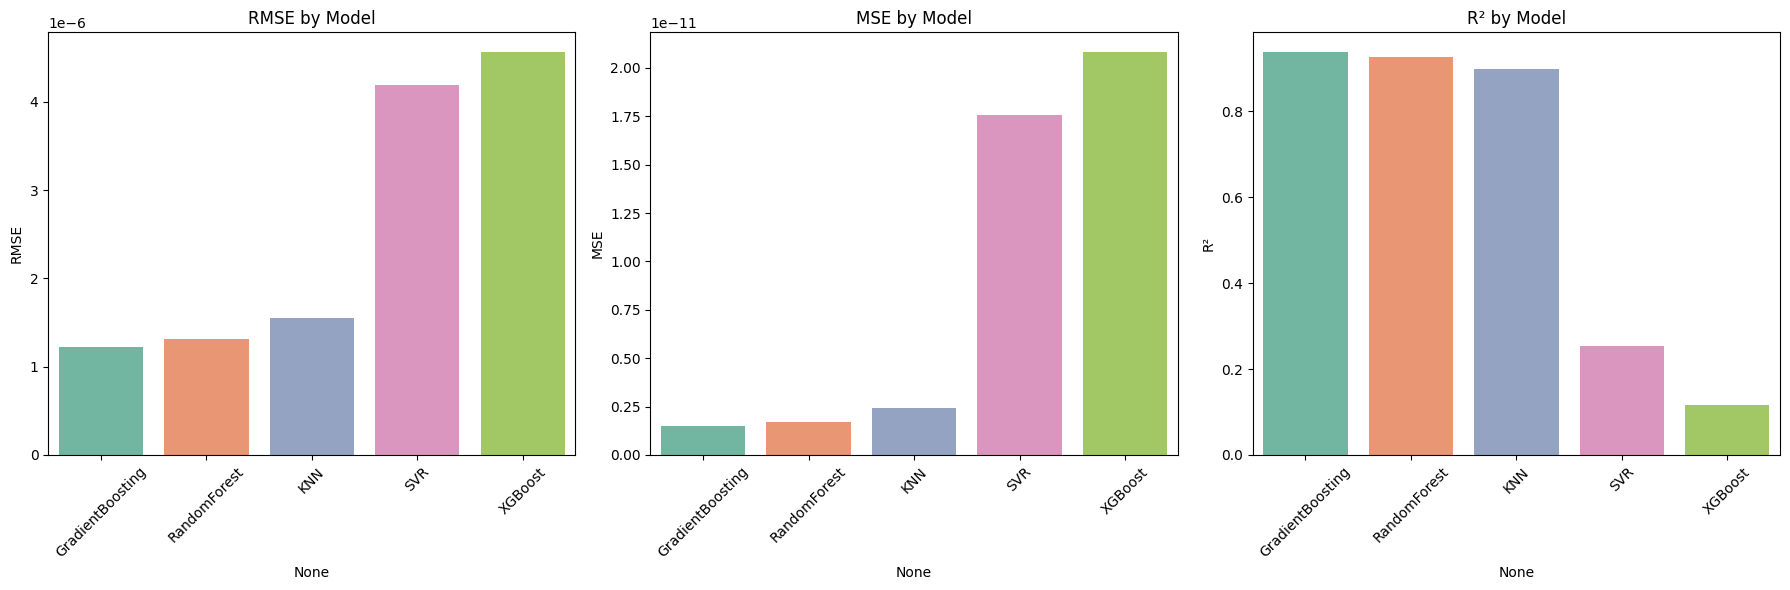

In [9]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Optional: XGBoost
try:
    from xgboost import XGBRegressor
    xgb_available = True
except ImportError:
    xgb_available = False

# Load and clean data
df = pd.read_csv("composition_features_pymatgen.csv") # Load the featurized data
drop_cols = ["Composition", "Composition_clean", "input", "normalized", "pretty_formula", 'Unnamed: 0']
# Filter out columns that exist in the DataFrame before dropping
cols_to_drop = [col for col in drop_cols if col in df.columns]

# Separate target variable before dropping columns
target_column = "CTE Value"
if target_column in df.columns:
    y = df[target_column]
    # Drop the target column from the feature set
    X = df.drop(columns=[target_column] + cols_to_drop, errors='ignore')
else:
    raise ValueError(f"Target column '{target_column}' not found in the DataFrame.")

# Ensure only numeric columns are used for features and drop rows with NaNs
X = X.select_dtypes(include=np.number)

# Print shape after dropping columns to diagnose
print("Shape of X after dropping columns:", X.shape)

X = X.dropna()
y = y.loc[X.index] # Align target variable with the cleaned feature set

# Print shape after dropping NaNs to diagnose
print("Shape of X after dropping NaNs:", X.shape)


# Normalize the target variable
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.values.reshape(-1, 1)).flatten()

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y_scaled, test_size=0.2, random_state=42)

# Models
models = {
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=0),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, random_state=0),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor(n_neighbors=5)
}
if xgb_available:
    models["XGBoost"] = XGBRegressor(n_estimators=100, random_state=0)

# Train and evaluate
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    if hasattr(y_pred, "flatten"):
        y_pred = y_pred.flatten()

    # Inverse transform predictions and actuals to original scale
    y_pred_orig = y_scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    y_test_orig = y_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    # Compute metrics in original units
    mse = np.mean((y_test_orig - y_pred_orig) ** 2)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_orig, y_pred_orig)

    results[name] = {
        "model": model, "MSE": mse, "RMSE": rmse, "R²": r2
    }

    print(f"\n{name}:")
    print(f"y_test sample: {y_test_orig[:5]}")
    print(f"y_pred sample: {y_pred_orig[:5]}")
    print(f"R² = {r2:.3f}, RMSE = {rmse:.6e}, MSE = {mse:.6e}")

# Summary DataFrame
metrics_df = pd.DataFrame(results).T[["MSE", "RMSE", "R²"]].sort_values("R²", ascending=False)

# Unique colors per model
palette = sns.color_palette("Set2", len(metrics_df))
color_dict = dict(zip(metrics_df.index, palette))

# Plot
plt.figure(figsize=(18, 6))
for i, metric in enumerate(["RMSE", "MSE", "R²"]):
    plt.subplot(1, 3, i + 1)
    sns.barplot(x=metrics_df.index, y=metric, data=metrics_df, palette=color_dict)
    plt.title(f"{metric} by Model")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


=== SHAP Summary for Gradient Boosting Regressor ===


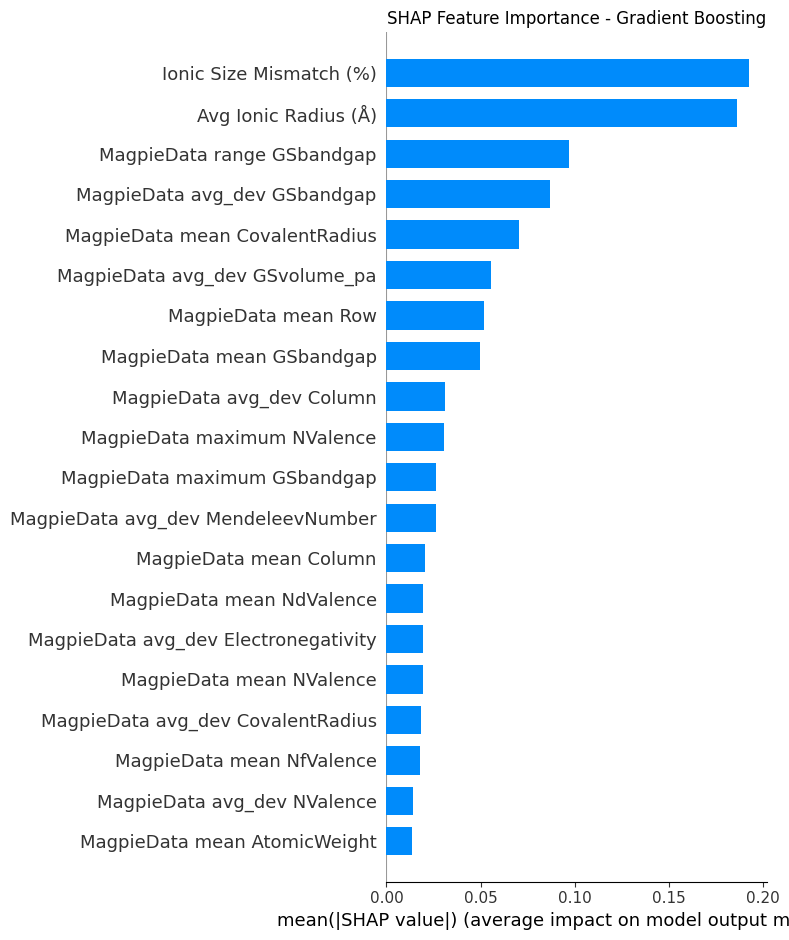

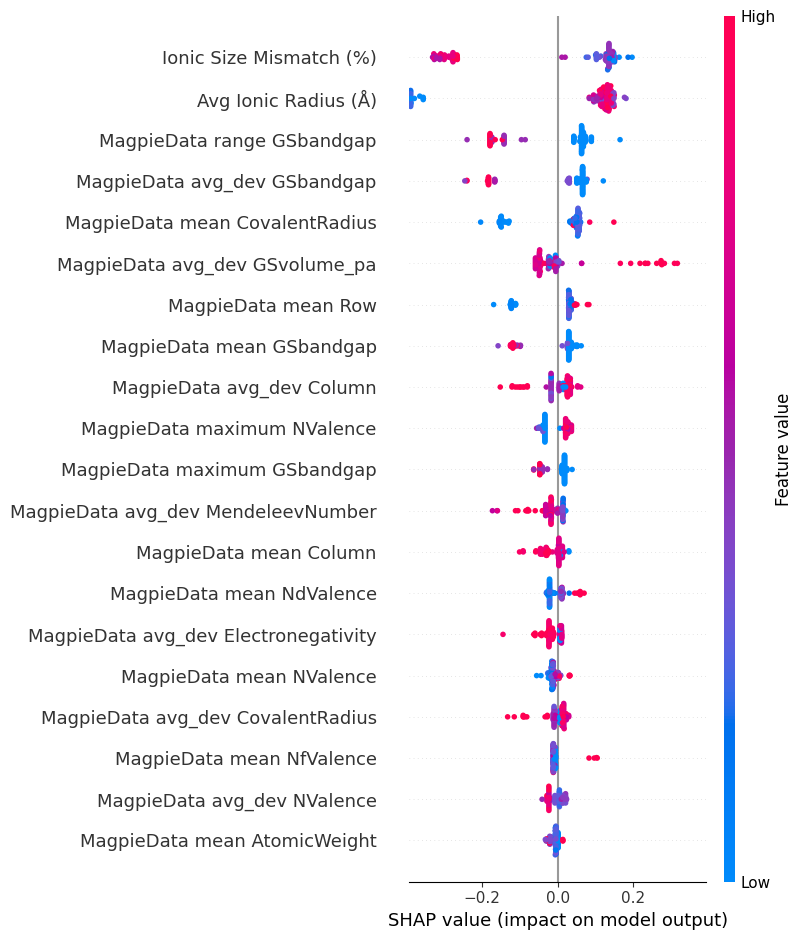

In [10]:
from sklearn.ensemble import GradientBoostingRegressor
import shap
import matplotlib.pyplot as plt
import numpy as np

# === Force use of Gradient Boosting Regressor ===
best_model_name = "GradientBoosting"
best_model = results[best_model_name]["model"]

print(f"\n=== SHAP Summary for Gradient Boosting Regressor ===")

# Confirm it's a tree-based model
if isinstance(best_model, GradientBoostingRegressor):
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X)

    # Bar plot
    shap.summary_plot(shap_values, X, plot_type="bar", show=False)
    plt.title("SHAP Feature Importance - Gradient Boosting")
    plt.tight_layout()
    plt.show()

    # Beeswarm plot
    plt.xlim(-.5 * np.max(np.abs(shap_values)), .5 * np.max(np.abs(shap_values)))  # 150% of max abs value
    shap.summary_plot(shap_values, X, plot_type="dot")
else:
    print("The selected model is not a GradientBoostingRegressor.")


# CTE Predictions

In [11]:
import pandas as pd
import numpy as np
from pymatgen.core.composition import Composition
from matminer.featurizers.composition import ElementProperty



# --- [1] Your pre-trained objects (already defined in notebook) ---
# best_model       : The Bayesian-optimized GradientBoostingRegressor
# y_scaler         : The StandardScaler used for the target "CTE (K_1)"
# X                : Your training features dataframe (used to get correct columns)

# --- [2] New compositions to predict ---
new_formulas = [
    "Y3Al5O12",
    "Ce3Al5O12",
    "La3Al5O12",
    "Y3Al5O12",
    "Dy2Yb2Nb2Ta2Ce2O7",
    "(Y1.125Nd.125Sm.125Eu.125Dy.125Ho.125Er.125Yb.125)3Al5O12",
    "(Y.5Yb.5)3Al5O12"
]

# --- [3] Featurize new compositions ---
# Convert formulas to pymatgen Composition objects
comp_objs = []
for f in new_formulas:
    try:
        comp_objs.append(Composition(f))
    except Exception as e:
        print(f"Could not parse formula {f}: {e}")
        comp_objs.append(None)

# Filter out invalid compositions before featurizing
valid_comp_objs = [c for c in comp_objs if c is not None]
valid_formulas = [f for f, c in zip(new_formulas, comp_objs) if c is not None]

feature_df = pd.DataFrame({"composition_obj": valid_comp_objs})

# Use the same featurizer as training
featurizer = ElementProperty.from_preset("magpie")
feature_df = featurizer.featurize_dataframe(feature_df, "composition_obj")

# Print featurized dataframe to diagnose
print("Featurized DataFrame for new compositions:")
pd.options.display.float_format = '{:.8f}'.format  # Show more precision when printing
display(feature_df)

# --- [4] Align columns with training data ---
# Add missing columns with 0.0 and reindex to match training columns
X_new = feature_df.reindex(columns=X.columns, fill_value=0.000)

# --- [5] Predict using optimized model ---
y_pred_scaled = best_model.predict(X_new)
y_pred_cte = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

# --- [6] Output predictions with more decimal precision ---
pred_df = pd.DataFrame({
    "Composition": valid_formulas,
    "Predicted CTE (K⁻¹)": np.round(y_pred_cte, 8)
})

print("\nPredicted CTE values:")
print(pred_df)

# --- [7] Save to CSV with 8 decimal places ---
pred_df.to_csv("cte_predictions_gradient_boost.csv", index=False, float_format="%.8f")

/usr/local/lib/python3.12/dist-packages/matminer/utils/data.py:326: UserWarning: MagpieData(impute_nan=False):
In a future release, impute_nan will be set to True by default.
                    This means that features that are missing or are NaNs for elements
                    from the data source will be replaced by the average of that value
                    over the available elements.
                    This avoids NaNs after featurization that are often replaced by
                    dataset-dependent averages.
  warnings.warn(f"{self.__class__.__name__}(impute_nan=False):\n" + IMPUTE_NAN_WARNING)


ElementProperty:   0%|          | 0/7 [00:00<?, ?it/s]

Featurized DataFrame for new compositions:


,composition_obj,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,MagpieData minimum MendeleevNumber,MagpieData maximum MendeleevNumber,MagpieData range MendeleevNumber,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,"(Y, Al, O)",8.00000000,39.00000000,31.00000000,13.90000000,7.53000000,8.00000000,12.00000000,87.00000000,75.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,225.00000000,213.00000000,92.55000000,96.66000000,12.00000000
1,"(Ce, Al, O)",8.00000000,58.00000000,50.00000000,16.75000000,12.37500000,8.00000000,15.00000000,87.00000000,72.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,225.00000000,213.00000000,92.55000000,96.66000000,12.00000000
2,"(La, Al, O)",8.00000000,57.00000000,49.00000000,16.60000000,12.12000000,8.00000000,13.00000000,87.00000000,74.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,225.00000000,213.00000000,92.55000000,96.66000000,12.00000000
3,"(Y, Al, O)",8.00000000,39.00000000,31.00000000,13.90000000,7.53000000,8.00000000,12.00000000,87.00000000,75.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,225.00000000,213.00000000,92.55000000,96.66000000,12.00000000
4,"(Dy, Yb, Nb, Ta, Ce, O)",8.00000000,73.00000000,65.00000000,39.52941176,25.96539792,8.00000000,15.00000000,87.00000000,72.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,229.00000000,217.00000000,130.94117647,97.95155709,12.00000000
5,"(Y, Nd, Sm, Eu, Dy, Ho, Er, Yb, Al, O)",8.00000000,70.00000000,62.00000000,20.15760870,15.79820416,8.00000000,12.00000000,87.00000000,75.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,229.00000000,217.00000000,106.40217391,98.50661626,12.00000000
6,"(Y, Yb, Al, O)",8.00000000,70.00000000,62.00000000,16.22500000,11.48250000,8.00000000,12.00000000,87.00000000,75.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,225.00000000,213.00000000,94.87500000,99.45000000,12.00000000



Predicted CTE values:
                                         Composition  Predicted CTE (K⁻¹)
0                                           Y3Al5O12           0.00000674
1                                          Ce3Al5O12           0.00000738
2                                          La3Al5O12           0.00000738
3                                           Y3Al5O12           0.00000674
4                                  Dy2Yb2Nb2Ta2Ce2O7           0.00000626
5  (Y1.125Nd.125Sm.125Eu.125Dy.125Ho.125Er.125Yb....           0.00000660
6                                   (Y.5Yb.5)3Al5O12           0.00000721


In [12]:
import pandas as pd
import numpy as np
from pymatgen.core.composition import Composition
from matminer.featurizers.composition import ElementProperty

# --- [1] Your pre-trained objects (already defined in notebook) ---
# best_model       : The Bayesian-optimized GradientBoostingRegressor
# y_scaler         : The StandardScaler used for the target "CTE (K_1)"
# X                : Your training features dataframe (used to get correct columns)

# --- [2] New compositions to predict ---
new_formulas = [
    "Y3Al5O12",
    "Y1.5Dy1.5Al5O12",
    "Y.9999Dy.9999Ho.9999Al5O12",
    "Y.75Dy.75Ho.75Er.75Al5O12",
    "Y.6La.6Dy.6Ho.6Er.6Al5O12",
    "Y.60Nd.60Dy.60Ho.60Er.6Al5O12",
    "(Y0.1666Nd0.1666Sm0.1666Dy0.1666Ho0.1666Er0.1666)3Al5O12",
    "(Y0.14285Nd0.14285Sm0.14285Eu0.14285Dy0.14285Ho0.14285Er0.14285)3Al5O12 ",
    "Y3Fe5O12",
    "Y3Fe2.50Al2.50O12",
    "Y3Fe2.475Al2.475Mn0.05O12",
    "Y3Fe2.475Al2.475Co0.05O12",
    "Y3Fe2.475Al2.475Ni0.05O12",
    "Y3Fe2.475Al2.475Cu0.05O12",
    "Y3Fe2.45Al2.45Mn0.025Co0.025Ni0.025Cu0.025O12",
    "Y.6Eu.6Dy.6Ho.6Er.6Al5O12",
    "La.666Gd.666Lu.666TiZrO7",
    "Pr.4Nd.4Gd.4Yb.4Lu.4Ti2O7",
    "Pr.4Sm.4Gd.4Ho.4Lu2Ti2O7",
    "Sm.4Eu.4Gd.4Tb.4Dy.4Ti2O7",
    "Sm.4Eu.4Ho.4Er.4Yb.4Ti2O7",
    "Eu.5Gd.5Ho.5Er.5Ti2O7",
    "GdHoTi2O7",
    "Nd.4Sm.4Eu.4Gd.4Dy.4Ti2O7"
]

# --- [3] Featurize new compositions ---
# Convert formulas to pymatgen Composition objects
comp_objs = []
for f in new_formulas:
    try:
        comp_objs.append(Composition(f))
    except Exception as e:
        print(f"Could not parse formula {f}: {e}")
        comp_objs.append(None)

# Filter out invalid compositions before featurizing
valid_comp_objs = [c for c in comp_objs if c is not None]
valid_formulas = [f for f, c in zip(new_formulas, comp_objs) if c is not None]

feature_df = pd.DataFrame({"composition_obj": valid_comp_objs})

# Use the same featurizer as training
featurizer = ElementProperty.from_preset("magpie")
feature_df = featurizer.featurize_dataframe(feature_df, "composition_obj")

# Print featurized dataframe to diagnose
print("Featurized DataFrame for new compositions:")
display(feature_df)

# --- [4] Align columns with training data ---
# Add missing columns with 0.0 and reindex to match training columns
X_new = feature_df.reindex(columns = X.columns, fill_value=0.000)

# --- [5] Predict using optimized model ---
y_pred_scaled = best_model.predict(X_new)
y_pred_cte = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

# --- [6] Output predictions ---
pred_df = pd.DataFrame({
    "Composition": valid_formulas,
    "Predicted CTE (K⁻¹)": y_pred_cte
})
print(pred_df)

# --- [7] Save to CSV ---
pred_df.to_csv("cte_predictions_gradient_boost.csv", index=False)

/usr/local/lib/python3.12/dist-packages/matminer/utils/data.py:326: UserWarning: MagpieData(impute_nan=False):
In a future release, impute_nan will be set to True by default.
                    This means that features that are missing or are NaNs for elements
                    from the data source will be replaced by the average of that value
                    over the available elements.
                    This avoids NaNs after featurization that are often replaced by
                    dataset-dependent averages.
  warnings.warn(f"{self.__class__.__name__}(impute_nan=False):\n" + IMPUTE_NAN_WARNING)


ElementProperty:   0%|          | 0/24 [00:00<?, ?it/s]

Featurized DataFrame for new compositions:


,composition_obj,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,MagpieData minimum MendeleevNumber,MagpieData maximum MendeleevNumber,MagpieData range MendeleevNumber,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,"(Y, Al, O)",8.00000000,39.00000000,31.00000000,13.90000000,7.53000000,8.00000000,12.00000000,87.00000000,75.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,225.00000000,213.00000000,92.55000000,96.66000000,12.00000000
1,"(Y, Dy, Al, O)",8.00000000,66.00000000,58.00000000,15.92500000,10.97250000,8.00000000,12.00000000,87.00000000,75.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,225.00000000,213.00000000,92.55000000,96.66000000,12.00000000
2,"(Y, Dy, Ho, Al, O)",8.00000000,67.00000000,59.00000000,16.64938974,12.20414562,8.00000000,12.00000000,87.00000000,75.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,225.00000000,213.00000000,92.54847823,96.65962377,12.00000000
3,"(Y, Dy, Ho, Er, Al, O)",8.00000000,68.00000000,60.00000000,17.05000000,12.88500000,8.00000000,12.00000000,87.00000000,75.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,225.00000000,213.00000000,92.55000000,96.66000000,12.00000000
4,"(Y, La, Dy, Ho, Er, Al, O)",8.00000000,68.00000000,60.00000000,16.96000000,12.73200000,8.00000000,12.00000000,87.00000000,75.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,225.00000000,213.00000000,92.55000000,96.66000000,12.00000000
5,"(Y, Nd, Dy, Ho, Er, Al, O)",8.00000000,68.00000000,60.00000000,17.05000000,12.88500000,8.00000000,12.00000000,87.00000000,75.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,225.00000000,213.00000000,92.55000000,96.66000000,12.00000000
6,"(Y, Nd, Sm, Dy, Ho, Er, Al, O)",8.00000000,68.00000000,60.00000000,17.09740584,12.96636792,8.00000000,12.00000000,87.00000000,75.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,225.00000000,213.00000000,91.84415065,95.81872990,12.00000000
7,"(Y, Nd, Sm, Eu, Dy, Ho, Er, Al, O)",8.00000000,68.00000000,60.00000000,17.15681618,13.06668550,8.00000000,12.00000000,87.00000000,75.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,229.00000000,217.00000000,92.69923274,96.83980559,12.00000000
8,"(Y, Fe, O)",8.00000000,39.00000000,31.00000000,17.15000000,10.98000000,8.00000000,12.00000000,87.00000000,75.00000000,...,2.11066280,0.52766570,0.79149855,0.00000000,12.00000000,229.00000000,217.00000000,93.55000000,97.86000000,12.00000000
9,"(Y, Fe, Al, O)",8.00000000,39.00000000,31.00000000,15.52500000,9.66125000,8.00000000,12.00000000,87.00000000,75.00000000,...,2.11066280,0.26383285,0.46170749,0.00000000,12.00000000,229.00000000,217.00000000,93.05000000,97.26000000,12.00000000


                                          Composition  Predicted CTE (K⁻¹)
0                                            Y3Al5O12           0.00000674
1                                     Y1.5Dy1.5Al5O12           0.00000682
2                          Y.9999Dy.9999Ho.9999Al5O12           0.00000744
3                           Y.75Dy.75Ho.75Er.75Al5O12           0.00000764
4                           Y.6La.6Dy.6Ho.6Er.6Al5O12           0.00000744
5                       Y.60Nd.60Dy.60Ho.60Er.6Al5O12           0.00000733
6   (Y0.1666Nd0.1666Sm0.1666Dy0.1666Ho0.1666Er0.16...           0.00000778
7   (Y0.14285Nd0.14285Sm0.14285Eu0.14285Dy0.14285H...           0.00000775
8                                            Y3Fe5O12           0.00000789
9                                   Y3Fe2.50Al2.50O12           0.00000775
10                          Y3Fe2.475Al2.475Mn0.05O12           0.00000775
11                          Y3Fe2.475Al2.475Co0.05O12           0.00000775
12                       

Shape of X after dropping columns: (118, 209)
Shape of X after dropping NaNs: (118, 209)

RandomForest: R²=0.9148, RMSE=1.415916e-06, MSE=2.004818e-12

GradientBoosting: R²=0.9366, RMSE=1.221176e-06, MSE=1.491271e-12

ExtraTrees: R²=0.8365, RMSE=1.961304e-06, MSE=3.846712e-12

DecisionTree: R²=0.8106, RMSE=2.111014e-06, MSE=4.456379e-12

Ridge: R²=0.8837, RMSE=1.654641e-06, MSE=2.737838e-12

Lasso: R²=0.8663, RMSE=1.773528e-06, MSE=3.145400e-12

ElasticNet: R²=0.8738, RMSE=1.723086e-06, MSE=2.969026e-12

BayesianRidge: R²=0.8741, RMSE=1.720909e-06, MSE=2.961527e-12

Huber: R²=0.7770, RMSE=2.290656e-06, MSE=5.247103e-12

TheilSen: R²=-0.7117, RMSE=6.346501e-06, MSE=4.027807e-11
Tweedie failed: Some value(s) of y are out of the valid range of the loss 'HalfTweedieLoss'.

Quantile: R²=0.8647, RMSE=1.784543e-06, MSE=3.184593e-12

SVR: R²=0.8286, RMSE=2.008317e-06, MSE=4.033339e-12

NuSVR: R²=0.3563, RMSE=3.891908e-06, MSE=1.514695e-11

KNN: R²=0.8743, RMSE=1.719816e-06, MSE=2.957767e-12

M

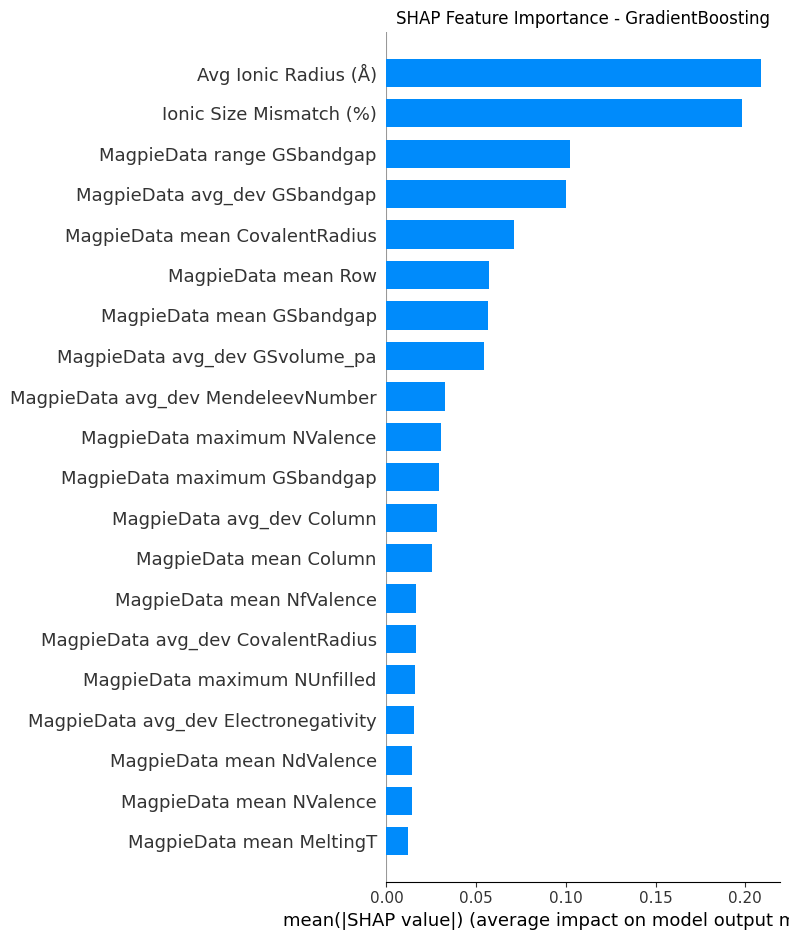

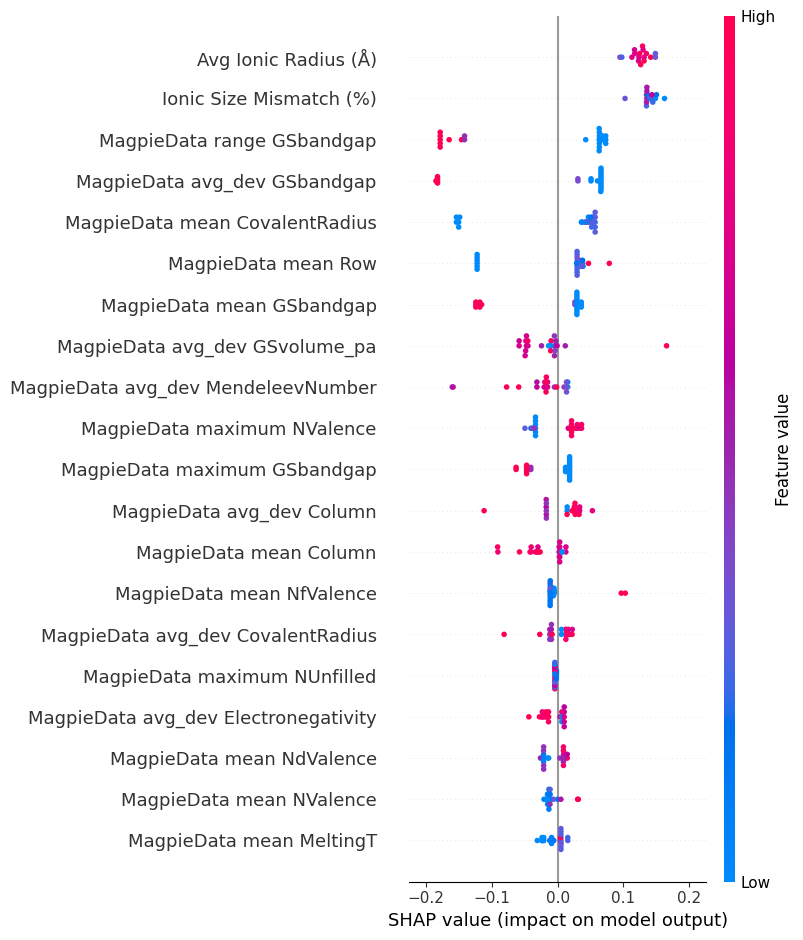


=== SHAP for RandomForest ===


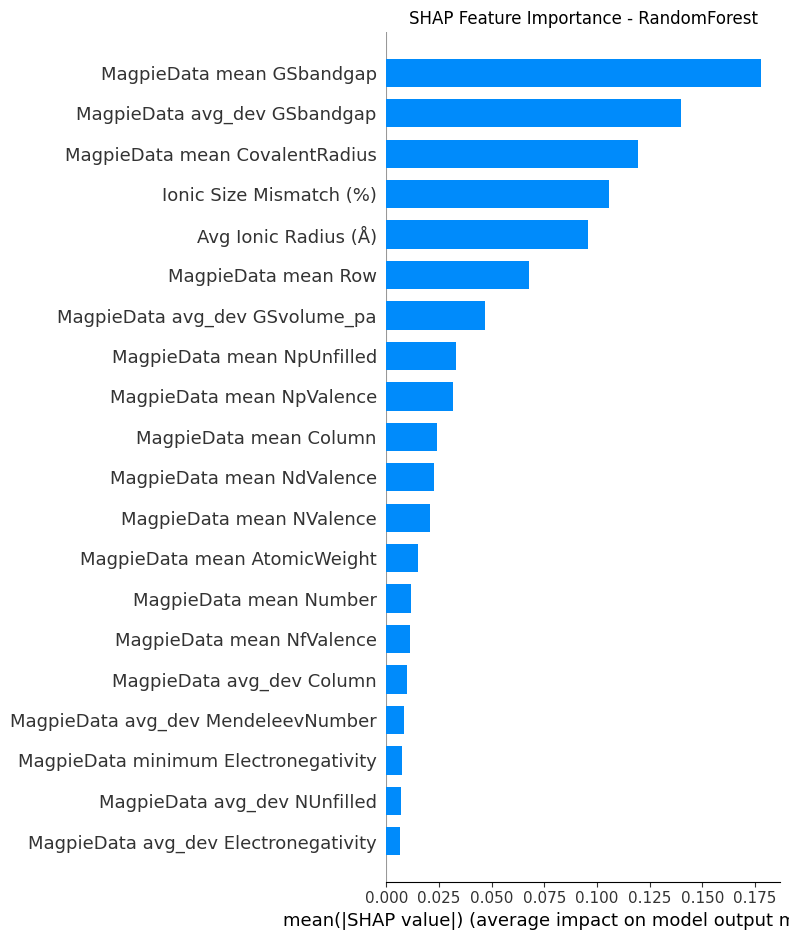

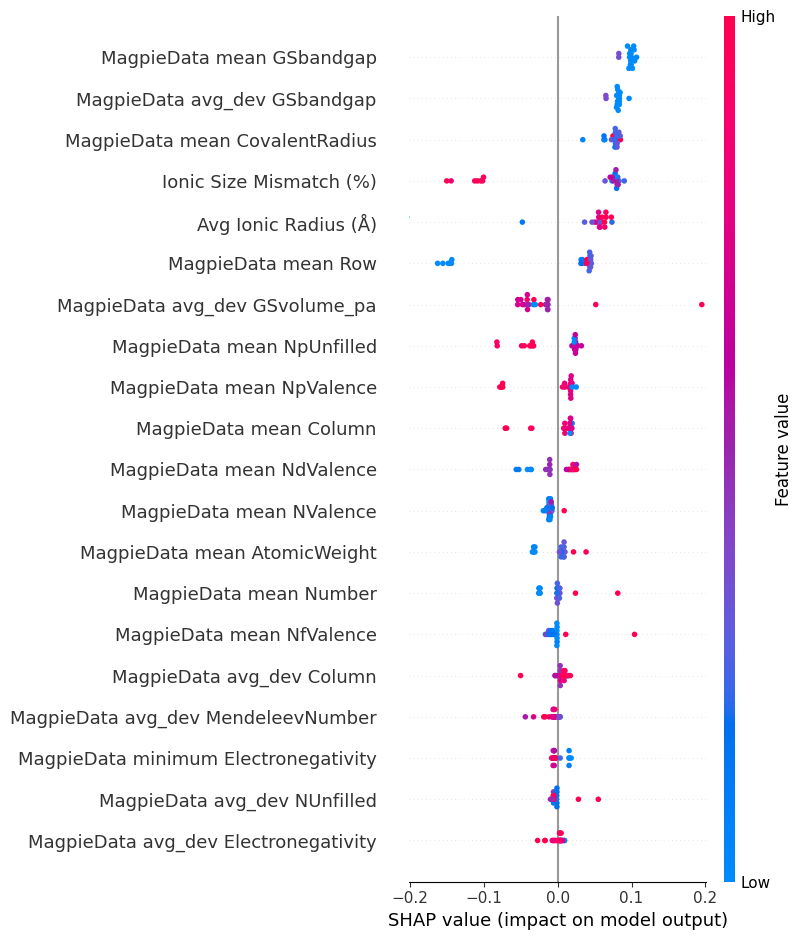


=== SHAP for Bagging_RF ===


  0%|          | 0/24 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [13]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
    StackingRegressor,
    VotingRegressor,
    AdaBoostRegressor,
    BaggingRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import (
    Ridge,
    Lasso,
    ElasticNet,
    BayesianRidge,
    HuberRegressor,
    TheilSenRegressor,
    TweedieRegressor,
    QuantileRegressor
)
from sklearn.svm import SVR, NuSVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# ---- Optional external libs ----
xgb_available = lgb_available = cat_available = False
try:
    from xgboost import XGBRegressor
    xgb_available = True
except Exception:
    pass

try:
    from lightgbm import LGBMRegressor
    lgb_available = True
except Exception:
    pass

try:
    from catboost import CatBoostRegressor
    cat_available = True
except Exception:
    pass

warnings.filterwarnings("ignore")

# =========================
# Load and clean data
# =========================
df = pd.read_csv("composition_features_pymatgen.csv")
drop_cols = ["Composition", "Composition_clean", "input", "normalized", "pretty_formula", "Unnamed: 0"]
cols_to_drop = [c for c in drop_cols if c in df.columns]

target_column = "CTE Value"
if target_column not in df.columns:
    raise ValueError(f"Target column '{target_column}' not found.")

y = df[target_column]
X = df.drop(columns=[target_column] + cols_to_drop, errors="ignore").select_dtypes(include=np.number)

print("Shape of X after dropping columns:", X.shape)

# Drop NaNs and align
X = X.dropna(axis=0)
y = y.loc[X.index]
print("Shape of X after dropping NaNs:", X.shape)

# Scale target (inverse later for metrics in original units)
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.values.reshape(-1, 1)).ravel()

# =========================
# Train/test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(X, y_scaled, test_size=0.2, random_state=42)

# =========================
# Model zoo (expanded)
# =========================
models = {
    # Tree models
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=0, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=0),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=500, random_state=0, n_jobs=-1),
    "DecisionTree": DecisionTreeRegressor(random_state=0),

    # Linear & regularized
    "Ridge": Ridge(alpha=1.0, random_state=0),
    "Lasso": Lasso(alpha=1e-3, random_state=0, max_iter=10000),
    "ElasticNet": ElasticNet(alpha=1e-3, l1_ratio=0.5, random_state=0, max_iter=10000),
    "BayesianRidge": BayesianRidge(),
    "Huber": HuberRegressor(),
    "TheilSen": TheilSenRegressor(),
    "Tweedie": TweedieRegressor(power=1, alpha=0.5),
    "Quantile": QuantileRegressor(quantile=0.5, alpha=0.1, solver="highs"),

    # SVM/KNN
    "SVR": SVR(C=10.0, epsilon=0.01, kernel="rbf"),
    "NuSVR": NuSVR(kernel="rbf", C=1.0, nu=0.5),
    "KNN": KNeighborsRegressor(n_neighbors=7),

    # Neural net
    "MLP": MLPRegressor(hidden_layer_sizes=(100,), max_iter=2000, random_state=0),

    # Histogram GB
    "HistGBR": HistGradientBoostingRegressor(random_state=0),

    # Gaussian Process
    "GaussianProcess": GaussianProcessRegressor(
        kernel=RBF(length_scale=1.0) + WhiteKernel(noise_level=1.0),
        normalize_y=True, random_state=0
    ),

    # Partial Least Squares
    "PLS": PLSRegression(n_components=5),

    # Polynomial Regression
    "Poly2": Pipeline([
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("lin", Ridge(alpha=1.0))
    ]),

    # Boosting/Bagging ensembles
    "AdaBoost": AdaBoostRegressor(n_estimators=300, random_state=0),
    "Bagging_RF": BaggingRegressor(
        estimator=RandomForestRegressor(n_estimators=50),
        n_estimators=20, random_state=0
    ),
}

if xgb_available:
    models["XGBoost"] = XGBRegressor(
        n_estimators=800, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=0, n_jobs=-1, tree_method="hist"
    )
if lgb_available:
    models["LightGBM"] = LGBMRegressor(
        n_estimators=800, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=0, n_jobs=-1
    )
if cat_available:
    models["CatBoost"] = CatBoostRegressor(
        iterations=1000, learning_rate=0.05, depth=6, random_seed=0, verbose=False
    )

# =========================
# Train & Evaluate
# =========================
results = {}
for name, model in models.items():
    try:
        model.fit(X_train, y_train)
        y_pred = np.asarray(model.predict(X_test)).ravel()

        y_pred_orig = y_scaler.inverse_transform(y_pred.reshape(-1, 1)).ravel()
        y_test_orig = y_scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()

        mse = np.mean((y_test_orig - y_pred_orig) ** 2)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test_orig, y_pred_orig)

        results[name] = {"model": model, "MSE": mse, "RMSE": rmse, "R²": r2}
        print(f"\n{name}: R²={r2:.4f}, RMSE={rmse:.6e}, MSE={mse:.6e}")
    except Exception as e:
        print(f"{name} failed: {e}")

metrics_df = pd.DataFrame(results).T[["MSE", "RMSE", "R²"]].sort_values("R²", ascending=False)
print("\n=== Summary ===")
print(metrics_df)

# =========================
# SHAP on top-N models
# =========================
TOP_N_FOR_SHAP = 6
background_sample_size = 200
shap_sample_size = 400

tree_model_types = tuple([
    RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, DecisionTreeRegressor
] + ([XGBRegressor] if xgb_available else [])
  + ([LGBMRegressor] if lgb_available else [])
  + ([CatBoostRegressor] if cat_available else [])
)

top_models = metrics_df.head(TOP_N_FOR_SHAP).index.tolist()
print(f"\nRunning SHAP on top {len(top_models)} models by R²:", top_models)

rng = np.random.RandomState(42)
bg_idx = rng.choice(X_train.index, size=min(background_sample_size, len(X_train)), replace=False)
sample_idx = rng.choice(X_test.index, size=min(shap_sample_size, len(X_test)), replace=False)

X_bg = X.loc[bg_idx]
X_samp = X.loc[sample_idx]

for name in top_models:
    model = results[name]["model"]
    print(f"\n=== SHAP for {name} ===")
    try:
        if isinstance(model, tree_model_types):
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_samp)
        else:
            explainer = shap.KernelExplainer(model.predict, shap.sample(X_bg, min(len(X_bg), 200), random_state=42))
            shap_values = explainer.shap_values(X_samp, nsamples="auto")

        shap.summary_plot(shap_values, X_samp, plot_type="bar", show=False)
        plt.title(f"SHAP Feature Importance - {name}")
        plt.tight_layout()
        plt.show()

        max_abs = np.max(np.abs(shap_values))
        plt.xlim(-0.5 * max_abs, 0.5 * max_abs)
        shap.summary_plot(shap_values, X_samp, plot_type="dot")
    except Exception as e:
        print(f"SHAP failed for {name}: {e}")

# =========================
# Metric plots
# =========================
palette = sns.color_palette("Set2", len(metrics_df))
color_dict = dict(zip(metrics_df.index, palette))

plt.figure(figsize=(18, 6))
for i, metric in enumerate(["RMSE", "MSE", "R²"]):
    plt.subplot(1, 3, i + 1)
    sns.barplot(x=metrics_df.index, y=metric, data=metrics_df, palette=color_dict)
    plt.title(f"{metric} by Model")
    plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from pymatgen.core.composition import Composition
from matminer.featurizers.composition import ElementProperty

# --- [1] Your trained models ---
# Assumes `results` is a dict like: results[model_name] = {"model": model, "R²": ..., ...}
# And y_scaler is your StandardScaler for the target

# Use ALL models instead of only the top N
all_models = list(results.items())
print(f"Using all {len(all_models)} models: {[m[0] for m in all_models]}")

# --- [2] New compositions to predict ---
new_formulas = [
    "Y3Al5O12",
    "Y1.5Dy1.5Al5O12",
    "Y.9999Dy.9999Ho.9999Al5O12",
    "Y.75Dy.75Ho.75Er.75Al5O12",
    "Y.6La.6Dy.6Ho.6Er.6Al5O12",
    "Y.60Nd.60Dy.60Ho.60Er.6Al5O12",
    "(Y0.1666Nd0.1666Sm0.1666Dy0.1666Ho0.1666Er0.1666)3Al5O12",
    "(Y0.14285Nd0.14285Sm0.14285Eu0.14285Dy0.14285Ho0.14285Er0.14285)3Al5O12 ",
    "Y3Fe5O12",
    "Y3Fe2.50Al2.50O12",
    "Y3Fe2.475Al2.475Mn0.05O12",
    "Y3Fe2.475Al2.475Co0.05O12",
    "Y3Fe2.475Al2.475Ni0.05O12",
    "Y3Fe2.475Al2.475Cu0.05O12",
    "Y3Fe2.45Al2.45Mn0.025Co0.025Ni0.025Cu0.025O12",
    "Y.6Eu.6Dy.6Ho.6Er.6Al5O12",
    "La.666Gd.666Lu.666TiZrO7",
    "Pr.4Nd.4Gd.4Yb.4Lu.4Ti2O7",
    "Pr.4Sm.4Gd.4Ho.4Lu2Ti2O7",
    "Sm.4Eu.4Gd.4Tb.4Dy.4Ti2O7",
    "Sm.4Eu.4Ho.4Er.4Yb.4Ti2O7",
    "Eu.5Gd.5Ho.5Er.5Ti2O7",
    "GdHoTi2O7",
    "Nd.4Sm.4Eu.4Gd.4Dy.4Ti2O7"
]

# --- [3] Featurize new compositions ---
comp_objs = []
for f in new_formulas:
    try:
        comp_objs.append(Composition(f))
    except Exception as e:
        print(f"Could not parse formula {f}: {e}")
        comp_objs.append(None)

valid_comp_objs = [c for c in comp_objs if c is not None]
valid_formulas = [f for f, c in zip(new_formulas, comp_objs) if c is not None]

feature_df = pd.DataFrame({"composition_obj": valid_comp_objs})
featurizer = ElementProperty.from_preset("magpie")
feature_df = featurizer.featurize_dataframe(feature_df, "composition_obj")

# --- [4] Align columns with training data ---
X_new = feature_df.reindex(columns=X.columns, fill_value=0.0)

# --- [5] Predict with each model in results ---
all_preds = {"Composition": valid_formulas}
for name, info in all_models:
    model = info["model"]
    y_pred_scaled = model.predict(X_new)
    y_pred_cte = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    all_preds[f"Predicted CTE ({name})"] = y_pred_cte

# --- [6] Output predictions ---
pred_df = pd.DataFrame(all_preds)
print(pred_df)

# --- [7] Save to CSV ---
pred_df.to_csv("cte_predictions_all_models.csv", index=False)


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# ---------------- Experimental Data ----------------
experimental_data = {
    "La.666Gd.666Lu.666TiZrO7": 10.26370957e-6,
    "Pr.4Nd.4Gd.4Yb.4Lu.4Ti2O7": 10.8812864e-6,
    "Pr.4Sm.4Gd.4Ho.4Lu2Ti2O7": 10.97135822e-6,
    "Sm.4Eu.4Gd.4Tb.4Dy.4Ti2O7": 11.18713217e-6,
    "Sm.4Eu.4Ho.4Er.4Yb.4Ti2O7": 10.83446e-6,
    "Eu.5Gd.5Ho.5Er.5Ti2O7": 10.66338e-6,
    "GdHoTi2O7": 10.68365e-6,
    "Nd.4Sm.4Eu.4Gd.4Dy.4Ti2O7": 10.94286e-6,
}

# ---------------- Build DataFrame (rows 16–23 updated from your new table) ----------------
df = pd.DataFrame({
    "Formula": [
        "La.666Gd.666Lu.666TiZrO7",
        "Pr.4Nd.4Gd.4Yb.4Lu.4Ti2O7",
        "Pr.4Sm.4Gd.4Ho.4Lu2Ti2O7",
        "Sm.4Eu.4Gd.4Tb.4Dy.4Ti2O7",
        "Sm.4Eu.4Ho.4Er.4Yb.4Ti2O7",
        "Eu.5Gd.5Ho.5Er.5Ti2O7",
        "GdHoTi2O7",
        "Nd.4Sm.4Eu.4Gd.4Dy.4Ti2O7"
    ],

    # Tree-based models (from indices 16–23)
    "Predicted CTE (RandomForest)":     [9.43e-6, 9.24e-6, 8.62e-6, 9.44e-6, 9.09e-6, 9.10e-6, 9.09e-6, 9.44e-6],
    "Predicted CTE (GradientBoosting)": [7.27e-6, 6.81e-6, 5.72e-6, 7.21e-6, 6.50e-6, 6.71e-6, 6.88e-6, 7.05e-6],
    "Predicted CTE (ExtraTrees)":       [10.92e-6, 10.81e-6, 9.75e-6, 10.54e-6, 10.43e-6, 10.53e-6, 10.59e-6, 10.56e-6],
    "Predicted CTE (DecisionTree)":     [11.50e-6, 11.58e-6, 9.04e-6, 11.38e-6, 11.58e-6, 10.72e-6, 11.52e-6, 11.38e-6],

    # Linear models
    "Predicted CTE (Ridge)":            [7.37e-6, 8.84e-6, 6.59e-6, 8.47e-6, 8.44e-6, 8.80e-6, 7.87e-6, 8.63e-6],
    "Predicted CTE (Lasso)":            [10.37e-6, 10.56e-6, 10.87e-6, 10.58e-6, 10.62e-6, 10.84e-6, 9.93e-6, 10.65e-6],
    "Predicted CTE (ElasticNet)":       [8.98e-6, 9.51e-6, 9.67e-6, 9.20e-6, 9.04e-6, 9.53e-6, 8.45e-6, 9.45e-6],
    "Predicted CTE (BayesianRidge)":    [13.47e-6, 13.67e-6, 13.22e-6, 12.47e-6, 13.25e-6, 12.77e-6, 12.20e-6, 12.85e-6],

    # Robust regressors
    "Predicted CTE (Huber)":            [13.71e-6, 13.29e-6, 13.62e-6, 12.30e-6, 13.27e-6, 12.81e-6, 12.32e-6, 12.44e-6],

    # Kernel & neighbors
    "Predicted CTE (KNN)":              [11.34e-6, 9.67e-6, 8.98e-6, 9.14e-6, 9.67e-6, 8.83e-6, 8.82e-6, 9.67e-6],
    "Predicted CTE (GaussianProcess)":  [10.98e-6, 8.18e-6, 8.36e-6, 8.12e-6, 8.30e-6, 7.89e-6, 7.56e-6, 8.39e-6],

    # Neural net / boosted variants
    "Predicted CTE (MLP)":              [-20.40e-6, -119.31e-6, -69.18e-6, -112.78e-6, -123.04e-6, -120.96e-6, -66.18e-6, -112.37e-6],
    "Predicted CTE (HistGBR)":          [11.84e-6, 11.72e-6, 12.07e-6, 11.60e-6, 12.62e-6, 11.88e-6, 11.76e-6, 11.41e-6],
    "Predicted CTE (AdaBoost)":         [11.04e-6, 11.12e-6, 9.64e-6, 11.12e-6, 10.59e-6, 11.12e-6, 11.12e-6, 11.12e-6],

    # Ensembles / GBDTs
    "Predicted CTE (Bagging_RF)":       [9.83e-6, 9.71e-6, 9.19e-6, 9.85e-6, 9.64e-6, 9.66e-6, 9.60e-6, 9.82e-6],
    "Predicted CTE (XGBoost)":          [3.58e-6, 3.39e-6, 2.94e-6, 3.27e-6, 3.15e-6, 3.17e-6, 3.20e-6, 3.29e-6],
    "Predicted CTE (LightGBM)":         [15.31e-6, 13.93e-6, 14.91e-6, 13.29e-6, 14.21e-6, 13.73e-6, 12.66e-6, 13.45e-6],

    # Other regressors
    "Predicted CTE (PLS)":              [8.44e-6, 8.74e-6, 8.95e-6, 8.35e-6, 8.43e-6, 8.39e-6, 8.11e-6, 8.45e-6],
    "Predicted CTE (Poly2)":            [-21.17e-6, -16.39e-6, -3.24e-6, -19.57e-6, -21.68e-6, -20.63e-6, -21.69e-6, -16.79e-6],
})

# Add experimental values
df["Experimental"] = df["Formula"].map(experimental_data)

# ---------------- Collect model columns ----------------
model_cols = [c for c in df.columns if c.startswith("Predicted CTE")]

# ---------------- Plotting ----------------
plt.figure(figsize=(20, 12))
for model in model_cols:
    plt.plot(df["Formula"], df[model], marker="o", linestyle="--", alpha=0.6, label=model)

# Plot experimental
plt.plot(df["Formula"], df["Experimental"], marker="s", color="black", linewidth=3, label="Experimental")

plt.xticks(rotation=45, ha="right")
plt.ylabel("CTE (K$^{-1}$)")
plt.title("Predicted vs Experimental CTE across Models (Updated with new values for rows 16–23)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import re

# ---------------- Predicted Data (DecisionTree only; rows 15–22) ----------------
predicted_data = {
    "La.666Gd.666Lu.666TiZrO7": 9.28e-6,
    "Pr.4Nd.4Gd.4Yb.4Lu.4Ti2O7": 11.00e-6,
    "Pr.4Sm.4Gd.4Ho.4Lu2Ti2O7": 10.72e-6,
    "Sm.4Eu.4Gd.4Tb.4Dy.4Ti2O7": 10.21e-6,
    "Sm.4Eu.4Ho.4Er.4Yb.4Ti2O7": 11.59e-6,
    "Eu.5Gd.5Ho.5Er.5Ti2O7": 10.76e-6,
    "GdHoTi2O7": 10.76e-6,
    "Nd.4Sm.4Eu.4Gd.4Dy.4Ti2O7": 10.76e-6,
}

# ---------------- Experimental Data ----------------
experimental_data = {
    "[La/Gd/Lu]2[Ti/Zr]2O7": 10.26370957e-6,
    "[Pr/Nd/Gd/Yb/Lu]2Ti2O7": 10.8812864e-6,
    "[Pr/Sm/Gd/Ho/Lu]2Ti2O7": 10.97135822e-6,
    "[Sm/Eu/Gd/Tb/Dy]2Ti2O7": 11.18713217e-6,
    "[Sm/Eu/Ho/Er/Yb]2Ti2O7": 10.83446e-6,
    "[Eu/Gd/Ho/Er]2Ti2O7": 10.66338e-6,
    "[Gd/Ho]2Ti2O7": 10.68365e-6,
    "[Nd/Sm/Eu/Gd/Dy]2Ti2O7": 10.94286e-6,
}

# ---------------- Helpers ----------------
def count_unique_elements(formula: str) -> int:
    elements = re.findall(r'[A-Z][a-z]?', formula)
    return len(set(elements))

def map_key(key: str) -> str:
    return "".join(re.findall(r'[A-Z][a-z]?', key))

# Create unified dataset (map predicted + experimental)
combined = []
for pkey, pval in predicted_data.items():
    short = map_key(pkey)
    match = None
    for ekey, eval_ in experimental_data.items():
        if map_key(ekey) == short:
            match = eval_
            break
    combined.append((pkey, pval, match))

# Sort by compositional complexity
combined_sorted = sorted(combined, key=lambda x: count_unique_elements(x[0]))

# ---------------- Plotting ----------------
plt.figure(figsize=(16, 8))

labels = [c[0] for c in combined_sorted]
pred_vals = [c[1] for c in combined_sorted]
exp_vals = [c[2] for c in combined_sorted]

# Plot predicted (DecisionTree)
plt.scatter(range(len(pred_vals)), pred_vals, s=150, color="blue",
            label="Predicted (DecisionTree)", marker="o")
# Plot experimental
plt.scatter(range(len(exp_vals)), exp_vals, s=150, color="red",
            label="Experimental", marker="s")

# Annotate with values
for i, (p, e) in enumerate(zip(pred_vals, exp_vals)):
    plt.text(i, p, f"{p:.2e}", ha="center", va="bottom",
             fontsize=8, color="blue", rotation=45)
    if e is not None:
        plt.text(i, e, f"{e:.2e}", ha="center", va="top",
                 fontsize=8, color="red", rotation=45)

plt.xticks(range(len(labels)), labels, rotation=45, ha="right", fontsize=10)
plt.ylabel("CTE (K$^{-1}$)", fontsize=12)
plt.title("Ti$_2$O$_7$ Pyrochlore Systems — DecisionTree Predicted vs Experimental", fontsize=14)
plt.legend()
plt.subplots_adjust(bottom=0.3)
plt.tight_layout()
plt.show()


# Your Turn

You're final dataset for model training will be the file "composition_features_pymatgen.csv"

Initial Feature Selection Plan

Address High-Dimensional Issue

Reduce overfitting and improve model interpretability by pruning redundant or noisy features before training.

Three-Stage Feature Selection Workflow
(a) Correlation Pruning

Remove one of any feature pairs with |r| > 0.95 to eliminate multicollinearity.

Expected reduction: ~200 → ~120 features.

(b) Shadow/Boruta-like Selection

Add shuffled “shadow” features to identify variables consistently outperforming noise using RandomForest importance.

Retain features selected in ≥60% of runs.

Expected reduction: ~120 → 30–50 features.

(c) Lasso Stability Selection

Perform bootstrapped Lasso regressions to identify features with nonzero coefficients in ≥55% of runs.

Select stable, physically meaningful predictors.

Final feature set = intersection (or union if small) of Shadow and Lasso selections (~20–40 features).

Model Validation

Use KFold or GroupKFold (5-fold) cross-validation.

Models tested on reduced features: RandomForest, GradientBoosting, SVR, and MLPRegressor.

Evaluate with R², MAE, RMSE.

Outputs

cte_reduced_features.csv — reduced dataset for model training.

selected_features.txt — list of selected features.

Quick baseline CV performance summary.

Step-by-step (with why + key knobs)
Load & grouping

PATH CSV must include "CTE Value".

If a column named "prototype" exists, the script uses GroupKFold(5) to avoid leakage across related samples. Otherwise it falls back to shuffled KFold(5).

1) Correlation pruning (CORR_THRESHOLD = 0.95)

Computes absolute correlation among features, drops one from any pair above threshold.

Why: kill redundancy, speed later steps, stabilize coefficients.

Tune: 0.90 is stricter (fewer features kept), 0.98 is looser.

2) Shadow/Boruta-like selection

SHADOW_ITER = 40, SHADOW_KEEP_THRESHOLD = 0.6

For each iteration:

Create shadow features by permuting each real column (destroys signal).

Train an RF(n_estimators=600, min_samples_leaf=2) on real+shadow.

A feature “wins” if its importance exceeds the max shadow importance.

Count wins across iterations → keep features with keep-rate ≥ 0.6.

Why: Boruta-style test: prove a feature is better than structured noise, repeatedly.

Cost: This is the heaviest part (RF × 40). Reduce SHADOW_ITER for speed.

3) Lasso stability selection

LASSO_BOOTSTRAP_ITER = 80, LASSO_NONZERO_THRESHOLD = 0.55

Bootstrap 80 times:

Pipeline: Imputer → StandardScaler → LassoCV(cv=5).

Count features with non-zero coef each time.

Keep features with non-zero in ≥ 55% of bootstraps.

Why: encourages a sparse, consistently selected set; bootstrapping fights variance.

Note: Linear lens—great for consistently linear signal; may miss purely nonlinear-only contributors (the shadow step helps with that).

Combine selections (intersection → union → fallback)

If both Shadow and Lasso have picks:

Take intersection; if it’s too small (< max(8, 5% of original feature count)), use union (more inclusive).

Else use whichever is non-empty; else fall back to the correlation-pruned set.

Why: conservative when there’s good agreement; permissive if intersection is too thin.

Save artifacts

selected_features.txt — one feature name per line (for easy inference subsetting).

cte_reduced_features.csv — reduced matrix + target (handy for quick modeling / sharing).

Quick CV on reduced features

Pipeline: Imputer → Scaler → RF(600 trees, leaf=2).

5-fold CV (GroupKFold if prototype is present), report R², RMSE, MAE (code flips signs back for negatives that cross_validate uses).

Why: sanity-check that the reduced set still predicts well before final training.

Final train & save (Colab-expected)

Fit Imputer → Scaler → RF on all reduced data.

Save to cte_model_rf.joblib (what your Colab inference expects).

Prints artifact paths.

In [25]:
# Hybrid Feature Selection Workflow for CTE (Correlation → Shadow/Boruta-like → Lasso Stability)
# Adjust PATH and TARGET if needed, then run.

import os, numpy as np, pandas as pd
from sklearn.model_selection import KFold, GroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV
from sklearn.utils import resample
from joblib import dump

# -----------------------
# Parameters
# -----------------------
PATH = "composition_features_pymatgen.csv"  # <--- change if your file is elsewhere
TARGET = "CTE Value"
CORR_THRESHOLD = 0.95
SHADOW_ITER = 40
SHADOW_KEEP_THRESHOLD = 0.6
LASSO_BOOTSTRAP_ITER = 80
LASSO_NONZERO_THRESHOLD = 0.55
N_JOBS = -1

# Artifacts (match Colab notebook expectations)
SELECTED_FEATS_FILE = "selected_features.txt"
REDUCED_DATASET = "cte_reduced_features.csv"
MODEL_JOBLIB = "cte_model_rf.joblib"

# -----------------------
# Load
# -----------------------
if not os.path.exists(PATH):
    raise FileNotFoundError(f"{PATH} not found. Place the CSV next to this script/notebook or update PATH.")
df = pd.read_csv(PATH)
if TARGET not in df.columns:
    raise ValueError(f"Target '{TARGET}' not found. Columns include: {list(df.columns)[:12]} ...")

group_col = "prototype" if "prototype" in df.columns else None
groups = df[group_col] if group_col else None

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if TARGET in numeric_cols:
    numeric_cols.remove(TARGET)
X = df[numeric_cols].copy()
y = df[TARGET].values

# -----------------------
# 1) Correlation pruning
# -----------------------
def correlation_prune(X: pd.DataFrame, threshold: float = 0.95) -> pd.Index:
    corr = X.corr().abs()
    to_drop = set()
    cols = X.columns
    for i in range(len(cols)):
        if cols[i] in to_drop:
            continue
        for j in range(i + 1, len(cols)):
            if corr.iloc[i, j] > threshold and cols[j] not in to_drop:
                to_drop.add(cols[j])
    keep = [c for c in cols if c not in to_drop]
    return pd.Index(keep)

keep_corr = correlation_prune(X, CORR_THRESHOLD)
X_corr = X[keep_corr]

# -----------------------
# 2) Shadow/Boruta-like selection
# -----------------------
def shadow_select(X_in: pd.DataFrame, y, n_iter=40, keep_thr=0.6, random_state=42):
    rs = np.random.RandomState(random_state)
    cols = X_in.columns.tolist()
    keep_counts = pd.Series(0, index=cols, dtype=int)

    for it in range(n_iter):
        # Build shadow features by permuting each column
        X_shadow = X_in.copy()
        for c in cols:
            X_shadow[c] = rs.permutation(X_shadow[c].values)
        X_aug = pd.concat([X_in, X_shadow.add_prefix("shadow_")], axis=1)

        rf = RandomForestRegressor(
            n_estimators=600,
            max_depth=None,
            min_samples_leaf=2,  # match Colab RF leaf setting
            random_state=it,
            n_jobs=N_JOBS,
        )
        rf.fit(X_aug, y)
        importances = pd.Series(rf.feature_importances_, index=X_aug.columns)

        shadow_max = importances.filter(regex=r"^shadow_").max()
        real_imps = importances.loc[cols]
        keep_mask = real_imps > shadow_max
        keep_counts[keep_mask.index[keep_mask]] += 1

    keep_rate = keep_counts / n_iter
    selected = keep_rate[keep_rate >= keep_thr].index
    return selected, keep_rate

shadow_selected, shadow_rate = shadow_select(
    X_corr, y, n_iter=SHADOW_ITER, keep_thr=SHADOW_KEEP_THRESHOLD, random_state=42
)
X_shadow = X_corr[shadow_selected] if len(shadow_selected) > 0 else X_corr

# -----------------------
# 3) Lasso stability selection (bootstrapped)
# -----------------------
def lasso_stability(X_in: pd.DataFrame, y, n_iter=80, nz_thr=0.55, random_state=123):
    rs = np.random.RandomState(random_state)
    cols = X_in.columns.tolist()
    counts = pd.Series(0, index=cols, dtype=int)

    for _ in range(n_iter):
        Xb, yb = resample(X_in, y, replace=True, random_state=rs.randint(0, 1_000_000))
        lasso = Pipeline(
            [
                ("imp", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler(with_mean=True, with_std=True)),
                ("model", LassoCV(cv=5, random_state=rs.randint(0, 1_000_000), n_jobs=N_JOBS)),
            ]
        )
        lasso.fit(Xb, yb)
        coefs = lasso.named_steps["model"].coef_
        nonzero = np.abs(coefs) > 1e-8
        counts.loc[X_in.columns[nonzero]] += 1

    keep_rate = counts / n_iter
    selected = keep_rate[keep_rate >= nz_thr].index
    return selected, keep_rate

lasso_selected, lasso_rate = lasso_stability(
    X_shadow, y, n_iter=LASSO_BOOTSTRAP_ITER, nz_thr=LASSO_NONZERO_THRESHOLD, random_state=123
)

# -----------------------
# Combine selections
# -----------------------
if len(lasso_selected) > 0 and len(shadow_selected) > 0:
    final_feats = sorted(list(set(lasso_selected).intersection(set(shadow_selected))))
    # If too few, fall back to union
    if len(final_feats) < max(8, int(0.05 * X.shape[1])):
        final_feats = sorted(list(set(lasso_selected).union(set(shadow_selected))))
elif len(lasso_selected) > 0:
    final_feats = sorted(list(lasso_selected))
elif len(shadow_selected) > 0:
    final_feats = sorted(list(shadow_selected))
else:
    final_feats = list(X_corr.columns)

X_final = X[final_feats]

# -----------------------
# Save reduced dataset & feature list (for Colab)
# -----------------------
out_df = pd.concat([X_final, df[[TARGET]]], axis=1)
out_df.to_csv(REDUCED_DATASET, index=False)
with open(SELECTED_FEATS_FILE, "w") as f:
    for c in final_feats:
        f.write(f"{c}\n")

# -----------------------
# Quick 5-fold CV on reduced features
# -----------------------
def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred, squared=False)

scoring = {
    "r2": make_scorer(r2_score),
    "mae": make_scorer(mean_absolute_error, greater_is_better=False),
    "rmse": make_scorer(rmse, greater_is_better=False),
}

pipe_rf_cv = Pipeline(
    [
        ("imp", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", RandomForestRegressor(n_estimators=600, min_samples_leaf=2, random_state=42, n_jobs=N_JOBS)),
    ]
)

if groups is not None and len(np.unique(groups)) >= 5:
    cv = GroupKFold(n_splits=5).split(X_final, y, groups)
else:
    cv = KFold(n_splits=5, shuffle=True, random_state=42).split(X_final, y)

scores = cross_validate(
    pipe_rf_cv, X_final, y, cv=cv, scoring=scoring, n_jobs=N_JOBS, return_train_score=False
)
mean_scores = {m.replace("test_", ""): np.mean(v) for m, v in scores.items() if m.startswith("test_")}
mean_scores["mae"] = -mean_scores["mae"]
mean_scores["rmse"] = -mean_scores["rmse"]

print("Selected feature count:", len(final_feats))
print("First 20 selected features:", final_feats[:20])
print("Correlation-pruned feature count:", X_corr.shape[1])
print("Shadow-selected count:", len(shadow_selected))
print("Lasso-stable count:", len(lasso_selected))
print("\nCV (5-fold) on reduced feature set:")
for k in sorted(mean_scores.keys()):
    print(f"  {k.upper()}: {mean_scores[k]:.6f}")

print("\nSaved files so far:")
print(f" - {REDUCED_DATASET}")
print(f" - {SELECTED_FEATS_FILE}")

# -----------------------
# FINAL: Train on full reduced dataset and SAVE model
# (match the exact pipeline your Colab notebook expects)
# -----------------------
final_model = Pipeline(
    [
        ("imp", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("rf", RandomForestRegressor(n_estimators=600, min_samples_leaf=2, random_state=42, n_jobs=N_JOBS)),
    ]
)
final_model.fit(X_final, y)
dump(final_model, MODEL_JOBLIB)

print(f"\n✓ Trained and saved final model → {MODEL_JOBLIB}")
print("All artifacts ready for Colab inference.")


Selected feature count: 3
First 20 selected features: ['Avg Ionic Radius (Å)', 'Ionic Size Mismatch (%)', 'MagpieData mean Number']
Correlation-pruned feature count: 138
Shadow-selected count: 3
Lasso-stable count: 3

CV (5-fold) on reduced feature set:
  MAE: 0.000001
  R2: 0.704546
  RMSE: nan

Saved files so far:
 - cte_reduced_features.csv
 - selected_features.txt

✓ Trained and saved final model → cte_model_rf.joblib
All artifacts ready for Colab inference.


Realized that I needed to create a featurize code for the predictions of new compositions as the old code on featurized the new compositions to have the paymatgen features and not addition ionic and polyhedra features

In [26]:
# ====== Colab one-click: Predict CTE on new compositions using your new featurizer ======
# Installs, writes feature_engineer.py, loads artifacts (or prompts upload), trains (if needed), predicts, saves CSV.

# 0) Install dependencies
!pip -q install pymatgen==2024.5.1 matminer==0.9.0 scikit-learn==1.4.2 pandas==2.2.2 joblib==1.4.2

import os, io, textwrap, importlib.util, numpy as np, pandas as pd
from joblib import dump, load
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

# Colab utilities for optional upload/download
try:
    from google.colab import files
    IN_COLAB = True
except Exception:
    IN_COLAB = False

# -----------------------------
# Config (edit if you like)
# -----------------------------
TARGET = "CTE Value"
SELECTED_FEATS_FILE = "selected_features.txt"
REDUCED_DATASET = "cte_reduced_features.csv"
MODEL_JOBLIB = "cte_model_rf.joblib"
FEATURE_MODULE = "feature_engineer.py"
ALLOW_MISSING_FEATURES = True  # fill missing selected features with NaN for inference

new_formulas = [
    "Y3Al5O12",
    "Y1.5Dy1.5Al5O12",
    "Y.9999Dy.9999Ho.9999Al5O12",
    "Y.75Dy.75Ho.75Er.75Al5O12",
    "Y.6La.6Dy.6Ho.6Er.6Al5O12",
    "Y.60Nd.60Dy.60Ho.60Er.6Al5O12",
    "(Y0.1666Nd0.1666Sm0.1666Dy0.1666Ho0.1666Er0.1666)3Al5O12",
    "(Y0.14285Nd0.14285Sm0.14285Eu0.14285Dy0.14285Ho0.14285Er0.14285)3Al5O12",
    "Y3Fe5O12",
    "Y3Fe2.50Al2.50O12",
    "Y3Fe2.475Al2.475Mn0.05O12",
    "Y3Fe2.475Al2.475Co0.05O12",
    "Y3Fe2.475Al2.475Ni0.05O12",
    "Y3Fe2.475Al2.475Cu0.05O12",
    "Y3Fe2.45Al2.45Mn0.025Co0.025Ni0.025Cu0.025O12",
    "Y.6Eu.6Dy.6Ho.6Er.6Al5O12",
    "La.666Gd.666Lu.666TiZrO7",
    "Pr.4Nd.4Gd.4Yb.4Lu.4Ti2O7",
    "Pr.4Sm.4Gd.4Ho.4Lu2Ti2O7",
    "Sm.4Eu.4Gd.4Tb.4Dy.4Ti2O7",
    "Sm.4Eu.4Ho.4Er.4Yb.4Ti2O7",
    "Eu.5Gd.5Ho.5Er.5Ti2O7",
    "GdHoTi2O7",
    "Nd.4Sm.4Eu.4Gd.4Dy.4Ti2O7"
]

# -----------------------------
# 1) Write feature_engineer.py
# -----------------------------
fe_code = r'''
from __future__ import annotations
import re, math
from typing import List, Dict, Tuple
import numpy as np, pandas as pd
from pymatgen.core.composition import Composition
from pymatgen.core.periodic_table import Element
from matminer.featurizers.composition import ElementProperty

def _normalize_formula(s: str) -> str:
    s = s.replace(" ", "")
    return re.sub(r'(?<=[A-Za-z\)])\.(\d)', r'0.\1', s)

def _compute_ionic_stats(formula: str) -> Tuple[float|None, float|None, float|None]:
    try:
        comp = Composition(formula)
        elements = comp.elements
        fractions = [comp.get_atomic_fraction(el) for el in elements]
        ionic_radii, atomic_masses, symbols = [], [], []
        for el in elements:
            ox_states = el.common_oxidation_states
            ox_state = ox_states[0] if ox_states else None
            radius = None
            if ox_state is not None and hasattr(el, "ionic_radii") and el.ionic_radii:
                radius = el.ionic_radii.get(ox_state, None)
            ionic_radii.append(radius)
            atomic_masses.append(float(el.atomic_mass))
            symbols.append(el.symbol)
        valid = [(r, f) for r, f in zip(ionic_radii, fractions) if r is not None]
        if not valid: return None, None, None
        radii, fracs = zip(*valid)
        avg_radius = sum(r * f for r, f in zip(radii, fracs))
        var_radius = sum(f * (r - avg_radius) ** 2 for r, f in zip(radii, fracs))
        std_radius = math.sqrt(var_radius)
        mismatch_pct = (std_radius / avg_radius) * 100 if avg_radius else None
        EXCLUDED = {"O"}
        c_masses = [m for m, s in zip(atomic_masses, symbols) if s not in EXCLUDED]
        c_fracs  = [f for s, f in zip(symbols, fractions) if s not in EXCLUDED]
        if not c_masses or not c_fracs:
            return (round(avg_radius, 4) if avg_radius is not None else None,
                    round(mismatch_pct, 2) if mismatch_pct is not None else None,
                    None)
        total_frac = sum(c_fracs) or 1.0
        norm_fracs = [f / total_frac for f in c_fracs]
        mean_mass = sum(m * f for m, f in zip(c_masses, norm_fracs))
        mdiff = ((max(c_masses) - min(c_masses)) / mean_mass) * 100 if mean_mass else None
        return (
            None if avg_radius is None else round(avg_radius, 4),
            None if mismatch_pct is None else round(mismatch_pct, 2),
            None if mdiff is None else round(mdiff, 2),
        )
    except Exception:
        return None, None, None

RARE_EARTHS = {"La","Ce","Pr","Nd","Pm","Sm","Eu","Gd","Tb","Dy","Ho","Er","Tm","Yb","Lu","Y","Sc"}
A_LIKE = RARE_EARTHS | {"Ba","Sr","Ca","K","Na","Pb","Bi"}
B_LIKE = {"Al","Ga","In","Fe","Co","Ni","Mn","Cr","V","Nb","Ta","Ti","Zr","Hf","Sn","Ge","Si","Mo","W","Cu","Mg","Zn"}
COMMON_VALENCES = {
    "La":[3],"Ce":[3,4],"Pr":[3,4],"Nd":[3],"Sm":[3],"Eu":[2,3],"Gd":[3],"Tb":[3,4],"Dy":[3],"Ho":[3],
    "Er":[3],"Tm":[3],"Yb":[2,3],"Lu":[3],"Y":[3],"Sc":[3],
    "Ba":[2],"Sr":[2],"Ca":[2],"K":[1],"Na":[1],
    "Al":[3],"Ga":[3],"In":[3],"Fe":[2,3],"Co":[2,3],"Ni":[2,3],"Mn":[2,3,4],"Cr":[3],"V":[3,5],
    "Nb":[5],"Ta":[5],"Ti":[4,3],"Zr":[4],"Hf":[4],"Sn":[4,2],"Ge":[4],"Si":[4],
    "Mo":[6,5],"W":[6,5],"Cu":[1,2],"Mg":[2],"Zn":[2],
    "Pb":[2,4],"Bi":[3]
}

def _detect_proto(counts: Dict[str,float]) -> str:
    nO = counts.get("O", 0.0)
    metals = {k:v for k,v in counts.items() if k != "O"}
    ncat = sum(metals.values())
    if nO > 0 and abs(nO - 12) <= 0.3 and abs(ncat - 8) <= 0.3:  return "GARNET_A3B2C3O12"
    if nO > 0 and abs(nO - 7)  <= 0.3 and abs(ncat - 4) <= 0.3:  return "PYRO_A2B2O7"
    if nO > 0 and abs(nO - 4)  <= 0.3 and abs(ncat - 3) <= 0.3:  return "SPINEL_AB2O4"
    if nO > 0 and abs(nO - 3)  <= 0.3 and abs(ncat - 2) <= 0.3:  return "PEROV_ABO3"
    return "GEN_OXIDE"

def _split_sites_garnet(metals: Dict[str,float]):
    A, B, C = {}, {}, {}
    rest = metals.copy()
    cap = {"A":3.0, "B":2.0, "C":3.0}
    for el in list(rest.keys()):
        if el in A_LIKE and cap["A"] > 0:
            take = min(rest[el], cap["A"]); A[el]=A.get(el,0)+take; rest[el]-=take; cap["A"]-=take
            if rest[el] <= 1e-12: rest.pop(el, None)
    for site in ("B","C"):
        for el in list(rest.keys()):
            if el in B_LIKE and cap[site] > 0:
                take = min(rest[el], cap[site])
                (B if site=="B" else C)[el] = (B if site=="B" else C).get(el,0)+take
                rest[el]-=take; cap[site]-=take
                if rest[el] <= 1e-12: rest.pop(el, None)
    for site in ("A","B","C"):
        while cap[site] > 1e-12 and rest:
            el = max(rest.items(), key=lambda kv: kv[1])[0]
            take = min(rest[el], cap[site])
            (A if site=="A" else B if site=="B" else C)[el] = (A if site=="A" else B if site=="B" else C).get(el,0)+take
            rest[el]-=take; cap[site]-=take
            if rest[el] <= 1e-12: rest.pop(el, None)
    return A, B, C

def _split_sites_binary(proto: str, metals: Dict[str,float]):
    caps = {"PEROV_ABO3": (1.0,1.0), "SPINEL_AB2O4": (1.0,2.0), "PYRO_A2B2O7": (2.0,2.0)}
    capA, capB = caps.get(proto, (1.0,1.0))
    A, B, rest = {}, {}, metals.copy()
    for el in list(rest.keys()):
        if el in A_LIKE and capA > 0:
            take = min(rest[el], capA); A[el]=A.get(el,0)+take; rest[el]-=take; capA-=take
            if rest[el] <= 1e-12: rest.pop(el, None)
    for el in list(rest.keys()):
        if el in B_LIKE and capB > 0:
            take = min(rest[el], capB); B[el]=B.get(el,0)+take; rest[el]-=take; capB-=take
            if rest[el] <= 1e-12: rest.pop(el, None)
    for el in list(rest.keys()):
        if capA > 0:
            take = min(rest[el], capA); A[el]=A.get(el,0)+take; rest[el]-=take; capA-=take
        if rest.get(el,0) > 0 and capB > 0:
            take = min(rest[el], capB); B[el]=B.get(el,0)+take; rest[el]-=take; capB-=take
        if rest.get(el,0) <= 1e-12: rest.pop(el, None)
    return A, B

def _guess_valences(metals: Dict[str,float], nO: float) -> Dict[str,float]:
    target = 2.0 * nO
    els = list(metals.keys())
    cand = [COMMON_VALENCES.get(el, [3]) for el in els]
    best = None
    def backtrack(i, cur, assign):
        nonlocal best
        if best is not None: return
        if i == len(els):
            if abs(cur - target) < 1e-6: best = dict(assign)
            return
        el = els[i]; amt = metals[el]
        for v in cand[i][:3]:
            backtrack(i+1, cur + v*amt, {**assign, el: v})
    backtrack(0, 0.0, {})
    if best is None:
        best = {el: (3 if el in RARE_EARTHS else cand[i][0]) for i, el in enumerate(els)}
        cur = sum(best[el]*metals[el] for el in els)
        if els and abs(target - cur) > 1e-9:
            last = els[-1]
            if metals[last] != 0:
                best[last] = best[last] + (target - cur) / metals[last]
    for k, v in list(best.items()):
        if np.isfinite(v):
            vi = int(round(v))
            best[k] = vi if abs(vi - v) < 0.25 else v
    return best

def _poly_rows_for_formula(formula: str):
    try:
        comp = Composition(formula).get_el_amt_dict()
    except Exception:
        return []
    if "O" not in comp: return []
    nO = float(comp["O"])
    metals = {k: float(v) for k, v in comp.items() if k != "O" and v > 0}
    if not metals: return []
    proto = _detect_proto(comp)
    rows = []
    def emit(el, bucket, amt, ox=None):
        return {"Compound": formula, "Element": el, "CN_bucket": bucket, "Count": float(amt), "Oxidation": ox}
    if proto == "GARNET_A3B2C3O12":
        A, B, C = _split_sites_garnet(metals)
        for el, amt in A.items(): rows.append(emit(el, "multi", amt))
        for el, amt in B.items(): rows.append(emit(el, "oct",   amt))
        for el, amt in C.items(): rows.append(emit(el, "tet",   amt))
    elif proto in ("PEROV_ABO3", "SPINEL_AB2O4", "PYRO_A2B2O7"):
        A, B = _split_sites_binary(proto, metals)
        if proto == "PEROV_ABO3":
            for el, amt in A.items(): rows.append(emit(el, "multi", amt))
            for el, amt in B.items(): rows.append(emit(el, "oct",   amt))
        elif proto == "SPINEL_AB2O4":
            for el, amt in A.items(): rows.append(emit(el, "tet",   amt))
            for el, amt in B.items(): rows.append(emit(el, "oct",   amt))
        else:
            for el, amt in A.items(): rows.append(emit(el, "multi", amt))
            for el, amt in B.items(): rows.append(emit(el, "oct",   amt))
    else:
        for el, amt in metals.items(): rows.append(emit(el, "oct", amt))
    oxmap = _guess_valences(metals, nO)
    for r in rows:
        el = r["Element"]
        if el in oxmap and np.isfinite(oxmap[el]):
            oxv = oxmap[el]
            r["Oxidation"] = int(oxv) if float(oxv).is_integer() else oxv
    return rows

def _desc_name(el: str, bucket: str, ox) -> str:
    try:
        if ox is None or (isinstance(ox, float) and not np.isfinite(ox)):
            return f"{el}_{bucket}"
        return f"{el}{int(round(float(ox)))}_{bucket}"
    except Exception:
        return f"{el}_{bucket}"

def _build_polyhedra_descriptor_matrix(formulas: List[str]) -> pd.DataFrame:
    rows = []
    for f in pd.unique(pd.Series(formulas).dropna()):
        rows.extend(_poly_rows_for_formula(_normalize_formula(f)))
    if not rows:
        return pd.DataFrame(index=range(len(formulas)))
    poly_long = pd.DataFrame(rows)
    poly_long["desc"] = poly_long.apply(lambda r: _desc_name(r["Element"], r["CN_bucket"], r["Oxidation"]), axis=1)
    poly_wide = (poly_long.pivot_table(index="Compound", columns="desc", values="Count",
                                       aggfunc="sum", fill_value=0.0).reset_index())
    poly_wide = poly_wide.loc[:, ~poly_wide.columns.duplicated()].copy()
    poly_wide.rename(columns={"Compound": "formula_key"}, inplace=True)
    return poly_wide

def _build_magpie_features(formulas: List[str]) -> pd.DataFrame:
    recs = []
    for f in formulas:
        f_norm = _normalize_formula(f)
        try:
            comp = Composition(f_norm)
        except Exception:
            comp = None
        recs.append({"formula_key": f_norm, "composition_obj": comp})
    df = pd.DataFrame(recs)
    featurizer = ElementProperty.from_preset("magpie")
    df = featurizer.featurize_dataframe(df, "composition_obj", ignore_errors=True)
    df.drop(columns=["composition_obj"], inplace=True)
    return df

def build_feature_matrix(formulas: List[str]) -> pd.DataFrame:
    f_norm = [_normalize_formula(f) for f in formulas]
    base = pd.DataFrame({"formula_key": f_norm})
    ion = [ _compute_ionic_stats(f) for f in f_norm ]
    ion = pd.DataFrame(ion, columns=["Avg Ionic Radius (Å)", "Ionic Size Mismatch (%)", "Atomic Mass Diff (%)"])
    base = pd.concat([base, ion], axis=1)
    poly = _build_polyhedra_descriptor_matrix(f_norm)
    base = base.merge(poly, on="formula_key", how="left")
    mag = _build_magpie_features(f_norm)
    base = base.merge(mag, on="formula_key", how="left")
    base.insert(0, "Formula", formulas)
    base = base.drop(columns=["formula_key"])
    return base
'''
with open(FEATURE_MODULE, "w") as f:
    f.write(textwrap.dedent(fe_code))
print(f"✓ Wrote {FEATURE_MODULE}")

# -----------------------------
# 2) Ensure artifacts exist (or upload)
# -----------------------------
def ensure_file(path, prompt):
    if os.path.exists(path):
        print(f"✓ Found {path}")
        return
    if IN_COLAB:
        print(f"Please upload '{path}' → file picker will open now ({prompt})")
        uploaded = files.upload()
        # If user picked a different name, map the first uploaded file to expected name
        if uploaded:
            up_name = list(uploaded.keys())[0]
            if up_name != path:
                os.replace(up_name, path)
        assert os.path.exists(path), f"Upload failed or wrong filename for {path}"
    else:
        raise FileNotFoundError(f"Missing {path}. Place it in the working directory.")

ensure_file(SELECTED_FEATS_FILE, "selected features (one per line)")
# REDUCED_DATASET only needed if we must train a model
if not os.path.exists("cte_model_rf.joblib"):
    ensure_file(REDUCED_DATASET, "training reduced CSV (X_final + target)")

# -----------------------------
# 3) Train model if needed
# -----------------------------
if not os.path.exists(MODEL_JOBLIB):
    df_train = pd.read_csv(REDUCED_DATASET)
    if TARGET not in df_train.columns:
        raise ValueError(f"Target '{TARGET}' not found in {REDUCED_DATASET}. Columns: {df_train.columns.tolist()[:12]} ...")
    with open(SELECTED_FEATS_FILE, "r") as f:
        selected_features = [ln.strip() for ln in f if ln.strip()]
    if not selected_features:
        raise RuntimeError("selected_features.txt is empty.")

    X_train = df_train.drop(columns=[TARGET])
    missing_in_train = [c for c in selected_features if c not in X_train.columns]
    if missing_in_train:
        raise ValueError(f"{len(missing_in_train)} selected features missing from training CSV. Examples: {missing_in_train[:5]}")
    X_train = X_train[selected_features]
    y_train = df_train[TARGET].values

    model = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("rf", RandomForestRegressor(n_estimators=600, min_samples_leaf=2, random_state=42, n_jobs=-1)),
    ])
    model.fit(X_train, y_train)
    dump(model, MODEL_JOBLIB)
    print(f"✓ Trained and saved model → {MODEL_JOBLIB}")
else:
    print(f"✓ Using existing model → {MODEL_JOBLIB}")

# -----------------------------
# 4) Import featurizer & build features for new formulas
# -----------------------------
spec = importlib.util.spec_from_file_location("feature_engineer", FEATURE_MODULE)
fe = importlib.util.module_from_spec(spec)
spec.loader.exec_module(fe)
assert hasattr(fe, "build_feature_matrix"), "feature_engineer.py must define build_feature_matrix(formulas) -> DataFrame"

X_new_full = fe.build_feature_matrix(new_formulas)

# Save a copy of raw features (optional debug)
X_new_full.to_csv("new_formulas_features_raw.csv", index=False)

# Align to selected features (add NaNs if needed)
with open(SELECTED_FEATS_FILE, "r") as f:
    selected_features = [ln.strip() for ln in f if ln.strip()]

missing_in_new = [c for c in selected_features if c not in X_new_full.columns]
if missing_in_new:
    if ALLOW_MISSING_FEATURES:
        print(f"[INFO] {len(missing_in_new)} selected features not produced by featurizer. Filling with NaN. Examples: {missing_in_new[:8]}")
        for c in missing_in_new:
            X_new_full[c] = np.nan
    else:
        raise ValueError(f"{len(missing_in_new)} required features are missing. Examples: {missing_in_new[:8]}")

X_new = X_new_full[selected_features]

# -----------------------------
# 5) Predict & save
# -----------------------------
model = load(MODEL_JOBLIB)
y_pred = model.predict(X_new)
out = pd.DataFrame({"Formula": new_formulas, "Predicted_CTE": y_pred})
out.to_csv("cte_predictions_new_materials.csv", index=False)
print("✓ Saved predictions → cte_predictions_new_materials.csv")
display(out.head(10))

# Optional: download files
if IN_COLAB:
    print("Click to download:")
    for path in ["cte_predictions_new_materials.csv", "new_formulas_features_raw.csv", "feature_engineer.py"]:
        if os.path.exists(path):
            files.download(path)


ERROR: Cannot install matminer==0.9.0, pandas==2.2.2 and pymatgen==2024.5.1 because these package versions have conflicting dependencies.
ERROR: ResolutionImpossible: for help visit https://pip.pypa.io/en/latest/topics/dependency-resolution/#dealing-with-dependency-conflicts
✓ Wrote feature_engineer.py
✓ Found selected_features.txt
✓ Using existing model → cte_model_rf.joblib


ElementProperty:   0%|          | 0/24 [00:00<?, ?it/s]

✓ Saved predictions → cte_predictions_new_materials.csv


,Formula,Predicted_CTE
0,Y3Al5O12,0.00000805
1,Y1.5Dy1.5Al5O12,0.00000868
2,Y.9999Dy.9999Ho.9999Al5O12,0.00000870
3,Y.75Dy.75Ho.75Er.75Al5O12,0.00000874
4,Y.6La.6Dy.6Ho.6Er.6Al5O12,0.00000874
5,Y.60Nd.60Dy.60Ho.60Er.6Al5O12,0.00000874
6,(Y0.1666Nd0.1666Sm0.1666Dy0.1666Ho0.1666Er0.16...,0.00000874
7,(Y0.14285Nd0.14285Sm0.14285Eu0.14285Dy0.14285H...,0.00000874
8,Y3Fe5O12,0.00001113
9,Y3Fe2.50Al2.50O12,0.00000818


Click to download:


...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Predictions were off so I want to further Improve feature selection and model selection

Step-by-step (with knobs you can turn)
Load & grouping

Uses every numeric column except the target as features.

If your CSV has a prototype column, it’s used as groups for GroupKFold so closely related points don’t leak across folds. Remove/rename it if you don’t want grouped CV.

1) Correlation pruning (CORR_THRESHOLD = 0.95)

Computes |corr| between features and removes one of any pair with correlation above 0.95.

Why: reduce collinearity, speed up later steps, and avoid unstable coefficient estimates.

Tune: 0.90 is stricter (fewer features left), 0.98 is looser.

1b) Mutual information filter (MI_KEEP_FRAC = 0.25)

Imputes medians (fast), computes mutual information with y, and keeps the top 25% (min 8 features).

Why: cheap, univariate sanity check to throw out obviously uninformative features before heavier steps.

Tune: Increase if you worry about missing interactions; decrease to speed up.

2) Shadow/Boruta-like selection

SHADOW_ITER = 40, SHADOW_KEEP_THRESHOLD = 0.6

For each iteration:

Create shadow features by permuting each real column.

Train a strong RandomForest on real+shadow.

A feature “wins” this round if its importance exceeds the max of shadow importances.

Count wins across iterations → keep features with win-rate ≥ 0.6.

Why: Boruta logic—prove a feature is better than noise, robust across runs.

Cost: RF(600 trees) × 40 iters → this is one of the heaviest steps.

Tune: Fewer iters (e.g., 20) for speed; lower threshold (e.g., 0.5) to be more inclusive.

3) Lasso stability selection

LASSO_BOOTSTRAP_ITER = 80, LASSO_NONZERO_THRESHOLD = 0.55

Bootstrap the data 80 times. Each time:

Pipeline: Imputer → StandardScaler → LassoCV (5-fold inside).

Count features with non-zero coefficients.

Keep features non-zero in ≥ 55% of bootstraps.

Why: encourages a sparse, repeatedly selected set; fights variance by bootstrapping.

Notes: Lasso is linear → catches features with consistent linear contribution after scaling.

Tune: Reduce iterations to speed up; lower threshold to be more permissive.

4) Permutation-importance stability across CV

PERM_STAB_ITER = 1, N_SPLITS = 5, PERM_STAB_THRESHOLD = 0.55

For each CV split (GroupKFold or KFold):

Fit a strong ExtraTrees pipeline on train.

Compute permutation importance on the validation fold.

A “hit” if the feature ranks in the top half of features for that fold.

Keep features with hit-rate ≥ 55%.

Why: validates that features matter out-of-fold, not just in-sample.

Tune: Increase PERM_STAB_ITER (repeats) or n_repeats inside permutation_importance for more robustness (more compute).

Combining selections (intersection → union)

If the intersection of (shadow, lasso, perm) is large enough (≥ max(8, 3% of original features)), take it—this gives a conservative, consensus set.

Otherwise use the union to avoid being too aggressive.

Then apply a safety cap MAX_FINAL_FEATURES to keep the problem well-posed.

Saving artifacts (for easy reuse)

selected_features.txt — one name per line.

cte_reduced_features.csv — just the picked features + target.

cte_cv_report.json — features kept, CV metrics for each model, and the winner.

In [28]:
# Hybrid Feature Selection Workflow for CTE
# Correlation → Mutual Info filter → Shadow/Boruta-like → Lasso Stability → Permutation-Stability (CV)
# Then a model league (group-aware CV). Keeps Colab compatibility artifacts.
import os, json, numpy as np, pandas as pd
from typing import List, Tuple, Optional
from pathlib import Path

from joblib import dump

from sklearn.model_selection import KFold, GroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor,
    GradientBoostingRegressor, HistGradientBoostingRegressor
)
from sklearn.linear_model import LassoCV, ElasticNetCV, Ridge
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.inspection import permutation_importance
from sklearn.utils import resample
from sklearn.feature_selection import mutual_info_regression

# -----------------------
# Parameters
# -----------------------
PATH = "composition_features_pymatgen.csv"  # <--- change if your file is elsewhere
TARGET = "CTE Value"

# Feature selection thresholds
CORR_THRESHOLD = 0.95
MI_KEEP_FRAC = 0.25            # keep top 25% by MI (after correlation pruning)
SHADOW_ITER = 40
SHADOW_KEEP_THRESHOLD = 0.6
LASSO_BOOTSTRAP_ITER = 80
LASSO_NONZERO_THRESHOLD = 0.55
PERM_STAB_ITER = 1             # repeats of CV loop for permutation-stability (set >1 for heavier check)
PERM_STAB_THRESHOLD = 0.55     # keep if >55% folds rank in top-half
MAX_FINAL_FEATURES = 150       # safety cap; adjust if needed

# CV / compute
N_SPLITS = 5
N_JOBS = -1
RAND = 42

# Artifacts (Colab dependencies)
SELECTED_FEATS_FILE = "selected_features.txt"
REDUCED_DATASET = "cte_reduced_features.csv"
MODEL_JOBLIB = "cte_model_rf.joblib"           # must remain RF to match Colab
BEST_MODEL_JOBLIB = "cte_model_best.joblib"    # extra artifact (best across the league)
METRICS_JSON = "cte_cv_report.json"

# -----------------------
# Load
# -----------------------
if not os.path.exists(PATH):
    raise FileNotFoundError(f"{PATH} not found. Place the CSV next to this script/notebook or update PATH.")
df = pd.read_csv(PATH)
if TARGET not in df.columns:
    raise ValueError(f"Target '{TARGET}' not found. Columns include: {list(df.columns)[:12]} ...")

# Optional grouping (e.g., prototype column)
group_col = "prototype" if "prototype" in df.columns else None
groups = df[group_col] if group_col else None

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if TARGET in numeric_cols:
    numeric_cols.remove(TARGET)
X = df[numeric_cols].copy()
y = df[TARGET].values

# =======================
# Helpers
# =======================
def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred, squared=False)

def make_cv():
    if groups is not None and len(np.unique(groups)) >= N_SPLITS:
        return GroupKFold(n_splits=N_SPLITS).split(X, y, groups)
    return KFold(n_splits=N_SPLITS, shuffle=True, random_state=RAND).split(X, y)

scoring = {
    "r2": make_scorer(r2_score),
    "mae": make_scorer(mean_absolute_error, greater_is_better=False),
    "rmse": make_scorer(rmse, greater_is_better=False),
}

# =======================
# 1) Correlation pruning
# =======================
def correlation_prune(Xdf: pd.DataFrame, threshold: float = 0.95) -> pd.Index:
    corr = Xdf.corr().abs()
    to_drop = set()
    cols = Xdf.columns
    for i in range(len(cols)):
        if cols[i] in to_drop:
            continue
        for j in range(i + 1, len(cols)):
            if corr.iloc[i, j] > threshold and cols[j] not in to_drop:
                to_drop.add(cols[j])
    keep = [c for c in cols if c not in to_drop]
    return pd.Index(keep)

keep_corr = correlation_prune(X, CORR_THRESHOLD)
X_corr = X[keep_corr]

# ==========================================
# 1b) Mutual Information filter (fast, univariate)
# ==========================================
def mi_filter(Xdf: pd.DataFrame, y: np.ndarray, keep_frac: float = 0.25, random_state=RAND) -> pd.Index:
    # Impute quickly to compute MI robustly
    imp = SimpleImputer(strategy="median")
    X_imp = imp.fit_transform(Xdf)
    mi = mutual_info_regression(X_imp, y, random_state=random_state)
    mi = pd.Series(mi, index=Xdf.columns).fillna(0.0)
    k = max(8, int(len(mi) * keep_frac))
    return mi.sort_values(ascending=False).head(k).index

keep_mi = mi_filter(X_corr, y, keep_frac=MI_KEEP_FRAC, random_state=RAND)
X_mi = X_corr[keep_mi]

# ===================================
# 2) Shadow/Boruta-like selection
# ===================================
def shadow_select(X_in: pd.DataFrame, y, n_iter=40, keep_thr=0.6, random_state=42):
    rs = np.random.RandomState(random_state)
    cols = X_in.columns.tolist()
    keep_counts = pd.Series(0, index=cols, dtype=int)

    for it in range(n_iter):
        # Build shadow features by permuting each column
        X_shadow = X_in.copy()
        for c in cols:
            X_shadow[c] = rs.permutation(X_shadow[c].values)
        X_aug = pd.concat([X_in, X_shadow.add_prefix("shadow_")], axis=1)

        rf = RandomForestRegressor(
            n_estimators=600,
            max_depth=None,
            min_samples_leaf=2,
            random_state=it,
            n_jobs=N_JOBS,
        )
        rf.fit(X_aug, y)
        importances = pd.Series(rf.feature_importances_, index=X_aug.columns)

        shadow_max = importances.filter(regex=r"^shadow_").max()
        real_imps = importances.loc[cols]
        keep_mask = real_imps > shadow_max
        keep_counts[keep_mask.index[keep_mask]] += 1

    keep_rate = keep_counts / n_iter
    selected = keep_rate[keep_rate >= keep_thr].index
    return selected, keep_rate

shadow_selected, shadow_rate = shadow_select(X_mi, y, n_iter=SHADOW_ITER, keep_thr=SHADOW_KEEP_THRESHOLD, random_state=RAND)
X_shadow = X_mi[shadow_selected] if len(shadow_selected) > 0 else X_mi

# ==============================================
# 3) Lasso stability selection (bootstrapped)
# ==============================================
def lasso_stability(X_in: pd.DataFrame, y, n_iter=80, nz_thr=0.55, random_state=123):
    rs = np.random.RandomState(random_state)
    counts = pd.Series(0, index=X_in.columns, dtype=int)

    for _ in range(n_iter):
        Xb, yb = resample(X_in, y, replace=True, random_state=rs.randint(0, 1_000_000))
        lasso = Pipeline(
            [
                ("imp", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler(with_mean=True, with_std=True)),
                ("model", LassoCV(cv=5, random_state=rs.randint(0, 1_000_000), n_jobs=N_JOBS)),
            ]
        )
        lasso.fit(Xb, yb)
        coefs = lasso.named_steps["model"].coef_
        nonzero = np.abs(coefs) > 1e-8
        counts.loc[X_in.columns[nonzero]] += 1

    keep_rate = counts / n_iter
    selected = keep_rate[keep_rate >= nz_thr].index
    return selected, keep_rate

lasso_selected, lasso_rate = lasso_stability(
    X_shadow, y, n_iter=LASSO_BOOTSTRAP_ITER, nz_thr=LASSO_NONZERO_THRESHOLD, random_state=123
)

# ==========================================================
# 4) Permutation-Importance Stability across CV folds
# ==========================================================
def perm_stability(
    X_in: pd.DataFrame,
    y: np.ndarray,
    groups: Optional[pd.Series],
    cv_splits: int = N_SPLITS,
    n_iter: int = PERM_STAB_ITER,
    threshold: float = PERM_STAB_THRESHOLD,
    random_state: int = RAND,
) -> Tuple[pd.Index, pd.Series]:
    """
    For each CV split, train a strong baseline model (ExtraTrees) and compute permutation importance on the val fold.
    Count how often each feature's importance ranks in the top half of all features. Keep those above threshold.
    """
    rng = np.random.RandomState(random_state)
    feats = X_in.columns
    hit_counts = pd.Series(0, index=feats, dtype=int)
    total_counts = pd.Series(0, index=feats, dtype=int)

    splitter = GroupKFold(n_splits=cv_splits) if (groups is not None and len(np.unique(groups)) >= cv_splits) \
               else KFold(n_splits=cv_splits, shuffle=True, random_state=random_state)

    for rep in range(n_iter):
        for tr_idx, va_idx in splitter.split(X_in, y, groups if groups is not None else None):
            Xtr, Xva = X_in.iloc[tr_idx], X_in.iloc[va_idx]
            ytr, yva = y[tr_idx], y[va_idx]

            pipe = Pipeline([
                ("imp", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", ExtraTreesRegressor(n_estimators=800, min_samples_leaf=2, n_jobs=N_JOBS, random_state=rng.randint(0, 1_000_000)))
            ])
            pipe.fit(Xtr, ytr)

            pi = permutation_importance(pipe, Xva, yva, n_repeats=5, random_state=rng.randint(0, 1_000_000), n_jobs=N_JOBS)
            imps = pd.Series(pi.importances_mean, index=feats).fillna(0.0)

            top_mask = imps.rank(ascending=False, method="average") <= (len(feats) / 2.0)
            hit_counts[top_mask.index[top_mask]] += 1
            total_counts += 1

    stab = (hit_counts / total_counts.replace(0, np.nan)).fillna(0.0)
    keep = stab[stab >= threshold].index
    return keep, stab

perm_selected, perm_rate = perm_stability(X_shadow, y, groups, cv_splits=N_SPLITS,
                                          n_iter=PERM_STAB_ITER, threshold=PERM_STAB_THRESHOLD, random_state=RAND)

# ==========================================================
# Combine selections conservatively (intersection → union)
# ==========================================================
cands: List[pd.Index] = []
if len(shadow_selected) > 0: cands.append(pd.Index(shadow_selected))
if len(lasso_selected)  > 0: cands.append(pd.Index(lasso_selected))
if len(perm_selected)   > 0: cands.append(pd.Index(perm_selected))

if cands:
    inter = set(cands[0])
    for s in cands[1:]:
        inter &= set(s)
    if len(inter) >= max(8, int(0.03 * X.shape[1])):     # good intersection
        final_feats = sorted(list(inter))
    else:
        # fallback to union if intersection is too small
        uni = set()
        for s in cands: uni |= set(s)
        final_feats = sorted(list(uni))
else:
    # as a last resort, use MI subset
    final_feats = sorted(list(X_mi.columns))

# Safety cap & ensure not empty
if len(final_feats) == 0:
    final_feats = list(X_mi.columns[: min(64, X_mi.shape[1])])
if len(final_feats) > MAX_FINAL_FEATURES:
    final_feats = final_feats[:MAX_FINAL_FEATURES]

X_final = X[final_feats]

# -----------------------
# Save reduced dataset & feature list (for Colab)
# -----------------------
out_df = pd.concat([X_final, df[[TARGET]]], axis=1)
out_df.to_csv(REDUCED_DATASET, index=False)
with open(SELECTED_FEATS_FILE, "w") as f:
    for c in final_feats:
        f.write(f"{c}\n")

# =======================
# Model league (group-aware CV)
# =======================
def model_league():
    league = {
        "RF": Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", RandomForestRegressor(n_estimators=800, min_samples_leaf=2, random_state=RAND, n_jobs=N_JOBS)),
        ]),
        "ET": Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", ExtraTreesRegressor(n_estimators=1200, min_samples_leaf=2, random_state=RAND, n_jobs=N_JOBS)),
        ]),
        "HGB": Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", HistGradientBoostingRegressor(max_depth=None, learning_rate=0.08, l2_regularization=0.0, random_state=RAND)),
        ]),
        "GB": Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", GradientBoostingRegressor(random_state=RAND)),
        ]),
        "ElasticNet": Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", ElasticNetCV(l1_ratio=[0.2, 0.5, 0.8, 0.95, 1.0], cv=5, n_jobs=N_JOBS, random_state=RAND)),
        ]),
        "SVR": Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", SVR(C=10.0, epsilon=0.05, kernel="rbf", gamma="scale")),
        ]),
        "KNN": Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", KNeighborsRegressor(n_neighbors=7, weights="distance")),
        ]),
        "Ridge": Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0)),
        ]),
    }
    return league

def run_cv(pipe, Xmat, yvec, groups):
    cv = GroupKFold(n_splits=N_SPLITS).split(Xmat, yvec, groups) if (groups is not None and len(np.unique(groups)) >= N_SPLITS) \
         else KFold(n_splits=N_SPLITS, shuffle=True, random_state=RAND).split(Xmat, yvec)
    res = cross_validate(pipe, Xmat, yvec, cv=cv, scoring=scoring, n_jobs=N_JOBS, return_train_score=False)
    s = {m.replace("test_", ""): float(np.mean(v)) for m, v in res.items() if m.startswith("test_")}
    s["mae"] = -s["mae"]; s["rmse"] = -s["rmse"]
    return s

league = model_league()
cv_table = {}
for name, pipe in league.items():
    cv_table[name] = run_cv(pipe, X_final, y, groups)

# pick best by RMSE
best_name = min(cv_table.keys(), key=lambda k: cv_table[k]["rmse"])
best_scores = cv_table[best_name]

# -----------------------
# Print summary
# -----------------------
print("Selected feature count:", len(final_feats))
print("First 20 selected features:", final_feats[:20])
print("Correlation-pruned feature count:", X_corr.shape[1])
print("MI-kept count:", len(X_mi.columns))
print("Shadow-selected count:", len(shadow_selected))
print("Lasso-stable count:", len(lasso_selected))
print("Perm-stable count:", len(perm_selected))
print("\nModel league CV (5-fold):")
for k in sorted(cv_table.keys()):
    s = cv_table[k]
    print(f"  {k:10s} | R2: {s['r2']:.4f}  RMSE: {s['rmse']:.6f}  MAE: {s['mae']:.6f}")
print(f"\n→ Best by RMSE: {best_name} | R2: {best_scores['r2']:.4f}  RMSE: {best_scores['rmse']:.6f}  MAE: {best_scores['mae']:.6f}")

# Save CV report
with open(METRICS_JSON, "w") as f:
    json.dump({"features": final_feats, "cv": cv_table, "best": {"name": best_name, **best_scores}}, f, indent=2)

print("\nSaved files so far:")
print(f" - {REDUCED_DATASET}")
print(f" - {SELECTED_FEATS_FILE}")
print(f" - {METRICS_JSON}")

# -----------------------
# FINAL: Train on full reduced dataset and SAVE EVERY model
# (Colab still expects an RF under MODEL_JOBLIB)
# -----------------------
Path(".").mkdir(parents=True, exist_ok=True)

# file names for each model in the league
model_files = {name: f"cte_model_{name.lower()}.joblib" for name in league.keys()}
saved_paths = []

for name, pipe in league.items():
    pipe.fit(X_final, y)
    out_path = model_files[name]
    dump(pipe, out_path)
    saved_paths.append(out_path)

    # also export simple importances/coeffs if available (optional, best-effort)
    try:
        est = pipe.named_steps.get("model", None)
        if hasattr(est, "feature_importances_"):
            imp = pd.Series(est.feature_importances_, index=X_final.columns).sort_values(ascending=False)
            imp.to_csv(f"{Path(out_path).stem}_feature_importances.csv", header=["importance"])
        elif hasattr(est, "coef_"):
            coef = np.ravel(est.coef_)
            pd.Series(coef, index=X_final.columns).to_csv(f"{Path(out_path).stem}_coefficients.csv", header=["coefficient"])
    except Exception:
        pass  # ignore if estimator doesn't expose importances

# Ensure Colab compatibility: save (or overwrite) the RF under the expected name
if "RF" in league:
    rf_pipe = league["RF"]
    dump(rf_pipe, MODEL_JOBLIB)
    saved_paths.append(MODEL_JOBLIB)
    print(f"✓ Colab-compatible RF saved → {MODEL_JOBLIB}")
else:
    best_pipe = league[best_name]
    dump(best_pipe, MODEL_JOBLIB)
    saved_paths.append(MODEL_JOBLIB)
    print(f"⚠️ RF not found; saved best model as Colab artifact → {MODEL_JOBLIB}")

# Also save the CV winner explicitly
dump(league[best_name], BEST_MODEL_JOBLIB)
saved_paths.append(BEST_MODEL_JOBLIB)
print(f"✓ Also saved CV winner ({best_name}) → {BEST_MODEL_JOBLIB}")

print("\nSaved model artifacts:")
for p in sorted(set(saved_paths)):
    print(" -", p)

print("\nAll artifacts ready. Colab inference will use selected_features.txt + cte_reduced_features.csv + cte_model_rf.joblib.")


Selected feature count: 5
First 20 selected features: ['Avg Ionic Radius (Å)', 'Ionic Size Mismatch (%)', 'MagpieData mean NfValence', 'MagpieData mean NpUnfilled', 'MagpieData mean Number']
Correlation-pruned feature count: 138
MI-kept count: 34
Shadow-selected count: 5
Lasso-stable count: 4
Perm-stable count: 2

Model league CV (5-fold):
  ET         | R2: 0.7433  RMSE: nan  MAE: 0.000001
  ElasticNet | R2: 0.6158  RMSE: nan  MAE: 0.000002
  GB         | R2: 0.6493  RMSE: nan  MAE: 0.000001
  HGB        | R2: 0.7046  RMSE: nan  MAE: 0.000001
  KNN        | R2: 0.7804  RMSE: nan  MAE: 0.000001
  RF         | R2: 0.7050  RMSE: nan  MAE: 0.000001
  Ridge      | R2: 0.6150  RMSE: nan  MAE: 0.000002
  SVR        | R2: -1.5085  RMSE: nan  MAE: 0.000006

→ Best by RMSE: RF | R2: 0.7050  RMSE: nan  MAE: 0.000001

Saved files so far:
 - cte_reduced_features.csv
 - selected_features.txt
 - cte_cv_report.json
✓ Colab-compatible RF saved → cte_model_rf.joblib
✓ Also saved CV winner (RF) → cte_mo

In [29]:
# ====== Colab one-click: Predict CTE on new compositions using your new featurizer ======
# Installs, writes feature_engineer.py, loads artifacts (or prompts upload), trains (if needed), predicts with ALL saved models, saves CSV.

# 0) Install dependencies
!pip -q install pymatgen==2024.5.1 matminer==0.9.0 scikit-learn==1.4.2 pandas==2.2.2 joblib==1.4.2

import os, io, glob, textwrap, importlib.util, numpy as np, pandas as pd
from pathlib import Path
from joblib import dump, load
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

# Colab utilities for optional upload/download
try:
    from google.colab import files
    IN_COLAB = True
except Exception:
    IN_COLAB = False

# -----------------------------
# Config (edit if you like)
# -----------------------------
TARGET = "CTE Value"
SELECTED_FEATS_FILE = "selected_features.txt"
REDUCED_DATASET = "cte_reduced_features.csv"
MODEL_JOBLIB = "cte_model_rf.joblib"   # legacy/expected artifact
FEATURE_MODULE = "feature_engineer.py"
ALLOW_MISSING_FEATURES = True  # fill missing selected features with NaN for inference

# If you saved per-model artifacts with these names, they'll be picked up automatically:
#   cte_model_rf.joblib (also used for Colab)
#   cte_model_et.joblib
#   cte_model_hgb.joblib
#   cte_model_gb.joblib
#   cte_model_elasticnet.joblib
#   cte_model_svr.joblib
#   cte_model_knn.joblib
#   cte_model_ridge.joblib
#   cte_model_best.joblib

new_formulas = [
    "Y3Al5O12",
    "Y1.5Dy1.5Al5O12",
    "Y.9999Dy.9999Ho.9999Al5O12",
    "Y.75Dy.75Ho.75Er.75Al5O12",
    "Y.6La.6Dy.6Ho.6Er.6Al5O12",
    "Y.60Nd.60Dy.60Ho.60Er.6Al5O12",
    "(Y0.1666Nd0.1666Sm0.1666Dy0.1666Ho0.1666Er0.1666)3Al5O12",
    "(Y0.14285Nd0.14285Sm0.14285Eu0.14285Dy0.14285Ho0.14285Er0.14285)3Al5O12",
    "Y3Fe5O12",
    "Y3Fe2.50Al2.50O12",
    "Y3Fe2.475Al2.475Mn0.05O12",
    "Y3Fe2.475Al2.475Co0.05O12",
    "Y3Fe2.475Al2.475Ni0.05O12",
    "Y3Fe2.475Al2.475Cu0.05O12",
    "Y3Fe2.45Al2.45Mn0.025Co0.025Ni0.025Cu0.025O12",
    "Y.6Eu.6Dy.6Ho.6Er.6Al5O12",
    "La.666Gd.666Lu.666TiZrO7",
    "Pr.4Nd.4Gd.4Yb.4Lu.4Ti2O7",
    "Pr.4Sm.4Gd.4Ho.4Lu2Ti2O7",
    "Sm.4Eu.4Gd.4Tb.4Dy.4Ti2O7",
    "Sm.4Eu.4Ho.4Er.4Yb.4Ti2O7",
    "Eu.5Gd.5Ho.5Er.5Ti2O7",
    "GdHoTi2O7",
    "Nd.4Sm.4Eu.4Gd.4Dy.4Ti2O7"
]

# -----------------------------
# 1) Write feature_engineer.py
# -----------------------------
fe_code = r'''
from __future__ import annotations
import re, math
from typing import List, Dict, Tuple
import numpy as np, pandas as pd
from pymatgen.core.composition import Composition
from pymatgen.core.periodic_table import Element
from matminer.featurizers.composition import ElementProperty

def _normalize_formula(s: str) -> str:
    s = s.replace(" ", "")
    return re.sub(r'(?<=[A-Za-z\)])\.(\d)', r'0.\1', s)

def _compute_ionic_stats(formula: str) -> Tuple[float|None, float|None, float|None]:
    try:
        comp = Composition(formula)
        elements = comp.elements
        fractions = [comp.get_atomic_fraction(el) for el in elements]
        ionic_radii, atomic_masses, symbols = [], [], []
        for el in elements:
            ox_states = el.common_oxidation_states
            ox_state = ox_states[0] if ox_states else None
            radius = None
            if ox_state is not None and hasattr(el, "ionic_radii") and el.ionic_radii:
                radius = el.ionic_radii.get(ox_state, None)
            ionic_radii.append(radius)
            atomic_masses.append(float(el.atomic_mass))
            symbols.append(el.symbol)
        valid = [(r, f) for r, f in zip(ionic_radii, fractions) if r is not None]
        if not valid: return None, None, None
        radii, fracs = zip(*valid)
        avg_radius = sum(r * f for r, f in zip(radii, fracs))
        var_radius = sum(f * (r - avg_radius) ** 2 for r, f in zip(radii, fracs))
        std_radius = math.sqrt(var_radius)
        mismatch_pct = (std_radius / avg_radius) * 100 if avg_radius else None
        EXCLUDED = {"O"}
        c_masses = [m for m, s in zip(atomic_masses, symbols) if s not in EXCLUDED]
        c_fracs  = [f for s, f in zip(symbols, fractions) if s not in EXCLUDED]
        if not c_masses or not c_fracs:
            return (round(avg_radius, 4) if avg_radius is not None else None,
                    round(mismatch_pct, 2) if mismatch_pct is not None else None,
                    None)
        total_frac = sum(c_fracs) or 1.0
        norm_fracs = [f / total_frac for f in c_fracs]
        mean_mass = sum(m * f for m, f in zip(c_masses, norm_fracs))
        mdiff = ((max(c_masses) - min(c_masses)) / mean_mass) * 100 if mean_mass else None
        return (
            None if avg_radius is None else round(avg_radius, 4),
            None if mismatch_pct is None else round(mismatch_pct, 2),
            None if mdiff is None else round(mdiff, 2),
        )
    except Exception:
        return None, None, None

RARE_EARTHS = {"La","Ce","Pr","Nd","Pm","Sm","Eu","Gd","Tb","Dy","Ho","Er","Tm","Yb","Lu","Y","Sc"}
A_LIKE = RARE_EARTHS | {"Ba","Sr","Ca","K","Na","Pb","Bi"}
B_LIKE = {"Al","Ga","In","Fe","Co","Ni","Mn","Cr","V","Nb","Ta","Ti","Zr","Hf","Sn","Ge","Si","Mo","W","Cu","Mg","Zn"}
COMMON_VALENCES = {
    "La":[3],"Ce":[3,4],"Pr":[3,4],"Nd":[3],"Sm":[3],"Eu":[2,3],"Gd":[3],"Tb":[3,4],"Dy":[3],"Ho":[3],
    "Er":[3],"Tm":[3],"Yb":[2,3],"Lu":[3],"Y":[3],"Sc":[3],
    "Ba":[2],"Sr":[2],"Ca":[2],"K":[1],"Na":[1],
    "Al":[3],"Ga":[3],"In":[3],"Fe":[2,3],"Co":[2,3],"Ni":[2,3],"Mn":[2,3,4],"Cr":[3],"V":[3,5],
    "Nb":[5],"Ta":[5],"Ti":[4,3],"Zr":[4],"Hf":[4],"Sn":[4,2],"Ge":[4],"Si":[4],
    "Mo":[6,5],"W":[6,5],"Cu":[1,2],"Mg":[2],"Zn":[2],
    "Pb":[2,4],"Bi":[3]
}

def _detect_proto(counts: Dict[str,float]) -> str:
    nO = counts.get("O", 0.0)
    metals = {k:v for k,v in counts.items() if k != "O"}
    ncat = sum(metals.values())
    if nO > 0 and abs(nO - 12) <= 0.3 and abs(ncat - 8) <= 0.3:  return "GARNET_A3B2C3O12"
    if nO > 0 and abs(nO - 7)  <= 0.3 and abs(ncat - 4) <= 0.3:  return "PYRO_A2B2O7"
    if nO > 0 and abs(nO - 4)  <= 0.3 and abs(ncat - 3) <= 0.3:  return "SPINEL_AB2O4"
    if nO > 0 and abs(nO - 3)  <= 0.3 and abs(ncat - 2) <= 0.3:  return "PEROV_ABO3"
    return "GEN_OXIDE"

def _split_sites_garnet(metals: Dict[str,float]):
    A, B, C = {}, {}, {}
    rest = metals.copy()
    cap = {"A":3.0, "B":2.0, "C":3.0}
    for el in list(rest.keys()):
        if el in A_LIKE and cap["A"] > 0:
            take = min(rest[el], cap["A"]); A[el]=A.get(el,0)+take; rest[el]-=take; cap["A"]-=take
            if rest[el] <= 1e-12: rest.pop(el, None)
    for site in ("B","C"):
        for el in list(rest.keys()):
            if el in B_LIKE and cap[site] > 0:
                take = min(rest[el], cap[site])
                (B if site=="B" else C)[el] = (B if site=="B" else C).get(el,0)+take
                rest[el]-=take; cap[site]-=take
                if rest[el] <= 1e-12: rest.pop(el, None)
    for site in ("A","B","C"):
        while cap[site] > 1e-12 and rest:
            el = max(rest.items(), key=lambda kv: kv[1])[0]
            take = min(rest[el], cap[site])
            (A if site=="A" else B if site=="B" else C)[el] = (A if site=="A" else B if site=="B" else C).get(el,0)+take
            rest[el]-=take; cap[site]-=take
            if rest[el] <= 1e-12: rest.pop(el, None)
    return A, B, C

def _split_sites_binary(proto: str, metals: Dict[str,float]):
    caps = {"PEROV_ABO3": (1.0,1.0), "SPINEL_AB2O4": (1.0,2.0), "PYRO_A2B2O7": (2.0,2.0)}
    capA, capB = caps.get(proto, (1.0,1.0))
    A, B, rest = {}, {}, metals.copy()
    for el in list(rest.keys()):
        if el in A_LIKE and capA > 0:
            take = min(rest[el], capA); A[el]=A.get(el,0)+take; rest[el]-=take; capA-=take
            if rest[el] <= 1e-12: rest.pop(el, None)
    for el in list(rest.keys()):
        if el in B_LIKE and capB > 0:
            take = min(rest[el], capB); B[el]=B.get(el,0)+take; rest[el]-=take; capB-=take
            if rest[el] <= 1e-12: rest.pop(el, None)
    for el in list(rest.keys()):
        if capA > 0:
            take = min(rest[el], capA); A[el]=A.get(el,0)+take; rest[el]-=take; capA-=take
        if rest.get(el,0) > 0 and capB > 0:
            take = min(rest[el], capB); B[el]=B.get(el,0)+take; rest[el]-=take; capB-=take
        if rest.get(el,0) <= 1e-12: rest.pop(el, None)
    return A, B

def _guess_valences(metals: Dict[str,float], nO: float) -> Dict[str,float]:
    target = 2.0 * nO
    els = list(metals.keys())
    cand = [COMMON_VALENCES.get(el, [3]) for el in els]
    best = None
    def backtrack(i, cur, assign):
        nonlocal best
        if best is not None: return
        if i == len(els):
            if abs(cur - target) < 1e-6: best = dict(assign)
            return
        el = els[i]; amt = metals[el]
        for v in cand[i][:3]:
            backtrack(i+1, cur + v*amt, {**assign, el: v})
    backtrack(0, 0.0, {})
    if best is None:
        best = {el: (3 if el in RARE_EARTHS else cand[i][0]) for i, el in enumerate(els)}
        cur = sum(best[el]*metals[el] for el in els)
        if els and abs(target - cur) > 1e-9:
            last = els[-1]
            if metals[last] != 0:
                best[last] = best[last] + (target - cur) / metals[last]
    for k, v in list(best.items()):
        if np.isfinite(v):
            vi = int(round(v))
            best[k] = vi if abs(vi - v) < 0.25 else v
    return best

def _poly_rows_for_formula(formula: str):
    try:
        comp = Composition(formula).get_el_amt_dict()
    except Exception:
        return []
    if "O" not in comp: return []
    nO = float(comp["O"])
    metals = {k: float(v) for k, v in comp.items() if k != "O" and v > 0}
    if not metals: return []
    proto = _detect_proto(comp)
    rows = []
    def emit(el, bucket, amt, ox=None):
        return {"Compound": formula, "Element": el, "CN_bucket": bucket, "Count": float(amt), "Oxidation": ox}
    if proto == "GARNET_A3B2C3O12":
        A, B, C = _split_sites_garnet(metals)
        for el, amt in A.items(): rows.append(emit(el, "multi", amt))
        for el, amt in B.items(): rows.append(emit(el, "oct",   amt))
        for el, amt in C.items(): rows.append(emit(el, "tet",   amt))
    elif proto in ("PEROV_ABO3", "SPINEL_AB2O4", "PYRO_A2B2O7"):
        A, B = _split_sites_binary(proto, metals)
        if proto == "PEROV_ABO3":
            for el, amt in A.items(): rows.append(emit(el, "multi", amt))
            for el, amt in B.items(): rows.append(emit(el, "oct",   amt))
        elif proto == "SPINEL_AB2O4":
            for el, amt in A.items(): rows.append(emit(el, "tet",   amt))
            for el, amt in B.items(): rows.append(emit(el, "oct",   amt))
        else:
            for el, amt in A.items(): rows.append(emit(el, "multi", amt))
            for el, amt in B.items(): rows.append(emit(el, "oct",   amt))
    else:
        for el, amt in metals.items(): rows.append(emit(el, "oct", amt))
    oxmap = _guess_valences(metals, nO)
    for r in rows:
        el = r["Element"]
        if el in oxmap and np.isfinite(oxmap[el]):
            oxv = oxmap[el]
            r["Oxidation"] = int(oxv) if float(oxv).is_integer() else oxv
    return rows

def _desc_name(el: str, bucket: str, ox) -> str:
    try:
        if ox is None or (isinstance(ox, float) and not np.isfinite(ox)):
            return f"{el}_{bucket}"
        return f"{el}{int(round(float(ox)))}_{bucket}"
    except Exception:
        return f"{el}_{bucket}"

def _build_polyhedra_descriptor_matrix(formulas: List[str]) -> pd.DataFrame:
    rows = []
    for f in pd.unique(pd.Series(formulas).dropna()):
        rows.extend(_poly_rows_for_formula(_normalize_formula(f)))
    if not rows:
        return pd.DataFrame(index=range(len(formulas)))
    poly_long = pd.DataFrame(rows)
    poly_long["desc"] = poly_long.apply(lambda r: _desc_name(r["Element"], r["CN_bucket"], r["Oxidation"]), axis=1)
    poly_wide = (poly_long.pivot_table(index="Compound", columns="desc", values="Count",
                                       aggfunc="sum", fill_value=0.0).reset_index())
    poly_wide = poly_wide.loc[:, ~poly_wide.columns.duplicated()].copy()
    poly_wide.rename(columns={"Compound": "formula_key"}, inplace=True)
    return poly_wide

def _build_magpie_features(formulas: List[str]) -> pd.DataFrame:
    recs = []
    for f in formulas:
        f_norm = _normalize_formula(f)
        try:
            comp = Composition(f_norm)
        except Exception:
            comp = None
        recs.append({"formula_key": f_norm, "composition_obj": comp})
    df = pd.DataFrame(recs)
    featurizer = ElementProperty.from_preset("magpie")
    df = featurizer.featurize_dataframe(df, "composition_obj", ignore_errors=True)
    df.drop(columns=["composition_obj"], inplace=True)
    return df

def build_feature_matrix(formulas: List[str]) -> pd.DataFrame:
    f_norm = [_normalize_formula(f) for f in formulas]
    base = pd.DataFrame({"formula_key": f_norm})
    ion = [ _compute_ionic_stats(f) for f in f_norm ]
    ion = pd.DataFrame(ion, columns=["Avg Ionic Radius (Å)", "Ionic Size Mismatch (%)", "Atomic Mass Diff (%)"])
    base = pd.concat([base, ion], axis=1)
    poly = _build_polyhedra_descriptor_matrix(f_norm)
    base = base.merge(poly, on="formula_key", how="left")
    mag = _build_magpie_features(f_norm)
    base = base.merge(mag, on="formula_key", how="left")
    base.insert(0, "Formula", formulas)
    base = base.drop(columns=["formula_key"])
    return base
'''
with open(FEATURE_MODULE, "w") as f:
    f.write(textwrap.dedent(fe_code))
print(f"✓ Wrote {FEATURE_MODULE}")

# -----------------------------
# 2) Ensure artifacts exist (or upload)
# -----------------------------
def ensure_file(path, prompt):
    if os.path.exists(path):
        print(f"✓ Found {path}")
        return
    if IN_COLAB:
        print(f"Please upload '{path}' → file picker will open now ({prompt})")
        uploaded = files.upload()
        if uploaded:
            up_name = list(uploaded.keys())[0]
            if up_name != path:
                os.replace(up_name, path)
        assert os.path.exists(path), f"Upload failed or wrong filename for {path}"
    else:
        raise FileNotFoundError(f"Missing {path}. Place it in the working directory.")

ensure_file(SELECTED_FEATS_FILE, "selected features (one per line)")
# REDUCED_DATASET only needed if we must train a model for RF
if not os.path.exists(MODEL_JOBLIB):
    ensure_file(REDUCED_DATASET, "training reduced CSV (X_final + target)")

# -----------------------------
# 3) Train RF model if needed (for legacy compatibility)
# -----------------------------
if not os.path.exists(MODEL_JOBLIB):
    df_train = pd.read_csv(REDUCED_DATASET)
    if TARGET not in df_train.columns:
        raise ValueError(f"Target '{TARGET}' not found in {REDUCED_DATASET}. Columns: {df_train.columns.tolist()[:12]} ...")
    with open(SELECTED_FEATS_FILE, "r") as f:
        selected_features = [ln.strip() for ln in f if ln.strip()]
    if not selected_features:
        raise RuntimeError("selected_features.txt is empty.")

    X_train = df_train.drop(columns=[TARGET])
    missing_in_train = [c for c in selected_features if c not in X_train.columns]
    if missing_in_train:
        raise ValueError(f"{len(missing_in_train)} selected features missing from training CSV. Examples: {missing_in_train[:5]}")
    X_train = X_train[selected_features]
    y_train = df_train[TARGET].values

    model = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("rf", RandomForestRegressor(n_estimators=600, min_samples_leaf=2, random_state=42, n_jobs=-1)),
    ])
    model.fit(X_train, y_train)
    dump(model, MODEL_JOBLIB)
    print(f"✓ Trained and saved model → {MODEL_JOBLIB}")
else:
    print(f"✓ Using existing model → {MODEL_JOBLIB}")

# -----------------------------
# 4) Import featurizer & build features for new formulas
# -----------------------------
spec = importlib.util.spec_from_file_location("feature_engineer", FEATURE_MODULE)
fe = importlib.util.module_from_spec(spec)
spec.loader.exec_module(fe)
assert hasattr(fe, "build_feature_matrix"), "feature_engineer.py must define build_feature_matrix(formulas) -> DataFrame"

X_new_full = fe.build_feature_matrix(new_formulas)
X_new_full.to_csv("new_formulas_features_raw.csv", index=False)  # optional debug

# Align to selected features (add NaNs if needed)
with open(SELECTED_FEATS_FILE, "r") as f:
    selected_features = [ln.strip() for ln in f if ln.strip()]

missing_in_new = [c for c in selected_features if c not in X_new_full.columns]
if missing_in_new:
    if ALLOW_MISSING_FEATURES:
        print(f"[INFO] {len(missing_in_new)} selected features not produced by featurizer. Filling with NaN. Examples: {missing_in_new[:8]}")
        for c in missing_in_new:
            X_new_full[c] = np.nan
    else:
        raise ValueError(f"{len(missing_in_new)} required features are missing. Examples: {missing_in_new[:8]}")

X_new = X_new_full[selected_features]

# -----------------------------
# 5) Load ALL saved models & predict
# -----------------------------
# Gather all model artifacts that match the naming convention
candidates = sorted(set(
    glob.glob("cte_model_*.joblib") +
    [MODEL_JOBLIB]  # ensure RF is included, even if glob misses it
))

# Friendly names for columns
def pretty_name(path):
    base = Path(path).stem  # e.g., 'cte_model_elasticnet'
    tag = base.replace("cte_model_", "")
    if tag.lower() == "rf":
        return "RF"
    if tag.lower() == "et":
        return "ET"
    if tag.lower() == "hgb":
        return "HGB"
    if tag.lower() == "gb":
        return "GB"
    if tag.lower() == "elasticnet":
        return "ElasticNet"
    if tag.lower() == "svr":
        return "SVR"
    if tag.lower() == "knn":
        return "KNN"
    if tag.lower() == "ridge":
        return "Ridge"
    if tag.lower() == "best":
        return "BEST"
    # fallback to raw tag
    return tag.upper()

pred_table = pd.DataFrame({"Formula": new_formulas})

loaded_any = False
for path in candidates:
    try:
        pipe = load(path)
        # Sanity check: must be a sklearn pipeline or estimator with predict
        if not hasattr(pipe, "predict"):
            print(f"[WARN] Skipping {path} (no predict() method).")
            continue
        y_hat = pipe.predict(X_new)
        pred_table[pretty_name(path)] = y_hat
        print(f"✓ Predicted with {path} → column '{pretty_name(path)}'")
        loaded_any = True
    except Exception as e:
        print(f"[WARN] Failed to use {path}: {e}")

if not loaded_any:
    raise RuntimeError("No usable model artifacts found (cte_model_*.joblib). Ensure you saved models first.")

# Optional ensemble summaries (across all model columns)
model_cols = [c for c in pred_table.columns if c != "Formula"]
if model_cols:
    pred_table["Ensemble_Mean"] = pred_table[model_cols].mean(axis=1)
    pred_table["Ensemble_Median"] = pred_table[model_cols].median(axis=1)
    pred_table["Ensemble_Std"] = pred_table[model_cols].std(axis=1)

# -----------------------------
# 6) Save & display
# -----------------------------
# Keep legacy single-model CSV (RF) for backward compatibility
if "RF" in pred_table.columns:
    legacy = pred_table[["Formula", "RF"]].rename(columns={"RF": "Predicted_CTE"})
    legacy.to_csv("cte_predictions_new_materials.csv", index=False)
    print("✓ Saved legacy RF predictions → cte_predictions_new_materials.csv")

# Save multi-model predictions
pred_table.to_csv("cte_predictions_all_models.csv", index=False)
print("✓ Saved multi-model predictions → cte_predictions_all_models.csv")
display(pred_table.head(10))

# Optional: download files
if IN_COLAB:
    print("Click to download:")
    for path in [
        "cte_predictions_all_models.csv",
        "cte_predictions_new_materials.csv",
        "new_formulas_features_raw.csv",
        "feature_engineer.py",
    ]:
        if os.path.exists(path):
            files.download(path)


ERROR: Cannot install matminer==0.9.0, pandas==2.2.2 and pymatgen==2024.5.1 because these package versions have conflicting dependencies.
ERROR: ResolutionImpossible: for help visit https://pip.pypa.io/en/latest/topics/dependency-resolution/#dealing-with-dependency-conflicts
✓ Wrote feature_engineer.py
✓ Found selected_features.txt
✓ Using existing model → cte_model_rf.joblib


ElementProperty:   0%|          | 0/24 [00:00<?, ?it/s]

✓ Predicted with cte_model_best.joblib → column 'BEST'
✓ Predicted with cte_model_elasticnet.joblib → column 'ElasticNet'
✓ Predicted with cte_model_et.joblib → column 'ET'
✓ Predicted with cte_model_gb.joblib → column 'GB'
✓ Predicted with cte_model_hgb.joblib → column 'HGB'
✓ Predicted with cte_model_knn.joblib → column 'KNN'
✓ Predicted with cte_model_rf.joblib → column 'RF'
✓ Predicted with cte_model_ridge.joblib → column 'Ridge'
✓ Predicted with cte_model_svr.joblib → column 'SVR'
✓ Saved legacy RF predictions → cte_predictions_new_materials.csv
✓ Saved multi-model predictions → cte_predictions_all_models.csv


,Formula,BEST,ElasticNet,ET,GB,HGB,KNN,RF,Ridge,SVR,Ensemble_Mean,Ensemble_Median,Ensemble_Std
0,Y3Al5O12,0.00000817,0.00000594,0.00000806,0.00000844,0.00000782,0.00000851,0.00000817,0.00000639,0.00001340,0.00000832,0.00000817,0.00000211
1,Y1.5Dy1.5Al5O12,0.00000869,0.00000677,0.00000844,0.00000864,0.00000782,0.00000852,0.00000869,0.00000735,0.00001340,0.00000870,0.00000852,0.00000189
2,Y.9999Dy.9999Ho.9999Al5O12,0.00000870,0.00000707,0.00000857,0.00000869,0.00000800,0.00000860,0.00000870,0.00000770,0.00001340,0.00000882,0.00000860,0.00000181
3,Y.75Dy.75Ho.75Er.75Al5O12,0.00000873,0.00000725,0.00000864,0.00000871,0.00000814,0.00000872,0.00000873,0.00000790,0.00001340,0.00000891,0.00000871,0.00000176
4,Y.6La.6Dy.6Ho.6Er.6Al5O12,0.00000873,0.00000713,0.00000859,0.00000860,0.00000800,0.00000859,0.00000873,0.00000780,0.00001340,0.00000884,0.00000859,0.00000179
5,Y.60Nd.60Dy.60Ho.60Er.6Al5O12,0.00000873,0.00000720,0.00000862,0.00000856,0.00000793,0.00000864,0.00000873,0.00000787,0.00001340,0.00000885,0.00000862,0.00000178
6,(Y0.1666Nd0.1666Sm0.1666Dy0.1666Ho0.1666Er0.16...,0.00000873,0.00000721,0.00000861,0.00000856,0.00000793,0.00000862,0.00000873,0.00000788,0.00001340,0.00000885,0.00000861,0.00000178
7,(Y0.14285Nd0.14285Sm0.14285Eu0.14285Dy0.14285H...,0.00000873,0.00000739,0.00000865,0.00000856,0.00000793,0.00000861,0.00000873,0.00000812,0.00001340,0.00000890,0.00000861,0.00000175
8,Y3Fe5O12,0.00001113,0.00000819,0.00001104,0.00001194,0.00001064,0.00001182,0.00001113,0.00000778,0.00001340,0.00001079,0.00001113,0.00000178
9,Y3Fe2.50Al2.50O12,0.00000798,0.00000707,0.00000775,0.00000818,0.00000782,0.00000863,0.00000798,0.00000717,0.00001340,0.00000844,0.00000798,0.00000192


Click to download:


...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Formulas matched with experimental data:
['La.666Gd.666Lu.666TiZrO7', 'Pr.4Nd.4Gd.4Yb.4Lu.4Ti2O7', 'Pr.4Sm.4Gd.4Ho.4Lu2Ti2O7', 'Sm.4Eu.4Gd.4Tb.4Dy.4Ti2O7', 'Sm.4Eu.4Ho.4Er.4Yb.4Ti2O7', 'Eu.5Gd.5Ho.5Er.5Ti2O7', 'GdHoTi2O7', 'Nd.4Sm.4Eu.4Gd.4Dy.4Ti2O7']

Saved metrics → cte_model_eval_vs_experimental.csv
              Model             R2  MAE (CTE (µK$^{-1}$))  \
5               KNN    -2.50336667             0.40772331   
2                ET    -6.33629405             0.60229095   
7             Ridge    -7.20912712             0.63226635   
9     Ensemble_Mean   -14.28480503             0.95966695   
1        ElasticNet   -18.27828441             1.06274094   
10  Ensemble_Median   -22.27047667             1.20328773   
6                RF   -50.79436411             1.75294369   
0              BEST   -50.79436411             1.75294369   
3                GB   -64.01466491             1.90680117   
8               SVR  -102.31463810             2.59652046   
4               HGB  -145

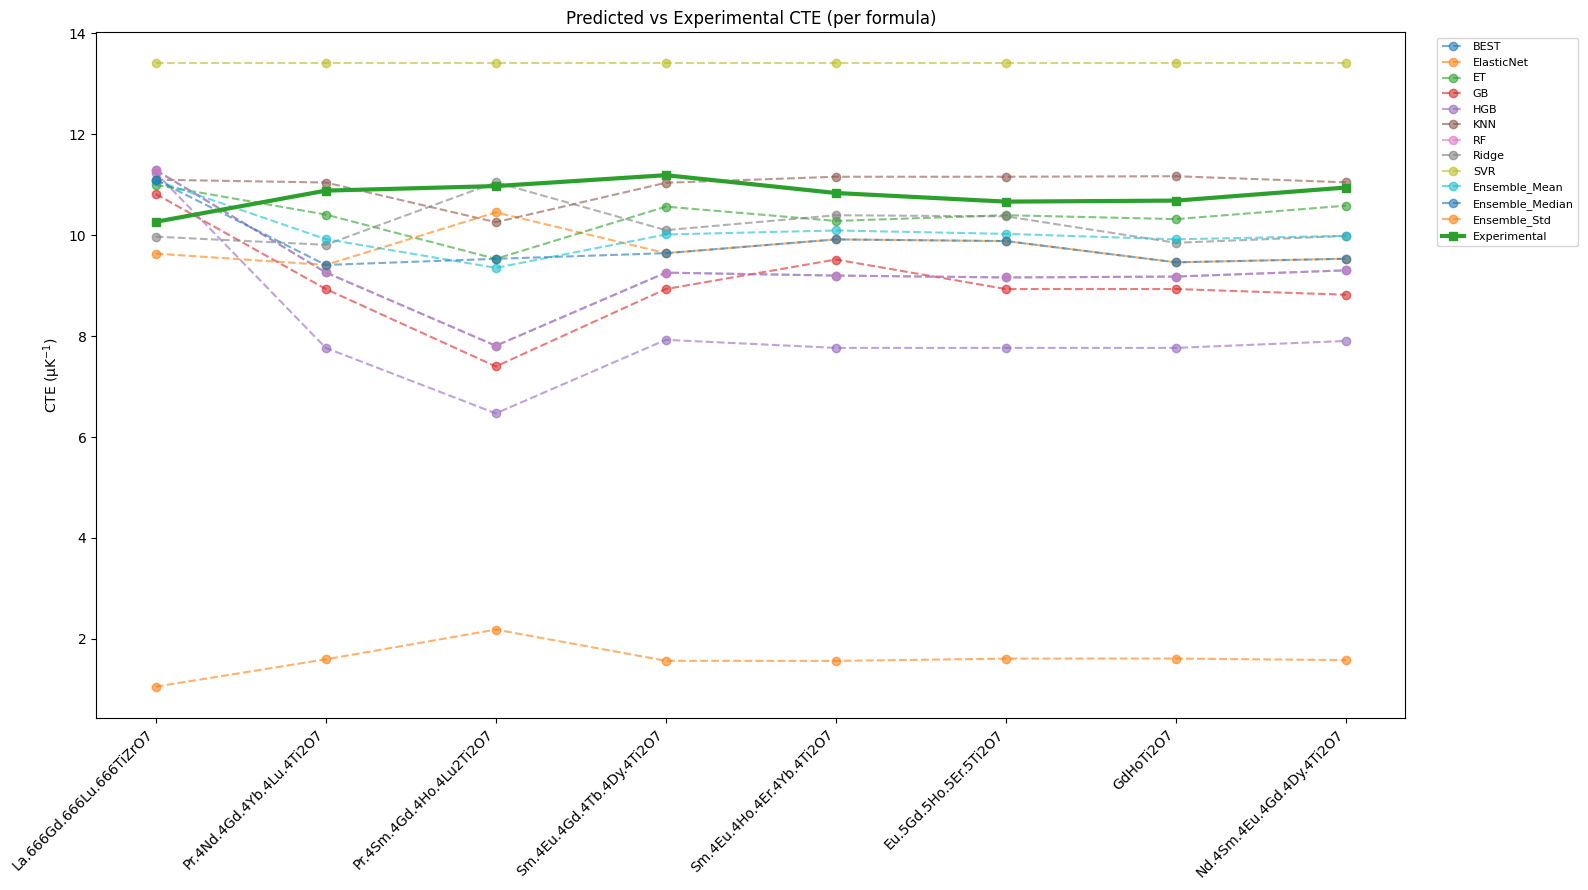

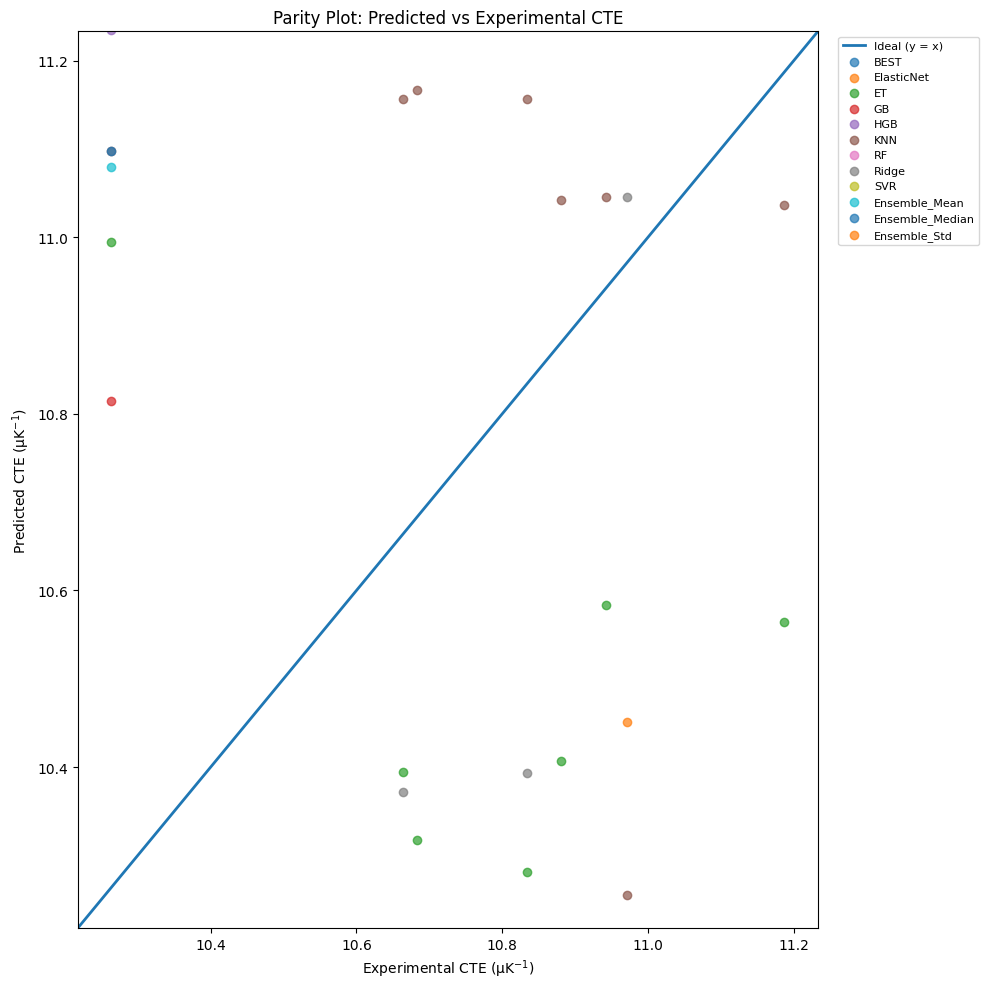

In [30]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- Experimental Data ----------------
experimental_data = {
    "La.666Gd.666Lu.666TiZrO7": 10.26370957e-6,
    "Pr.4Nd.4Gd.4Yb.4Lu.4Ti2O7": 10.8812864e-6,
    "Pr.4Sm.4Gd.4Ho.4Lu2Ti2O7": 10.97135822e-6,
    "Sm.4Eu.4Gd.4Tb.4Dy.4Ti2O7": 11.18713217e-6,
    "Sm.4Eu.4Ho.4Er.4Yb.4Ti2O7": 10.83446e-6,
    "Eu.5Gd.5Ho.5Er.5Ti2O7":     10.66338e-6,
    "GdHoTi2O7":                 10.68365e-6,
    "Nd.4Sm.4Eu.4Gd.4Dy.4Ti2O7": 10.94286e-6,
}

# ---------------- Load predictions ----------------
# Preferred wide CSV produced by the "predict all models" script
PRED_ALL = "cte_predictions_all_models.csv"
# Legacy RF-only CSV (fallback)
PRED_RF_ONLY = "cte_predictions_new_materials.csv"

if os.path.exists(PRED_ALL):
    preds = pd.read_csv(PRED_ALL)
    # Identify model columns (exclude non-prediction columns)
    non_model_cols = {"Formula"}
    model_cols = [c for c in preds.columns if c not in non_model_cols]
    # If ensemble columns exist, keep them too for plotting and metrics
else:
    # Fallback to legacy single-model CSV; rename to "RF"
    preds = pd.read_csv(PRED_RF_ONLY).rename(columns={"Predicted_CTE": "RF"})
    model_cols = [c for c in preds.columns if c not in {"Formula"}]

if "Formula" not in preds.columns:
    raise ValueError("Predictions file must contain a 'Formula' column.")

# ---------------- Merge with experimental ----------------
preds["Experimental"] = preds["Formula"].map(experimental_data)
df = preds.dropna(subset=["Experimental"]).copy()
if df.empty:
    raise RuntimeError("No overlap between predictions and experimental_data formulas.")

# Optional: display which formulas are used
print("Formulas matched with experimental data:")
print(df["Formula"].tolist())

# ---------------- Optional units: plot in micro (1e-6) if desired ----------------
# Set to True if you want the y-axis in µK^-1 instead of K^-1
PLOT_IN_MICRO = True
scale = 1e6 if PLOT_IN_MICRO else 1.0
ylabel = "CTE (µK$^{-1}$)" if PLOT_IN_MICRO else "CTE (K$^{-1}$)"

df_plot = df.copy()
for c in model_cols + ["Experimental"]:
    if c in df_plot.columns:
        df_plot[c] = df_plot[c] * scale

# ---------------- Metrics per model ----------------
def rmse(a, b):
    return float(np.sqrt(np.mean((np.array(a) - np.array(b))**2)))

def mae(a, b):
    return float(np.mean(np.abs(np.array(a) - np.array(b))))

def r2(a, b):
    a = np.array(a); b = np.array(b)
    ss_res = np.sum((a - b)**2)
    ss_tot = np.sum((b - np.mean(b))**2)
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else float("nan")

metrics_rows = []
for m in model_cols:
    if m not in df_plot.columns:
        continue
    yhat = df_plot[m].values
    yexp = df_plot["Experimental"].values
    metrics_rows.append({
        "Model": m,
        "R2": r2(yhat, yexp),
        f"MAE ({ylabel})": mae(yhat, yexp),
        f"RMSE ({ylabel})": rmse(yhat, yexp),
    })
metrics = pd.DataFrame(metrics_rows).sort_values(by=f"RMSE ({ylabel})")
metrics.to_csv("cte_model_eval_vs_experimental.csv", index=False)
print("\nSaved metrics → cte_model_eval_vs_experimental.csv")
print(metrics)

# ---------------- Plot 1: per-formula line chart ----------------
plt.figure(figsize=(16, 9))
x = np.arange(len(df_plot))
for m in model_cols:
    if m in df_plot.columns:
        plt.plot(x, df_plot[m].values, marker="o", linestyle="--", alpha=0.6, label=m)

plt.plot(x, df_plot["Experimental"].values, marker="s", linewidth=3, label="Experimental")
plt.xticks(x, df_plot["Formula"].tolist(), rotation=45, ha="right")
plt.ylabel(ylabel)
plt.title("Predicted vs Experimental CTE (per formula)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

# ---------------- Plot 2: parity (ŷ vs y) ----------------
plt.figure(figsize=(10, 10))
yexp = df_plot["Experimental"].values
min_y = float(np.min(yexp))
max_y = float(np.max(yexp))
pad = 0.05 * (max_y - min_y if max_y > min_y else 1.0)
lo, hi = min_y - pad, max_y + pad

# 1:1 line
plt.plot([lo, hi], [lo, hi], linewidth=2, label="Ideal (y = x)")

# Each model as a scatter
for m in model_cols:
    if m in df_plot.columns:
        plt.scatter(yexp, df_plot[m].values, alpha=0.7, label=m)

plt.xlabel(f"Experimental {ylabel}")
plt.ylabel(f"Predicted {ylabel}")
plt.title("Parity Plot: Predicted vs Experimental CTE")
plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


Matched formulas: ['La.666Gd.666Lu.666TiZrO7', 'Pr.4Nd.4Gd.4Yb.4Lu.4Ti2O7', 'Pr.4Sm.4Gd.4Ho.4Lu2Ti2O7', 'Sm.4Eu.4Gd.4Tb.4Dy.4Ti2O7', 'Sm.4Eu.4Ho.4Er.4Yb.4Ti2O7', 'Eu.5Gd.5Ho.5Er.5Ti2O7', 'GdHoTi2O7', 'Nd.4Sm.4Eu.4Gd.4Dy.4Ti2O7']

KNN vs Experimental metrics:
  R²   : -2.5034
  MAE  : 0.407723 CTE (µK$^{-1}$)
  RMSE : 0.480469 CTE (µK$^{-1}$)


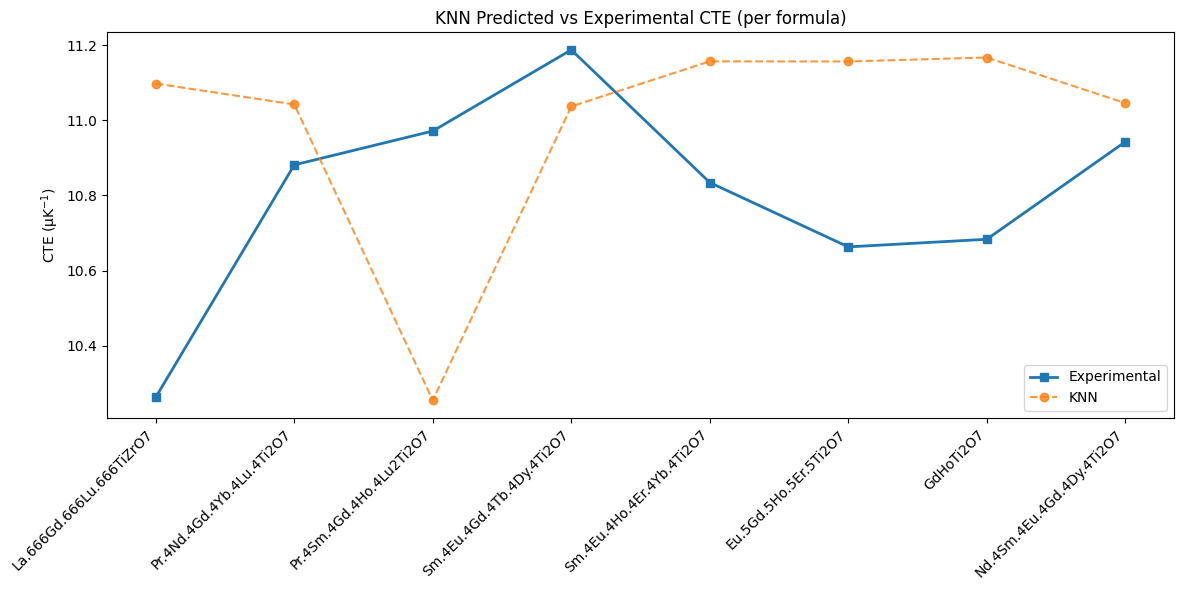

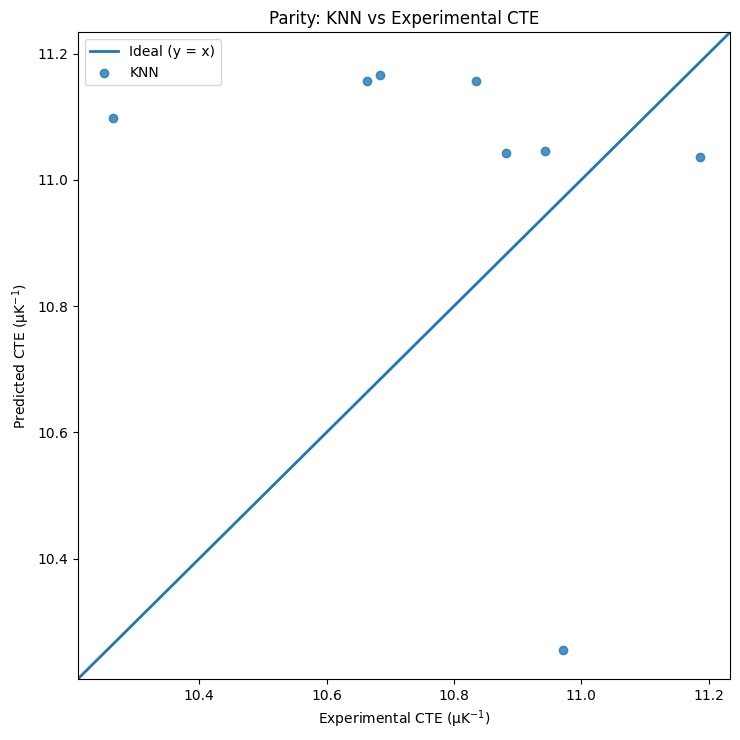

In [31]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- Experimental Data ----------------
experimental_data = {
    "La.666Gd.666Lu.666TiZrO7": 10.26370957e-6,
    "Pr.4Nd.4Gd.4Yb.4Lu.4Ti2O7": 10.8812864e-6,
    "Pr.4Sm.4Gd.4Ho.4Lu2Ti2O7": 10.97135822e-6,
    "Sm.4Eu.4Gd.4Tb.4Dy.4Ti2O7": 11.18713217e-6,
    "Sm.4Eu.4Ho.4Er.4Yb.4Ti2O7": 10.83446e-6,
    "Eu.5Gd.5Ho.5Er.5Ti2O7":     10.66338e-6,
    "GdHoTi2O7":                 10.68365e-6,
    "Nd.4Sm.4Eu.4Gd.4Dy.4Ti2O7": 10.94286e-6,
}

PRED_ALL = "cte_predictions_all_models.csv"
PRED_RF_ONLY = "cte_predictions_new_materials.csv"  # fallback (won't have KNN)

if not os.path.exists(PRED_ALL):
    raise FileNotFoundError(
        f"'{PRED_ALL}' not found. Run the multi-model prediction script first."
    )

preds = pd.read_csv(PRED_ALL)
if "KNN" not in preds.columns:
    raise ValueError("KNN predictions not found in cte_predictions_all_models.csv")

# Merge experimental
preds["Experimental"] = preds["Formula"].map(experimental_data)
df = preds[["Formula", "KNN", "Experimental"]].dropna(subset=["Experimental"]).copy()
if df.empty:
    raise RuntimeError("No overlap between KNN predictions and experimental formulas.")

print("Matched formulas:", df["Formula"].tolist())

# ---- Units: plot in micro-K^-1 for readability ----
PLOT_IN_MICRO = True
scale = 1e6 if PLOT_IN_MICRO else 1.0
ylabel = "CTE (µK$^{-1}$)" if PLOT_IN_MICRO else "CTE (K$^{-1}$)"
df["KNN_plot"] = df["KNN"] * scale
df["Experimental_plot"] = df["Experimental"] * scale

# ---- Metrics ----
def rmse(a, b): return float(np.sqrt(np.mean((np.array(a) - np.array(b))**2)))
def mae(a, b):  return float(np.mean(np.abs(np.array(a) - np.array(b))))
def r2(a, b):
    a = np.array(a); b = np.array(b)
    ss_res = np.sum((a - b)**2); ss_tot = np.sum((b - np.mean(b))**2)
    return float(1 - ss_res/ss_tot) if ss_tot > 0 else float("nan")

yhat = df["KNN_plot"].values
yexp = df["Experimental_plot"].values
print("\nKNN vs Experimental metrics:")
print(f"  R²   : {r2(yhat, yexp):.4f}")
print(f"  MAE  : {mae(yhat, yexp):.6f} {ylabel}")
print(f"  RMSE : {rmse(yhat, yexp):.6f} {ylabel}")

# ---- Plot 1: per-formula comparison ----
plt.figure(figsize=(12, 6))
x = np.arange(len(df))
plt.plot(x, df["Experimental_plot"].values, marker="s", linewidth=2, label="Experimental")
plt.plot(x, df["KNN_plot"].values, marker="o", linestyle="--", alpha=0.8, label="KNN")
plt.xticks(x, df["Formula"].tolist(), rotation=45, ha="right")
plt.ylabel(ylabel)
plt.title("KNN Predicted vs Experimental CTE (per formula)")
plt.legend()
plt.tight_layout()
plt.show()

# ---- Plot 2: parity plot ----
plt.figure(figsize=(7.5, 7.5))
lo = float(min(yexp.min(), yhat.min()))
hi = float(max(yexp.max(), yhat.max()))
pad = 0.05 * (hi - lo if hi > lo else 1.0)
lo, hi = lo - pad, hi + pad
plt.plot([lo, hi], [lo, hi], linewidth=2, label="Ideal (y = x)")
plt.scatter(yexp, yhat, alpha=0.8, label="KNN")
plt.xlabel(f"Experimental {ylabel}")
plt.ylabel(f"Predicted {ylabel}")
plt.title("Parity: KNN vs Experimental CTE")
plt.xlim(lo, hi); plt.ylim(lo, hi)
plt.legend()
plt.tight_layout()
plt.show()


Still did not fit well, I am going to try to use more models first, then I will continue to adjust features selection, considering using SHAP for feature selection and comparing against the feature reduction method I've been trying

In [32]:
# Hybrid Feature Selection Workflow for CTE
# Correlation → MI filter → Shadow/Boruta-like → Lasso Stability → Permutation-Stability (CV)
# Big model league (group-aware CV). Keeps Colab compatibility artifacts.
import os, json, warnings, numpy as np, pandas as pd
from typing import List, Tuple, Optional, Dict
from pathlib import Path

from joblib import dump

from sklearn.model_selection import KFold, GroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, r2_score, mean_absolute_error, mean_squared_error
from sklearn.feature_selection import mutual_info_regression
from sklearn.utils import resample
from sklearn.inspection import permutation_importance

# Tree & ensemble
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor,
    GradientBoostingRegressor, HistGradientBoostingRegressor,
    AdaBoostRegressor, BaggingRegressor
)
from sklearn.tree import DecisionTreeRegressor

# Linear / robust
from sklearn.linear_model import (
    LassoCV, ElasticNetCV, Ridge, RidgeCV, BayesianRidge,
    HuberRegressor, RANSACRegressor
)

# SVM / kernel
from sklearn.svm import SVR, NuSVR, LinearSVR
from sklearn.kernel_ridge import KernelRidge

# Neighbors
from sklearn.neighbors import KNeighborsRegressor

# Others
from sklearn.cross_decomposition import PLSRegression
from sklearn.neural_network import MLPRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel, DotProduct

# Optional external libs (added only if available)
EXT_MODELS: Dict[str, object] = {}
try:
    from xgboost import XGBRegressor
    EXT_MODELS["XGB"] = XGBRegressor(
        n_estimators=800, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.0, reg_lambda=1.0,
        random_state=42, n_jobs=-1, tree_method="hist"
    )
except Exception:
    pass
try:
    from lightgbm import LGBMRegressor
    EXT_MODELS["LGBM"] = LGBMRegressor(
        n_estimators=1200, max_depth=-1, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
    )
except Exception:
    pass
try:
    from catboost import CatBoostRegressor
    EXT_MODELS["CAT"] = CatBoostRegressor(
        depth=8, learning_rate=0.05, iterations=1500, loss_function="RMSE",
        random_seed=42, verbose=False
    )
except Exception:
    pass

warnings.filterwarnings("ignore")

# -----------------------
# Parameters
# -----------------------
PATH = "composition_features_pymatgen.csv"  # <--- change if your file is elsewhere
TARGET = "CTE Value"

# Feature selection thresholds
CORR_THRESHOLD = 0.95
MI_KEEP_FRAC = 0.25
SHADOW_ITER = 40
SHADOW_KEEP_THRESHOLD = 0.6
LASSO_BOOTSTRAP_ITER = 80
LASSO_NONZERO_THRESHOLD = 0.55
PERM_STAB_ITER = 1
PERM_STAB_THRESHOLD = 0.55
MAX_FINAL_FEATURES = 200    # allow a few more features

# CV / compute
N_SPLITS = 5
N_JOBS = -1
RAND = 42

# Artifacts (Colab dependencies)
SELECTED_FEATS_FILE = "selected_features.txt"
REDUCED_DATASET = "cte_reduced_features.csv"
MODEL_JOBLIB = "cte_model_rf.joblib"           # must remain RF to match Colab
BEST_MODEL_JOBLIB = "cte_model_best.joblib"
METRICS_JSON = "cte_cv_report.json"

# -----------------------
# Load
# -----------------------
if not os.path.exists(PATH):
    raise FileNotFoundError(f"{PATH} not found. Place the CSV next to this script/notebook or update PATH.")
df = pd.read_csv(PATH)
if TARGET not in df.columns:
    raise ValueError(f"Target '{TARGET}' not found. Columns include: {list(df.columns)[:12]} ...")

group_col = "prototype" if "prototype" in df.columns else None
groups = df[group_col] if group_col else None

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if TARGET in numeric_cols:
    numeric_cols.remove(TARGET)
X = df[numeric_cols].copy()
y = df[TARGET].values

# =======================
# Helpers
# =======================
def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred, squared=False)

def make_cv():
    if groups is not None and len(np.unique(groups)) >= N_SPLITS:
        return GroupKFold(n_splits=N_SPLITS).split(X, y, groups)
    return KFold(n_splits=N_SPLITS, shuffle=True, random_state=RAND).split(X, y)

scoring = {
    "r2": make_scorer(r2_score),
    "mae": make_scorer(mean_absolute_error, greater_is_better=False),
    "rmse": make_scorer(rmse, greater_is_better=False),
}

# =======================
# 1) Correlation pruning
# =======================
def correlation_prune(Xdf: pd.DataFrame, threshold: float = 0.95) -> pd.Index:
    corr = Xdf.corr().abs()
    to_drop = set()
    cols = Xdf.columns
    for i in range(len(cols)):
        if cols[i] in to_drop:
            continue
        for j in range(i + 1, len(cols)):
            if corr.iloc[i, j] > threshold and cols[j] not in to_drop:
                to_drop.add(cols[j])
    keep = [c for c in cols if c not in to_drop]
    return pd.Index(keep)

keep_corr = correlation_prune(X, CORR_THRESHOLD)
X_corr = X[keep_corr]

# ==========================================
# 1b) Mutual Information filter
# ==========================================
from sklearn.metrics import mean_squared_error
def mi_filter(Xdf: pd.DataFrame, y: np.ndarray, keep_frac: float = 0.25, random_state=RAND) -> pd.Index:
    imp = SimpleImputer(strategy="median")
    X_imp = imp.fit_transform(Xdf)
    mi = mutual_info_regression(X_imp, y, random_state=random_state)
    mi = pd.Series(mi, index=Xdf.columns).fillna(0.0)
    k = max(8, int(len(mi) * keep_frac))
    return mi.sort_values(ascending=False).head(k).index

keep_mi = mi_filter(X_corr, y, keep_frac=MI_KEEP_FRAC, random_state=RAND)
X_mi = X_corr[keep_mi]

# ===================================
# 2) Shadow/Boruta-like selection
# ===================================
def shadow_select(X_in: pd.DataFrame, y, n_iter=40, keep_thr=0.6, random_state=42):
    rs = np.random.RandomState(random_state)
    cols = X_in.columns.tolist()
    keep_counts = pd.Series(0, index=cols, dtype=int)

    for it in range(n_iter):
        X_shadow = X_in.copy()
        for c in cols:
            X_shadow[c] = rs.permutation(X_shadow[c].values)
        X_aug = pd.concat([X_in, X_shadow.add_prefix("shadow_")], axis=1)

        rf = RandomForestRegressor(
            n_estimators=600, min_samples_leaf=2, random_state=it, n_jobs=N_JOBS
        )
        rf.fit(X_aug, y)
        importances = pd.Series(rf.feature_importances_, index=X_aug.columns)

        shadow_max = importances.filter(regex=r"^shadow_").max()
        real_imps = importances.loc[cols]
        keep_mask = real_imps > shadow_max
        keep_counts[keep_mask.index[keep_mask]] += 1

    keep_rate = keep_counts / n_iter
    selected = keep_rate[keep_rate >= keep_thr].index
    return selected, keep_rate

shadow_selected, shadow_rate = shadow_select(X_mi, y, n_iter=SHADOW_ITER, keep_thr=SHADOW_KEEP_THRESHOLD, random_state=RAND)
X_shadow = X_mi[shadow_selected] if len(shadow_selected) > 0 else X_mi

# ==============================================
# 3) Lasso stability selection (bootstrapped)
# ==============================================
def lasso_stability(X_in: pd.DataFrame, y, n_iter=80, nz_thr=0.55, random_state=123):
    rs = np.random.RandomState(random_state)
    counts = pd.Series(0, index=X_in.columns, dtype=int)

    for _ in range(n_iter):
        Xb, yb = resample(X_in, y, replace=True, random_state=rs.randint(0, 1_000_000))
        lasso = Pipeline(
            [
                ("imp", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler(with_mean=True, with_std=True)),
                ("model", LassoCV(cv=5, random_state=rs.randint(0, 1_000_000), n_jobs=N_JOBS)),
            ]
        )
        lasso.fit(Xb, yb)
        coefs = lasso.named_steps["model"].coef_
        nonzero = np.abs(coefs) > 1e-8
        counts.loc[X_in.columns[nonzero]] += 1

    keep_rate = counts / n_iter
    selected = keep_rate[keep_rate >= nz_thr].index
    return selected, keep_rate

lasso_selected, lasso_rate = lasso_stability(
    X_shadow, y, n_iter=LASSO_BOOTSTRAP_ITER, nz_thr=LASSO_NONZERO_THRESHOLD, random_state=123
)

# ==========================================================
# 4) Permutation-Importance Stability across CV folds
# ==========================================================
def perm_stability(
    X_in: pd.DataFrame,
    y: np.ndarray,
    groups: Optional[pd.Series],
    cv_splits: int = N_SPLITS,
    n_iter: int = PERM_STAB_ITER,
    threshold: float = PERM_STAB_THRESHOLD,
    random_state: int = RAND,
) -> Tuple[pd.Index, pd.Series]:
    rng = np.random.RandomState(random_state)
    feats = X_in.columns
    hit_counts = pd.Series(0, index=feats, dtype=int)
    total_counts = pd.Series(0, index=feats, dtype=int)

    splitter = GroupKFold(n_splits=cv_splits) if (groups is not None and len(np.unique(groups)) >= cv_splits) \
               else KFold(n_splits=cv_splits, shuffle=True, random_state=random_state)

    for rep in range(n_iter):
        for tr_idx, va_idx in splitter.split(X_in, y, groups if groups is not None else None):
            Xtr, Xva = X_in.iloc[tr_idx], X_in.iloc[va_idx]
            ytr, yva = y[tr_idx], y[va_idx]

            pipe = Pipeline([
                ("imp", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", ExtraTreesRegressor(n_estimators=800, min_samples_leaf=2, n_jobs=N_JOBS, random_state=rng.randint(0, 1_000_000)))
            ])
            pipe.fit(Xtr, ytr)

            pi = permutation_importance(pipe, Xva, yva, n_repeats=5, random_state=rng.randint(0, 1_000_000), n_jobs=N_JOBS)
            imps = pd.Series(pi.importances_mean, index=feats).fillna(0.0)

            top_mask = imps.rank(ascending=False, method="average") <= (len(feats) / 2.0)
            hit_counts[top_mask.index[top_mask]] += 1
            total_counts += 1

    stab = (hit_counts / total_counts.replace(0, np.nan)).fillna(0.0)
    keep = stab[stab >= threshold].index
    return keep, stab

perm_selected, perm_rate = perm_stability(X_shadow, y, groups, cv_splits=N_SPLITS,
                                          n_iter=PERM_STAB_ITER, threshold=PERM_STAB_THRESHOLD, random_state=RAND)

# ==========================================================
# Combine selections (intersection → union), cap size
# ==========================================================
cands: List[pd.Index] = []
if len(shadow_selected) > 0: cands.append(pd.Index(shadow_selected))
if len(lasso_selected)  > 0: cands.append(pd.Index(lasso_selected))
if len(perm_selected)   > 0: cands.append(pd.Index(perm_selected))

if cands:
    inter = set(cands[0])
    for s in cands[1:]:
        inter &= set(s)
    if len(inter) >= max(8, int(0.03 * X.shape[1])):
        final_feats = sorted(list(inter))
    else:
        uni = set()
        for s in cands: uni |= set(s)
        final_feats = sorted(list(uni))
else:
    final_feats = sorted(list(X_mi.columns))

if len(final_feats) == 0:
    final_feats = list(X_mi.columns[: min(64, X_mi.shape[1])])
if len(final_feats) > MAX_FINAL_FEATURES:
    final_feats = final_feats[:MAX_FINAL_FEATURES]

X_final = X[final_feats]

# -----------------------
# Save reduced dataset & feature list (for Colab)
# -----------------------
out_df = pd.concat([X_final, df[[TARGET]]], axis=1)
out_df.to_csv(REDUCED_DATASET, index=False)
with open(SELECTED_FEATS_FILE, "w") as f:
    for c in final_feats:
        f.write(f"{c}\n")

# =======================
# Big Model League (group-aware CV)
# =======================
def model_league():
    base_scaler = StandardScaler()
    imp = SimpleImputer(strategy="median")

    league = {
        # Tree ensembles (scale-insensitive; scaler kept for uniformity)
        "RF": Pipeline([("imp", imp), ("scaler", base_scaler),
                        ("model", RandomForestRegressor(n_estimators=900, min_samples_leaf=2, random_state=RAND, n_jobs=N_JOBS))]),
        "ET": Pipeline([("imp", imp), ("scaler", base_scaler),
                        ("model", ExtraTreesRegressor(n_estimators=1500, min_samples_leaf=2, random_state=RAND, n_jobs=N_JOBS))]),
        "HGB": Pipeline([("imp", imp), ("scaler", base_scaler),
                         ("model", HistGradientBoostingRegressor(max_depth=None, learning_rate=0.08, random_state=RAND))]),
        "GB": Pipeline([("imp", imp), ("scaler", base_scaler),
                        ("model", GradientBoostingRegressor(random_state=RAND))]),
        "Ada": Pipeline([("imp", imp), ("scaler", base_scaler),
                         ("model", AdaBoostRegressor(DecisionTreeRegressor(max_depth=6, random_state=RAND),
                                                     n_estimators=600, learning_rate=0.05, random_state=RAND))]),
        "BagRF": Pipeline([("imp", imp), ("scaler", base_scaler),
                           ("model", BaggingRegressor(RandomForestRegressor(n_estimators=300, random_state=RAND, n_jobs=N_JOBS),
                                                      n_estimators=12, random_state=RAND, n_jobs=N_JOBS))]),
        "BagKNN": Pipeline([("imp", imp), ("scaler", base_scaler),
                            ("model", BaggingRegressor(KNeighborsRegressor(n_neighbors=7, weights="distance"),
                                                       n_estimators=25, random_state=RAND, n_jobs=N_JOBS))]),
        "DT": Pipeline([("imp", imp), ("scaler", base_scaler),
                        ("model", DecisionTreeRegressor(max_depth=None, random_state=RAND))]),

        # Linear family
        "Ridge": Pipeline([("imp", imp), ("scaler", base_scaler),
                           ("model", Ridge(alpha=1.0, random_state=RAND))]),
        "RidgeCV": Pipeline([("imp", imp), ("scaler", base_scaler),
                             ("model", RidgeCV(alphas=np.logspace(-3, 3, 25)))]),
        "Lasso": Pipeline([("imp", imp), ("scaler", base_scaler),
                           ("model", LassoCV(cv=5, random_state=RAND, n_jobs=N_JOBS))]),
        "ElasticNet": Pipeline([("imp", imp), ("scaler", base_scaler),
                                ("model", ElasticNetCV(l1_ratio=[0.2,0.5,0.8,0.95,1.0], cv=5, n_jobs=N_JOBS, random_state=RAND))]),
        "BayesRidge": Pipeline([("imp", imp), ("scaler", base_scaler),
                                ("model", BayesianRidge())]),
        "Huber": Pipeline([("imp", imp), ("scaler", base_scaler),
                           ("model", HuberRegressor())]),
        "RANSAC": Pipeline([("imp", imp), ("scaler", base_scaler),
                            ("model", RANSACRegressor(random_state=RAND))]),

        # Neighbors / SVM / Kernel
        "KNN": Pipeline([("imp", imp), ("scaler", base_scaler),
                         ("model", KNeighborsRegressor(n_neighbors=7, weights="distance"))]),
        "SVR": Pipeline([("imp", imp), ("scaler", base_scaler),
                         ("model", SVR(C=10.0, epsilon=0.05, kernel="rbf", gamma="scale"))]),
        "NuSVR": Pipeline([("imp", imp), ("scaler", base_scaler),
                           ("model", NuSVR(C=10.0, nu=0.5, kernel="rbf", gamma="scale"))]),
        "LinSVR": Pipeline([("imp", imp), ("scaler", base_scaler),
                            ("model", LinearSVR(C=2.0, epsilon=0.05, random_state=RAND))]),
        "KRR_RBF": Pipeline([("imp", imp), ("scaler", base_scaler),
                             ("model", KernelRidge(alpha=1.0, kernel="rbf", gamma=None))]),
        "KRR_LIN": Pipeline([("imp", imp), ("scaler", base_scaler),
                             ("model", KernelRidge(alpha=1.0, kernel="linear"))]),

        # GPR (may be slow on large N)
        "GPR_RBF": Pipeline([("imp", imp), ("scaler", base_scaler),
                             ("model", GaussianProcessRegressor(kernel=C(1.0)*RBF(length_scale=1.0)+WhiteKernel(1e-3),
                                                               alpha=0.0, normalize_y=False, random_state=RAND))]),

        # Others
        "PLS2": Pipeline([("imp", imp), ("scaler", base_scaler),
                          ("model", PLSRegression(n_components=min(10, max(1, int(X_final.shape[1]**0.5)))))]),
        "MLP": Pipeline([("imp", imp), ("scaler", base_scaler),
                         ("model", MLPRegressor(hidden_layer_sizes=(128,64),
                                                activation="relu", alpha=1e-4, learning_rate_init=1e-3,
                                                early_stopping=True, random_state=RAND, max_iter=2000))]),
    }

    # Add optional external models only if their libs were found
    for key, est in EXT_MODELS.items():
        league[key] = Pipeline([("imp", imp), ("scaler", base_scaler), ("model", est)])

    return league

def run_cv(pipe, Xmat, yvec, groups):
    cv = GroupKFold(n_splits=N_SPLITS).split(Xmat, yvec, groups) if (groups is not None and len(np.unique(groups)) >= N_SPLITS) \
         else KFold(n_splits=N_SPLITS, shuffle=True, random_state=RAND).split(Xmat, yvec)
    res = cross_validate(pipe, Xmat, yvec, cv=cv, scoring=scoring, n_jobs=N_JOBS, return_train_score=False)
    s = {m.replace("test_", ""): float(np.mean(v)) for m, v in res.items() if m.startswith("test_")}
    s["mae"] = -s["mae"]; s["rmse"] = -s["rmse"]
    return s

league = model_league()
cv_table = {}
for name, pipe in league.items():
    try:
        cv_table[name] = run_cv(pipe, X_final, y, groups)
    except Exception as e:
        print(f"[WARN] CV failed for {name}: {e}")

# pick best by RMSE among successful models
if not cv_table:
    raise RuntimeError("No models produced CV results.")
best_name = min(cv_table.keys(), key=lambda k: cv_table[k]["rmse"])
best_scores = cv_table[best_name]

# -----------------------
# Print summary
# -----------------------
print("Selected feature count:", len(final_feats))
print("First 20 selected features:", final_feats[:20])
print("Correlation-pruned feature count:", X_corr.shape[1])
print("MI-kept count:", len(X_mi.columns))
print("Shadow-selected count:", len(shadow_selected))
print("Lasso-stable count:", len(lasso_selected))
print("Perm-stable count:", len(perm_selected))
print("\nModel league CV (5-fold):")
for k in sorted(cv_table.keys()):
    s = cv_table[k]
    print(f"  {k:8s} | R2: {s['r2']:.4f}  RMSE: {s['rmse']:.6f}  MAE: {s['mae']:.6f}")
print(f"\n→ Best by RMSE: {best_name} | R2: {best_scores['r2']:.4f}  RMSE: {best_scores['rmse']:.6f}  MAE: {best_scores['mae']:.6f}")

# Save CV report
with open(METRICS_JSON, "w") as f:
    json.dump({"features": final_feats, "cv": cv_table, "best": {"name": best_name, **best_scores}}, f, indent=2)

print("\nSaved files so far:")
print(f" - {REDUCED_DATASET}")
print(f" - {SELECTED_FEATS_FILE}")
print(f" - {METRICS_JSON}")

# -----------------------
# FINAL: Train on full reduced dataset and SAVE EVERY model
# (Colab still expects an RF under MODEL_JOBLIB)
# -----------------------
Path(".").mkdir(parents=True, exist_ok=True)

model_files = {name: f"cte_model_{name.lower()}.joblib" for name in league.keys()}
saved_paths = []

for name, pipe in league.items():
    try:
        pipe.fit(X_final, y)
        out_path = model_files[name]
        dump(pipe, out_path)
        saved_paths.append(out_path)

        # Export importances/coeffs where available (best-effort)
        try:
            est = pipe.named_steps.get("model", None)
            if hasattr(est, "feature_importances_"):
                imp = pd.Series(est.feature_importances_, index=X_final.columns).sort_values(ascending=False)
                imp.to_csv(f"{Path(out_path).stem}_feature_importances.csv", header=["importance"])
            elif hasattr(est, "coef_"):
                coef = np.ravel(est.coef_)
                pd.Series(coef, index=X_final.columns).to_csv(f"{Path(out_path).stem}_coefficients.csv", header=["coefficient"])
        except Exception:
            pass
    except Exception as e:
        print(f"[WARN] Train/Save failed for {name}: {e}")

# Ensure Colab compatibility: write RF to expected name (or fallback to best)
if "RF" in league and f"cte_model_rf.joblib" in model_files.values():
    try:
        dump(league["RF"], MODEL_JOBLIB)
        saved_paths.append(MODEL_JOBLIB)
        print(f"✓ Colab-compatible RF saved → {MODEL_JOBLIB}")
    except Exception as e:
        print(f"[WARN] Could not save RF at {MODEL_JOBLIB}: {e}")
else:
    try:
        dump(league[best_name], MODEL_JOBLIB)
        saved_paths.append(MODEL_JOBLIB)
        print(f"⚠️ RF not found; saved best model as Colab artifact → {MODEL_JOBLIB}")
    except Exception as e:
        print(f"[WARN] Could not save best model as Colab artifact: {e}")

# Also save the CV winner explicitly
try:
    dump(league[best_name], BEST_MODEL_JOBLIB)
    saved_paths.append(BEST_MODEL_JOBLIB)
    print(f"✓ Also saved CV winner ({best_name}) → {BEST_MODEL_JOBLIB}")
except Exception as e:
    print(f"[WARN] Could not save best model separately: {e}")

print("\nSaved model artifacts:")
for p in sorted(set(saved_paths)):
    print(" -", p)

print("\nAll artifacts ready. Colab inference will use selected_features.txt + cte_reduced_features.csv + cte_model_rf.joblib.")


Selected feature count: 5
First 20 selected features: ['Avg Ionic Radius (Å)', 'Ionic Size Mismatch (%)', 'MagpieData mean NfValence', 'MagpieData mean NpUnfilled', 'MagpieData mean Number']
Correlation-pruned feature count: 138
MI-kept count: 34
Shadow-selected count: 5
Lasso-stable count: 4
Perm-stable count: 2

Model league CV (5-fold):
  Ada      | R2: 0.5341  RMSE: nan  MAE: 0.000001
  BagKNN   | R2: 0.7797  RMSE: nan  MAE: 0.000001
  BagRF    | R2: 0.7422  RMSE: nan  MAE: 0.000001
  BayesRidge | R2: 0.6105  RMSE: nan  MAE: 0.000002
  DT       | R2: 0.5024  RMSE: nan  MAE: 0.000002
  ET       | R2: 0.7433  RMSE: nan  MAE: 0.000001
  ElasticNet | R2: 0.6158  RMSE: nan  MAE: 0.000002
  GB       | R2: 0.6493  RMSE: nan  MAE: 0.000001
  GPR_RBF  | R2: -0.0314  RMSE: nan  MAE: 0.000004
  HGB      | R2: 0.7046  RMSE: nan  MAE: 0.000001
  Huber    | R2: 0.6689  RMSE: nan  MAE: 0.000002
  KNN      | R2: 0.7804  RMSE: nan  MAE: 0.000001
  KRR_LIN  | R2: -2.4817  RMSE: nan  MAE: 0.000008
  

In [33]:
# ====== Colab one-click: Predict CTE on new compositions using your new featurizer ======
# Installs, writes feature_engineer.py, loads artifacts (or prompts upload), trains (if needed), predicts with ALL saved models, saves CSV.

# 0) Install dependencies
!pip -q install pymatgen==2024.5.1 matminer==0.9.0 scikit-learn==1.4.2 pandas==2.2.2 joblib==1.4.2

import os, io, glob, textwrap, importlib.util, numpy as np, pandas as pd
from pathlib import Path
from joblib import dump, load
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

# Colab utilities for optional upload/download
try:
    from google.colab import files
    IN_COLAB = True
except Exception:
    IN_COLAB = False

# -----------------------------
# Config (edit if you like)
# -----------------------------
TARGET = "CTE Value"
SELECTED_FEATS_FILE = "selected_features.txt"
REDUCED_DATASET = "cte_reduced_features.csv"
MODEL_JOBLIB = "cte_model_rf.joblib"   # legacy/expected artifact
FEATURE_MODULE = "feature_engineer.py"
ALLOW_MISSING_FEATURES = True  # fill missing selected features with NaN for inference

# If you saved per-model artifacts with these names, they'll be picked up automatically:
#   cte_model_rf.joblib (also used for Colab)
#   cte_model_et.joblib
#   cte_model_hgb.joblib
#   cte_model_gb.joblib
#   cte_model_elasticnet.joblib
#   cte_model_svr.joblib
#   cte_model_knn.joblib
#   cte_model_ridge.joblib
#   cte_model_best.joblib

new_formulas = [
    "Y3Al5O12",
    "Y1.5Dy1.5Al5O12",
    "Y.9999Dy.9999Ho.9999Al5O12",
    "Y.75Dy.75Ho.75Er.75Al5O12",
    "Y.6La.6Dy.6Ho.6Er.6Al5O12",
    "Y.60Nd.60Dy.60Ho.60Er.6Al5O12",
    "(Y0.1666Nd0.1666Sm0.1666Dy0.1666Ho0.1666Er0.1666)3Al5O12",
    "(Y0.14285Nd0.14285Sm0.14285Eu0.14285Dy0.14285Ho0.14285Er0.14285)3Al5O12",
    "Y3Fe5O12",
    "Y3Fe2.50Al2.50O12",
    "Y3Fe2.475Al2.475Mn0.05O12",
    "Y3Fe2.475Al2.475Co0.05O12",
    "Y3Fe2.475Al2.475Ni0.05O12",
    "Y3Fe2.475Al2.475Cu0.05O12",
    "Y3Fe2.45Al2.45Mn0.025Co0.025Ni0.025Cu0.025O12",
    "Y.6Eu.6Dy.6Ho.6Er.6Al5O12",
    "La.666Gd.666Lu.666TiZrO7",
    "Pr.4Nd.4Gd.4Yb.4Lu.4Ti2O7",
    "Pr.4Sm.4Gd.4Ho.4Lu2Ti2O7",
    "Sm.4Eu.4Gd.4Tb.4Dy.4Ti2O7",
    "Sm.4Eu.4Ho.4Er.4Yb.4Ti2O7",
    "Eu.5Gd.5Ho.5Er.5Ti2O7",
    "GdHoTi2O7",
    "Nd.4Sm.4Eu.4Gd.4Dy.4Ti2O7"
]

# -----------------------------
# 1) Write feature_engineer.py
# -----------------------------
fe_code = r'''
from __future__ import annotations
import re, math
from typing import List, Dict, Tuple
import numpy as np, pandas as pd
from pymatgen.core.composition import Composition
from pymatgen.core.periodic_table import Element
from matminer.featurizers.composition import ElementProperty

def _normalize_formula(s: str) -> str:
    s = s.replace(" ", "")
    return re.sub(r'(?<=[A-Za-z\)])\.(\d)', r'0.\1', s)

def _compute_ionic_stats(formula: str) -> Tuple[float|None, float|None, float|None]:
    try:
        comp = Composition(formula)
        elements = comp.elements
        fractions = [comp.get_atomic_fraction(el) for el in elements]
        ionic_radii, atomic_masses, symbols = [], [], []
        for el in elements:
            ox_states = el.common_oxidation_states
            ox_state = ox_states[0] if ox_states else None
            radius = None
            if ox_state is not None and hasattr(el, "ionic_radii") and el.ionic_radii:
                radius = el.ionic_radii.get(ox_state, None)
            ionic_radii.append(radius)
            atomic_masses.append(float(el.atomic_mass))
            symbols.append(el.symbol)
        valid = [(r, f) for r, f in zip(ionic_radii, fractions) if r is not None]
        if not valid: return None, None, None
        radii, fracs = zip(*valid)
        avg_radius = sum(r * f for r, f in zip(radii, fracs))
        var_radius = sum(f * (r - avg_radius) ** 2 for r, f in zip(radii, fracs))
        std_radius = math.sqrt(var_radius)
        mismatch_pct = (std_radius / avg_radius) * 100 if avg_radius else None
        EXCLUDED = {"O"}
        c_masses = [m for m, s in zip(atomic_masses, symbols) if s not in EXCLUDED]
        c_fracs  = [f for s, f in zip(symbols, fractions) if s not in EXCLUDED]
        if not c_masses or not c_fracs:
            return (round(avg_radius, 4) if avg_radius is not None else None,
                    round(mismatch_pct, 2) if mismatch_pct is not None else None,
                    None)
        total_frac = sum(c_fracs) or 1.0
        norm_fracs = [f / total_frac for f in c_fracs]
        mean_mass = sum(m * f for m, f in zip(c_masses, norm_fracs))
        mdiff = ((max(c_masses) - min(c_masses)) / mean_mass) * 100 if mean_mass else None
        return (
            None if avg_radius is None else round(avg_radius, 4),
            None if mismatch_pct is None else round(mismatch_pct, 2),
            None if mdiff is None else round(mdiff, 2),
        )
    except Exception:
        return None, None, None

RARE_EARTHS = {"La","Ce","Pr","Nd","Pm","Sm","Eu","Gd","Tb","Dy","Ho","Er","Tm","Yb","Lu","Y","Sc"}
A_LIKE = RARE_EARTHS | {"Ba","Sr","Ca","K","Na","Pb","Bi"}
B_LIKE = {"Al","Ga","In","Fe","Co","Ni","Mn","Cr","V","Nb","Ta","Ti","Zr","Hf","Sn","Ge","Si","Mo","W","Cu","Mg","Zn"}
COMMON_VALENCES = {
    "La":[3],"Ce":[3,4],"Pr":[3,4],"Nd":[3],"Sm":[3],"Eu":[2,3],"Gd":[3],"Tb":[3,4],"Dy":[3],"Ho":[3],
    "Er":[3],"Tm":[3],"Yb":[2,3],"Lu":[3],"Y":[3],"Sc":[3],
    "Ba":[2],"Sr":[2],"Ca":[2],"K":[1],"Na":[1],
    "Al":[3],"Ga":[3],"In":[3],"Fe":[2,3],"Co":[2,3],"Ni":[2,3],"Mn":[2,3,4],"Cr":[3],"V":[3,5],
    "Nb":[5],"Ta":[5],"Ti":[4,3],"Zr":[4],"Hf":[4],"Sn":[4,2],"Ge":[4],"Si":[4],
    "Mo":[6,5],"W":[6,5],"Cu":[1,2],"Mg":[2],"Zn":[2],
    "Pb":[2,4],"Bi":[3]
}

def _detect_proto(counts: Dict[str,float]) -> str:
    nO = counts.get("O", 0.0)
    metals = {k:v for k,v in counts.items() if k != "O"}
    ncat = sum(metals.values())
    if nO > 0 and abs(nO - 12) <= 0.3 and abs(ncat - 8) <= 0.3:  return "GARNET_A3B2C3O12"
    if nO > 0 and abs(nO - 7)  <= 0.3 and abs(ncat - 4) <= 0.3:  return "PYRO_A2B2O7"
    if nO > 0 and abs(nO - 4)  <= 0.3 and abs(ncat - 3) <= 0.3:  return "SPINEL_AB2O4"
    if nO > 0 and abs(nO - 3)  <= 0.3 and abs(ncat - 2) <= 0.3:  return "PEROV_ABO3"
    return "GEN_OXIDE"

def _split_sites_garnet(metals: Dict[str,float]):
    A, B, C = {}, {}, {}
    rest = metals.copy()
    cap = {"A":3.0, "B":2.0, "C":3.0}
    for el in list(rest.keys()):
        if el in A_LIKE and cap["A"] > 0:
            take = min(rest[el], cap["A"]); A[el]=A.get(el,0)+take; rest[el]-=take; cap["A"]-=take
            if rest[el] <= 1e-12: rest.pop(el, None)
    for site in ("B","C"):
        for el in list(rest.keys()):
            if el in B_LIKE and cap[site] > 0:
                take = min(rest[el], cap[site])
                (B if site=="B" else C)[el] = (B if site=="B" else C).get(el,0)+take
                rest[el]-=take; cap[site]-=take
                if rest[el] <= 1e-12: rest.pop(el, None)
    for site in ("A","B","C"):
        while cap[site] > 1e-12 and rest:
            el = max(rest.items(), key=lambda kv: kv[1])[0]
            take = min(rest[el], cap[site])
            (A if site=="A" else B if site=="B" else C)[el] = (A if site=="A" else B if site=="B" else C).get(el,0)+take
            rest[el]-=take; cap[site]-=take
            if rest[el] <= 1e-12: rest.pop(el, None)
    return A, B, C

def _split_sites_binary(proto: str, metals: Dict[str,float]):
    caps = {"PEROV_ABO3": (1.0,1.0), "SPINEL_AB2O4": (1.0,2.0), "PYRO_A2B2O7": (2.0,2.0)}
    capA, capB = caps.get(proto, (1.0,1.0))
    A, B, rest = {}, {}, metals.copy()
    for el in list(rest.keys()):
        if el in A_LIKE and capA > 0:
            take = min(rest[el], capA); A[el]=A.get(el,0)+take; rest[el]-=take; capA-=take
            if rest[el] <= 1e-12: rest.pop(el, None)
    for el in list(rest.keys()):
        if el in B_LIKE and capB > 0:
            take = min(rest[el], capB); B[el]=B.get(el,0)+take; rest[el]-=take; capB-=take
            if rest[el] <= 1e-12: rest.pop(el, None)
    for el in list(rest.keys()):
        if capA > 0:
            take = min(rest[el], capA); A[el]=A.get(el,0)+take; rest[el]-=take; capA-=take
        if rest.get(el,0) > 0 and capB > 0:
            take = min(rest[el], capB); B[el]=B.get(el,0)+take; rest[el]-=take; capB-=take
        if rest.get(el,0) <= 1e-12: rest.pop(el, None)
    return A, B

def _guess_valences(metals: Dict[str,float], nO: float) -> Dict[str,float]:
    target = 2.0 * nO
    els = list(metals.keys())
    cand = [COMMON_VALENCES.get(el, [3]) for el in els]
    best = None
    def backtrack(i, cur, assign):
        nonlocal best
        if best is not None: return
        if i == len(els):
            if abs(cur - target) < 1e-6: best = dict(assign)
            return
        el = els[i]; amt = metals[el]
        for v in cand[i][:3]:
            backtrack(i+1, cur + v*amt, {**assign, el: v})
    backtrack(0, 0.0, {})
    if best is None:
        best = {el: (3 if el in RARE_EARTHS else cand[i][0]) for i, el in enumerate(els)}
        cur = sum(best[el]*metals[el] for el in els)
        if els and abs(target - cur) > 1e-9:
            last = els[-1]
            if metals[last] != 0:
                best[last] = best[last] + (target - cur) / metals[last]
    for k, v in list(best.items()):
        if np.isfinite(v):
            vi = int(round(v))
            best[k] = vi if abs(vi - v) < 0.25 else v
    return best

def _poly_rows_for_formula(formula: str):
    try:
        comp = Composition(formula).get_el_amt_dict()
    except Exception:
        return []
    if "O" not in comp: return []
    nO = float(comp["O"])
    metals = {k: float(v) for k, v in comp.items() if k != "O" and v > 0}
    if not metals: return []
    proto = _detect_proto(comp)
    rows = []
    def emit(el, bucket, amt, ox=None):
        return {"Compound": formula, "Element": el, "CN_bucket": bucket, "Count": float(amt), "Oxidation": ox}
    if proto == "GARNET_A3B2C3O12":
        A, B, C = _split_sites_garnet(metals)
        for el, amt in A.items(): rows.append(emit(el, "multi", amt))
        for el, amt in B.items(): rows.append(emit(el, "oct",   amt))
        for el, amt in C.items(): rows.append(emit(el, "tet",   amt))
    elif proto in ("PEROV_ABO3", "SPINEL_AB2O4", "PYRO_A2B2O7"):
        A, B = _split_sites_binary(proto, metals)
        if proto == "PEROV_ABO3":
            for el, amt in A.items(): rows.append(emit(el, "multi", amt))
            for el, amt in B.items(): rows.append(emit(el, "oct",   amt))
        elif proto == "SPINEL_AB2O4":
            for el, amt in A.items(): rows.append(emit(el, "tet",   amt))
            for el, amt in B.items(): rows.append(emit(el, "oct",   amt))
        else:
            for el, amt in A.items(): rows.append(emit(el, "multi", amt))
            for el, amt in B.items(): rows.append(emit(el, "oct",   amt))
    else:
        for el, amt in metals.items(): rows.append(emit(el, "oct", amt))
    oxmap = _guess_valences(metals, nO)
    for r in rows:
        el = r["Element"]
        if el in oxmap and np.isfinite(oxmap[el]):
            oxv = oxmap[el]
            r["Oxidation"] = int(oxv) if float(oxv).is_integer() else oxv
    return rows

def _desc_name(el: str, bucket: str, ox) -> str:
    try:
        if ox is None or (isinstance(ox, float) and not np.isfinite(ox)):
            return f"{el}_{bucket}"
        return f"{el}{int(round(float(ox)))}_{bucket}"
    except Exception:
        return f"{el}_{bucket}"

def _build_polyhedra_descriptor_matrix(formulas: List[str]) -> pd.DataFrame:
    rows = []
    for f in pd.unique(pd.Series(formulas).dropna()):
        rows.extend(_poly_rows_for_formula(_normalize_formula(f)))
    if not rows:
        return pd.DataFrame(index=range(len(formulas)))
    poly_long = pd.DataFrame(rows)
    poly_long["desc"] = poly_long.apply(lambda r: _desc_name(r["Element"], r["CN_bucket"], r["Oxidation"]), axis=1)
    poly_wide = (poly_long.pivot_table(index="Compound", columns="desc", values="Count",
                                       aggfunc="sum", fill_value=0.0).reset_index())
    poly_wide = poly_wide.loc[:, ~poly_wide.columns.duplicated()].copy()
    poly_wide.rename(columns={"Compound": "formula_key"}, inplace=True)
    return poly_wide

def _build_magpie_features(formulas: List[str]) -> pd.DataFrame:
    recs = []
    for f in formulas:
        f_norm = _normalize_formula(f)
        try:
            comp = Composition(f_norm)
        except Exception:
            comp = None
        recs.append({"formula_key": f_norm, "composition_obj": comp})
    df = pd.DataFrame(recs)
    featurizer = ElementProperty.from_preset("magpie")
    df = featurizer.featurize_dataframe(df, "composition_obj", ignore_errors=True)
    df.drop(columns=["composition_obj"], inplace=True)
    return df

def build_feature_matrix(formulas: List[str]) -> pd.DataFrame:
    f_norm = [_normalize_formula(f) for f in formulas]
    base = pd.DataFrame({"formula_key": f_norm})
    ion = [ _compute_ionic_stats(f) for f in f_norm ]
    ion = pd.DataFrame(ion, columns=["Avg Ionic Radius (Å)", "Ionic Size Mismatch (%)", "Atomic Mass Diff (%)"])
    base = pd.concat([base, ion], axis=1)
    poly = _build_polyhedra_descriptor_matrix(f_norm)
    base = base.merge(poly, on="formula_key", how="left")
    mag = _build_magpie_features(f_norm)
    base = base.merge(mag, on="formula_key", how="left")
    base.insert(0, "Formula", formulas)
    base = base.drop(columns=["formula_key"])
    return base
'''
with open(FEATURE_MODULE, "w") as f:
    f.write(textwrap.dedent(fe_code))
print(f"✓ Wrote {FEATURE_MODULE}")

# -----------------------------
# 2) Ensure artifacts exist (or upload)
# -----------------------------
def ensure_file(path, prompt):
    if os.path.exists(path):
        print(f"✓ Found {path}")
        return
    if IN_COLAB:
        print(f"Please upload '{path}' → file picker will open now ({prompt})")
        uploaded = files.upload()
        if uploaded:
            up_name = list(uploaded.keys())[0]
            if up_name != path:
                os.replace(up_name, path)
        assert os.path.exists(path), f"Upload failed or wrong filename for {path}"
    else:
        raise FileNotFoundError(f"Missing {path}. Place it in the working directory.")

ensure_file(SELECTED_FEATS_FILE, "selected features (one per line)")
# REDUCED_DATASET only needed if we must train a model for RF
if not os.path.exists(MODEL_JOBLIB):
    ensure_file(REDUCED_DATASET, "training reduced CSV (X_final + target)")

# -----------------------------
# 3) Train RF model if needed (for legacy compatibility)
# -----------------------------
if not os.path.exists(MODEL_JOBLIB):
    df_train = pd.read_csv(REDUCED_DATASET)
    if TARGET not in df_train.columns:
        raise ValueError(f"Target '{TARGET}' not found in {REDUCED_DATASET}. Columns: {df_train.columns.tolist()[:12]} ...")
    with open(SELECTED_FEATS_FILE, "r") as f:
        selected_features = [ln.strip() for ln in f if ln.strip()]
    if not selected_features:
        raise RuntimeError("selected_features.txt is empty.")

    X_train = df_train.drop(columns=[TARGET])
    missing_in_train = [c for c in selected_features if c not in X_train.columns]
    if missing_in_train:
        raise ValueError(f"{len(missing_in_train)} selected features missing from training CSV. Examples: {missing_in_train[:5]}")
    X_train = X_train[selected_features]
    y_train = df_train[TARGET].values

    model = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("rf", RandomForestRegressor(n_estimators=600, min_samples_leaf=2, random_state=42, n_jobs=-1)),
    ])
    model.fit(X_train, y_train)
    dump(model, MODEL_JOBLIB)
    print(f"✓ Trained and saved model → {MODEL_JOBLIB}")
else:
    print(f"✓ Using existing model → {MODEL_JOBLIB}")

# -----------------------------
# 4) Import featurizer & build features for new formulas
# -----------------------------
spec = importlib.util.spec_from_file_location("feature_engineer", FEATURE_MODULE)
fe = importlib.util.module_from_spec(spec)
spec.loader.exec_module(fe)
assert hasattr(fe, "build_feature_matrix"), "feature_engineer.py must define build_feature_matrix(formulas) -> DataFrame"

X_new_full = fe.build_feature_matrix(new_formulas)
X_new_full.to_csv("new_formulas_features_raw.csv", index=False)  # optional debug

# Align to selected features (add NaNs if needed)
with open(SELECTED_FEATS_FILE, "r") as f:
    selected_features = [ln.strip() for ln in f if ln.strip()]

missing_in_new = [c for c in selected_features if c not in X_new_full.columns]
if missing_in_new:
    if ALLOW_MISSING_FEATURES:
        print(f"[INFO] {len(missing_in_new)} selected features not produced by featurizer. Filling with NaN. Examples: {missing_in_new[:8]}")
        for c in missing_in_new:
            X_new_full[c] = np.nan
    else:
        raise ValueError(f"{len(missing_in_new)} required features are missing. Examples: {missing_in_new[:8]}")

X_new = X_new_full[selected_features]

# -----------------------------
# 5) Load ALL saved models & predict
# -----------------------------
# Gather all model artifacts that match the naming convention
candidates = sorted(set(
    glob.glob("cte_model_*.joblib") +
    [MODEL_JOBLIB]  # ensure RF is included, even if glob misses it
))

# Friendly names for columns
def pretty_name(path):
    base = Path(path).stem  # e.g., 'cte_model_elasticnet'
    tag = base.replace("cte_model_", "")
    if tag.lower() == "rf":
        return "RF"
    if tag.lower() == "et":
        return "ET"
    if tag.lower() == "hgb":
        return "HGB"
    if tag.lower() == "gb":
        return "GB"
    if tag.lower() == "elasticnet":
        return "ElasticNet"
    if tag.lower() == "svr":
        return "SVR"
    if tag.lower() == "knn":
        return "KNN"
    if tag.lower() == "ridge":
        return "Ridge"
    if tag.lower() == "best":
        return "BEST"
    # fallback to raw tag
    return tag.upper()

pred_table = pd.DataFrame({"Formula": new_formulas})

loaded_any = False
for path in candidates:
    try:
        pipe = load(path)
        # Sanity check: must be a sklearn pipeline or estimator with predict
        if not hasattr(pipe, "predict"):
            print(f"[WARN] Skipping {path} (no predict() method).")
            continue
        y_hat = pipe.predict(X_new)
        pred_table[pretty_name(path)] = y_hat
        print(f"✓ Predicted with {path} → column '{pretty_name(path)}'")
        loaded_any = True
    except Exception as e:
        print(f"[WARN] Failed to use {path}: {e}")

if not loaded_any:
    raise RuntimeError("No usable model artifacts found (cte_model_*.joblib). Ensure you saved models first.")

# Optional ensemble summaries (across all model columns)
model_cols = [c for c in pred_table.columns if c != "Formula"]
if model_cols:
    pred_table["Ensemble_Mean"] = pred_table[model_cols].mean(axis=1)
    pred_table["Ensemble_Median"] = pred_table[model_cols].median(axis=1)
    pred_table["Ensemble_Std"] = pred_table[model_cols].std(axis=1)

# -----------------------------
# 6) Save & display
# -----------------------------
# Keep legacy single-model CSV (RF) for backward compatibility
if "RF" in pred_table.columns:
    legacy = pred_table[["Formula", "RF"]].rename(columns={"RF": "Predicted_CTE"})
    legacy.to_csv("cte_predictions_new_materials.csv", index=False)
    print("✓ Saved legacy RF predictions → cte_predictions_new_materials.csv")

# Save multi-model predictions
pred_table.to_csv("cte_predictions_all_models.csv", index=False)
print("✓ Saved multi-model predictions → cte_predictions_all_models.csv")
display(pred_table.head(10))

# Optional: download files
if IN_COLAB:
    print("Click to download:")
    for path in [
        "cte_predictions_all_models.csv",
        "cte_predictions_new_materials.csv",
        "new_formulas_features_raw.csv",
        "feature_engineer.py",
    ]:
        if os.path.exists(path):
            files.download(path)


ERROR: Cannot install matminer==0.9.0, pandas==2.2.2 and pymatgen==2024.5.1 because these package versions have conflicting dependencies.
ERROR: ResolutionImpossible: for help visit https://pip.pypa.io/en/latest/topics/dependency-resolution/#dealing-with-dependency-conflicts
✓ Wrote feature_engineer.py
✓ Found selected_features.txt
✓ Using existing model → cte_model_rf.joblib


ElementProperty:   0%|          | 0/24 [00:00<?, ?it/s]

✓ Predicted with cte_model_ada.joblib → column 'ADA'
✓ Predicted with cte_model_bagknn.joblib → column 'BAGKNN'
✓ Predicted with cte_model_bagrf.joblib → column 'BAGRF'
✓ Predicted with cte_model_bayesridge.joblib → column 'BAYESRIDGE'
✓ Predicted with cte_model_best.joblib → column 'BEST'
✓ Predicted with cte_model_dt.joblib → column 'DT'
✓ Predicted with cte_model_elasticnet.joblib → column 'ElasticNet'
✓ Predicted with cte_model_et.joblib → column 'ET'
✓ Predicted with cte_model_gb.joblib → column 'GB'
✓ Predicted with cte_model_gpr_rbf.joblib → column 'GPR_RBF'
✓ Predicted with cte_model_hgb.joblib → column 'HGB'
✓ Predicted with cte_model_huber.joblib → column 'HUBER'
✓ Predicted with cte_model_knn.joblib → column 'KNN'
✓ Predicted with cte_model_krr_lin.joblib → column 'KRR_LIN'
✓ Predicted with cte_model_krr_rbf.joblib → column 'KRR_RBF'
✓ Predicted with cte_model_lasso.joblib → column 'LASSO'
✓ Predicted with cte_model_lgbm.joblib → column 'LGBM'
✓ Predicted with cte_model_lins

,Formula,ADA,BAGKNN,BAGRF,BAYESRIDGE,BEST,DT,ElasticNet,ET,GB,...,PLS2,RANSAC,RF,Ridge,RIDGECV,SVR,XGB,Ensemble_Mean,Ensemble_Median,Ensemble_Std
0,Y3Al5O12,0.00000851,0.00000804,0.00000724,0.00000654,0.00000819,0.00000851,0.00000594,0.00000807,0.00000844,...,0.00000526,0.00000836,0.00000819,0.00000639,0.00000618,0.00001340,0.00000853,-0.00013133,0.00000804,0.00071989
1,Y1.5Dy1.5Al5O12,0.00000851,0.00000818,0.00000867,0.00000755,0.00000868,0.00000854,0.00000677,0.00000845,0.00000864,...,0.00000559,0.00000837,0.00000868,0.00000735,0.00000704,0.00001340,0.00000853,-0.00017345,0.00000828,0.00094089
2,Y.9999Dy.9999Ho.9999Al5O12,0.00000853,0.00000837,0.00000858,0.00000792,0.00000869,0.00000854,0.00000707,0.00000856,0.00000869,...,0.00000570,0.00000830,0.00000869,0.00000770,0.00000736,0.00001340,0.00000853,-0.00002853,0.00000839,0.00018857
3,Y.75Dy.75Ho.75Er.75Al5O12,0.00000853,0.00000853,0.00000850,0.00000814,0.00000872,0.00000854,0.00000725,0.00000864,0.00000871,...,0.00000576,0.00000821,0.00000872,0.00000790,0.00000754,0.00001340,0.00000853,0.00011173,0.00000853,0.00053990
4,Y.6La.6Dy.6Ho.6Er.6Al5O12,0.00000854,0.00000836,0.00000871,0.00000805,0.00000872,0.00000854,0.00000713,0.00000858,0.00000860,...,0.00000578,0.00000878,0.00000872,0.00000780,0.00000745,0.00001340,0.00000853,0.00003781,0.00000853,0.00015602
5,Y.60Nd.60Dy.60Ho.60Er.6Al5O12,0.00000854,0.00000843,0.00000855,0.00000811,0.00000872,0.00000854,0.00000720,0.00000861,0.00000856,...,0.00000578,0.00000854,0.00000872,0.00000787,0.00000751,0.00001340,0.00000853,0.00008071,0.00000853,0.00037878
6,(Y0.1666Nd0.1666Sm0.1666Dy0.1666Ho0.1666Er0.16...,0.00000854,0.00000841,0.00000858,0.00000812,0.00000873,0.00000854,0.00000721,0.00000861,0.00000856,...,0.00000580,0.00000868,0.00000873,0.00000788,0.00000752,0.00001340,0.00000853,0.00008149,0.00000853,0.00038286
7,(Y0.14285Nd0.14285Sm0.14285Eu0.14285Dy0.14285H...,0.00000854,0.00000841,0.00000858,0.00000839,0.00000873,0.00000854,0.00000739,0.00000865,0.00000856,...,0.00000592,0.00000925,0.00000873,0.00000812,0.00000773,0.00001340,0.00000853,0.00019158,0.00000853,0.00095441
8,Y3Fe5O12,0.00001099,0.00001221,0.00001134,0.00000766,0.00001112,0.00001000,0.00000819,0.00001107,0.00001194,...,0.00000911,0.00000810,0.00001112,0.00000778,0.00000794,0.00001340,0.00000853,0.00059407,0.00001000,0.00303938
9,Y3Fe2.50Al2.50O12,0.00000849,0.00000859,0.00000802,0.00000723,0.00000795,0.00001050,0.00000707,0.00000772,0.00000818,...,0.00000710,0.00000870,0.00000795,0.00000717,0.00000710,0.00001340,0.00000853,-0.00022190,0.00000795,0.00119276


Click to download:


...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Formulas matched with experimental data:
['La.666Gd.666Lu.666TiZrO7', 'Pr.4Nd.4Gd.4Yb.4Lu.4Ti2O7', 'Pr.4Sm.4Gd.4Ho.4Lu2Ti2O7', 'Sm.4Eu.4Gd.4Tb.4Dy.4Ti2O7', 'Sm.4Eu.4Ho.4Er.4Yb.4Ti2O7', 'Eu.5Gd.5Ho.5Er.5Ti2O7', 'GdHoTi2O7', 'Nd.4Sm.4Eu.4Gd.4Dy.4Ti2O7']

Saved metrics → cte_model_eval_vs_experimental.csv
              Model                  R2  MAE (CTE (µK$^{-1}$))  \
1            BAGKNN         -1.49829192             0.31604814   
12              KNN         -2.50336667             0.40772331   
3        BAYESRIDGE         -3.74072220             0.46301964   
7                ET         -6.35495286             0.60132535   
23            Ridge         -7.20912712             0.63226635   
19            NUSVR         -7.36244435             0.69652045   
11            HUBER         -7.98979012             0.70025621   
21           RANSAC         -8.64443039             0.61411590   
24          RIDGECV        -15.23744132             0.95833720   
15            LASSO        -18.27824

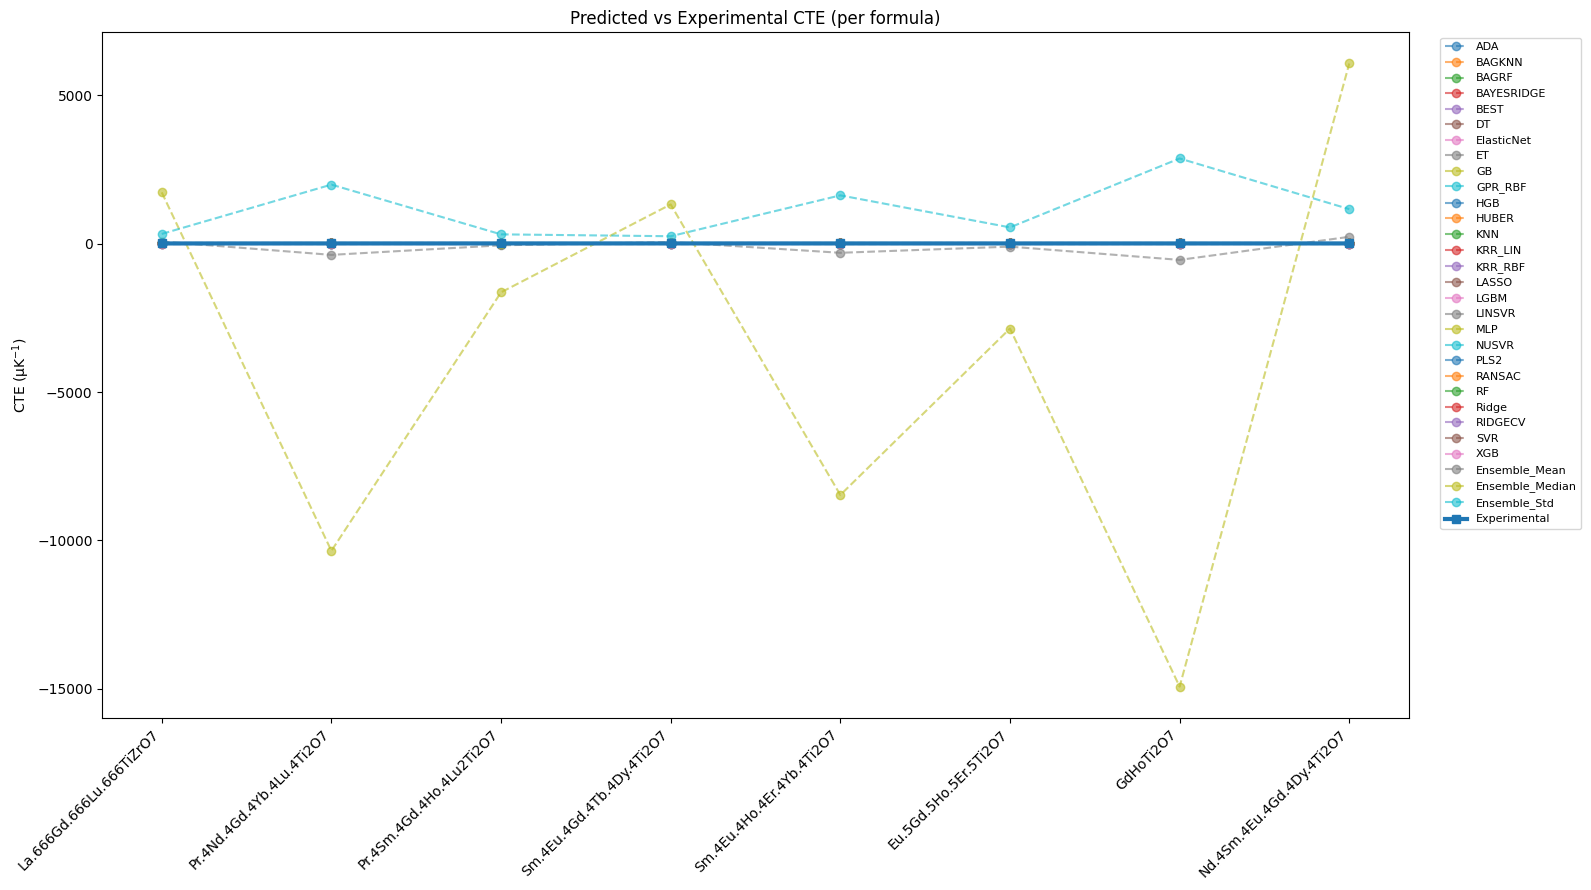

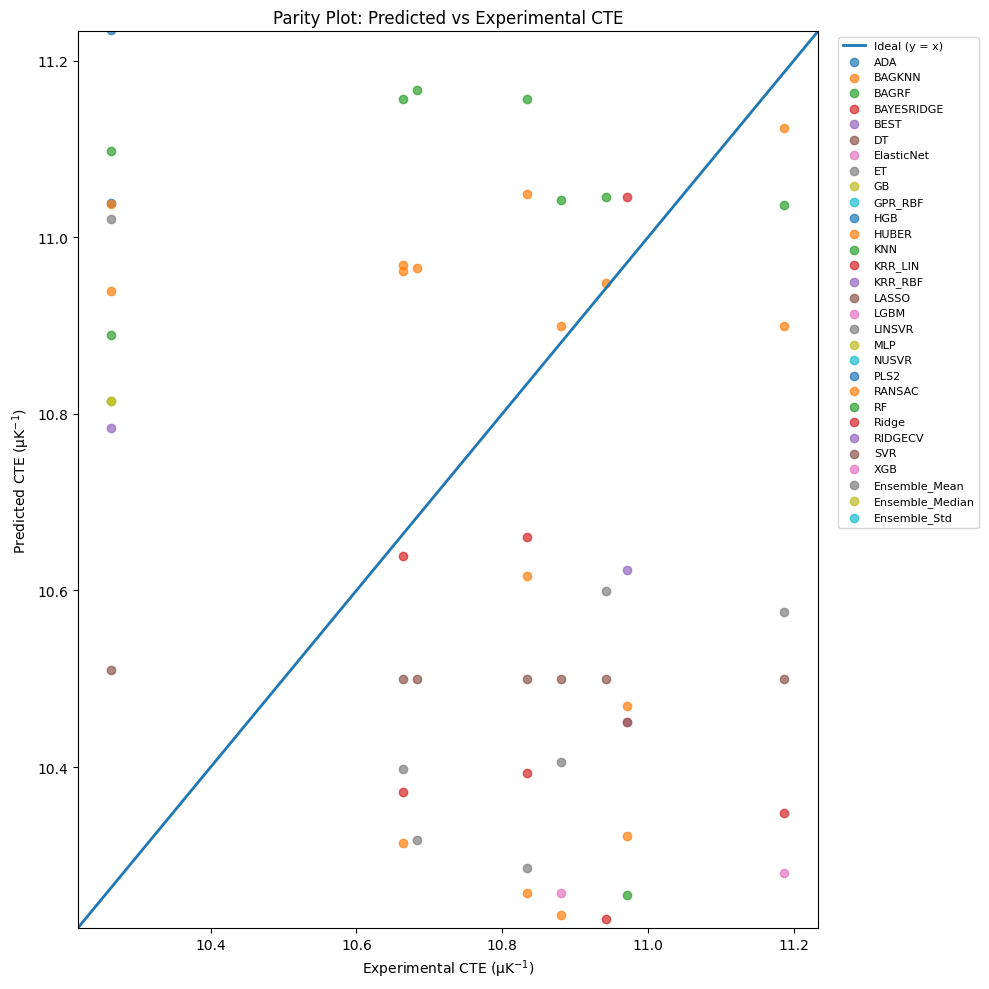

In [34]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- Experimental Data ----------------
experimental_data = {
    "La.666Gd.666Lu.666TiZrO7": 10.26370957e-6,
    "Pr.4Nd.4Gd.4Yb.4Lu.4Ti2O7": 10.8812864e-6,
    "Pr.4Sm.4Gd.4Ho.4Lu2Ti2O7": 10.97135822e-6,
    "Sm.4Eu.4Gd.4Tb.4Dy.4Ti2O7": 11.18713217e-6,
    "Sm.4Eu.4Ho.4Er.4Yb.4Ti2O7": 10.83446e-6,
    "Eu.5Gd.5Ho.5Er.5Ti2O7":     10.66338e-6,
    "GdHoTi2O7":                 10.68365e-6,
    "Nd.4Sm.4Eu.4Gd.4Dy.4Ti2O7": 10.94286e-6,
}

# ---------------- Load predictions ----------------
# Preferred wide CSV produced by the "predict all models" script
PRED_ALL = "cte_predictions_all_models.csv"
# Legacy RF-only CSV (fallback)
PRED_RF_ONLY = "cte_predictions_new_materials.csv"

if os.path.exists(PRED_ALL):
    preds = pd.read_csv(PRED_ALL)
    # Identify model columns (exclude non-prediction columns)
    non_model_cols = {"Formula"}
    model_cols = [c for c in preds.columns if c not in non_model_cols]
    # If ensemble columns exist, keep them too for plotting and metrics
else:
    # Fallback to legacy single-model CSV; rename to "RF"
    preds = pd.read_csv(PRED_RF_ONLY).rename(columns={"Predicted_CTE": "RF"})
    model_cols = [c for c in preds.columns if c not in {"Formula"}]

if "Formula" not in preds.columns:
    raise ValueError("Predictions file must contain a 'Formula' column.")

# ---------------- Merge with experimental ----------------
preds["Experimental"] = preds["Formula"].map(experimental_data)
df = preds.dropna(subset=["Experimental"]).copy()
if df.empty:
    raise RuntimeError("No overlap between predictions and experimental_data formulas.")

# Optional: display which formulas are used
print("Formulas matched with experimental data:")
print(df["Formula"].tolist())

# ---------------- Optional units: plot in micro (1e-6) if desired ----------------
# Set to True if you want the y-axis in µK^-1 instead of K^-1
PLOT_IN_MICRO = True
scale = 1e6 if PLOT_IN_MICRO else 1.0
ylabel = "CTE (µK$^{-1}$)" if PLOT_IN_MICRO else "CTE (K$^{-1}$)"

df_plot = df.copy()
for c in model_cols + ["Experimental"]:
    if c in df_plot.columns:
        df_plot[c] = df_plot[c] * scale

# ---------------- Metrics per model ----------------
def rmse(a, b):
    return float(np.sqrt(np.mean((np.array(a) - np.array(b))**2)))

def mae(a, b):
    return float(np.mean(np.abs(np.array(a) - np.array(b))))

def r2(a, b):
    a = np.array(a); b = np.array(b)
    ss_res = np.sum((a - b)**2)
    ss_tot = np.sum((b - np.mean(b))**2)
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else float("nan")

metrics_rows = []
for m in model_cols:
    if m not in df_plot.columns:
        continue
    yhat = df_plot[m].values
    yexp = df_plot["Experimental"].values
    metrics_rows.append({
        "Model": m,
        "R2": r2(yhat, yexp),
        f"MAE ({ylabel})": mae(yhat, yexp),
        f"RMSE ({ylabel})": rmse(yhat, yexp),
    })
metrics = pd.DataFrame(metrics_rows).sort_values(by=f"RMSE ({ylabel})")
metrics.to_csv("cte_model_eval_vs_experimental.csv", index=False)
print("\nSaved metrics → cte_model_eval_vs_experimental.csv")
print(metrics)

# ---------------- Plot 1: per-formula line chart ----------------
plt.figure(figsize=(16, 9))
x = np.arange(len(df_plot))
for m in model_cols:
    if m in df_plot.columns:
        plt.plot(x, df_plot[m].values, marker="o", linestyle="--", alpha=0.6, label=m)

plt.plot(x, df_plot["Experimental"].values, marker="s", linewidth=3, label="Experimental")
plt.xticks(x, df_plot["Formula"].tolist(), rotation=45, ha="right")
plt.ylabel(ylabel)
plt.title("Predicted vs Experimental CTE (per formula)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

# ---------------- Plot 2: parity (ŷ vs y) ----------------
plt.figure(figsize=(10, 10))
yexp = df_plot["Experimental"].values
min_y = float(np.min(yexp))
max_y = float(np.max(yexp))
pad = 0.05 * (max_y - min_y if max_y > min_y else 1.0)
lo, hi = min_y - pad, max_y + pad

# 1:1 line
plt.plot([lo, hi], [lo, hi], linewidth=2, label="Ideal (y = x)")

# Each model as a scatter
for m in model_cols:
    if m in df_plot.columns:
        plt.scatter(yexp, df_plot[m].values, alpha=0.7, label=m)

plt.xlabel(f"Experimental {ylabel}")
plt.ylabel(f"Predicted {ylabel}")
plt.title("Parity Plot: Predicted vs Experimental CTE")
plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


Formulas matched with experimental data:
['La.666Gd.666Lu.666TiZrO7', 'Pr.4Nd.4Gd.4Yb.4Lu.4Ti2O7', 'Pr.4Sm.4Gd.4Ho.4Lu2Ti2O7', 'Sm.4Eu.4Gd.4Tb.4Dy.4Ti2O7', 'Sm.4Eu.4Ho.4Er.4Yb.4Ti2O7', 'Eu.5Gd.5Ho.5Er.5Ti2O7', 'GdHoTi2O7', 'Nd.4Sm.4Eu.4Gd.4Dy.4Ti2O7']

Saved metrics → cte_model_eval_vs_experimental.csv
              Model                  R2  MAE (CTE (µK$^{-1}$))  \
0            BAGKNN         -1.49829192             0.31604814   
1               KNN         -2.50336667             0.40772331   
2        BAYESRIDGE         -3.74072220             0.46301964   
3                ET         -6.35495286             0.60132535   
4             Ridge         -7.20912712             0.63226635   
5             NUSVR         -7.36244435             0.69652045   
6             HUBER         -7.98979012             0.70025621   
7            RANSAC         -8.64443039             0.61411590   
8           RIDGECV        -15.23744132             0.95833720   
9             LASSO        -18.27824

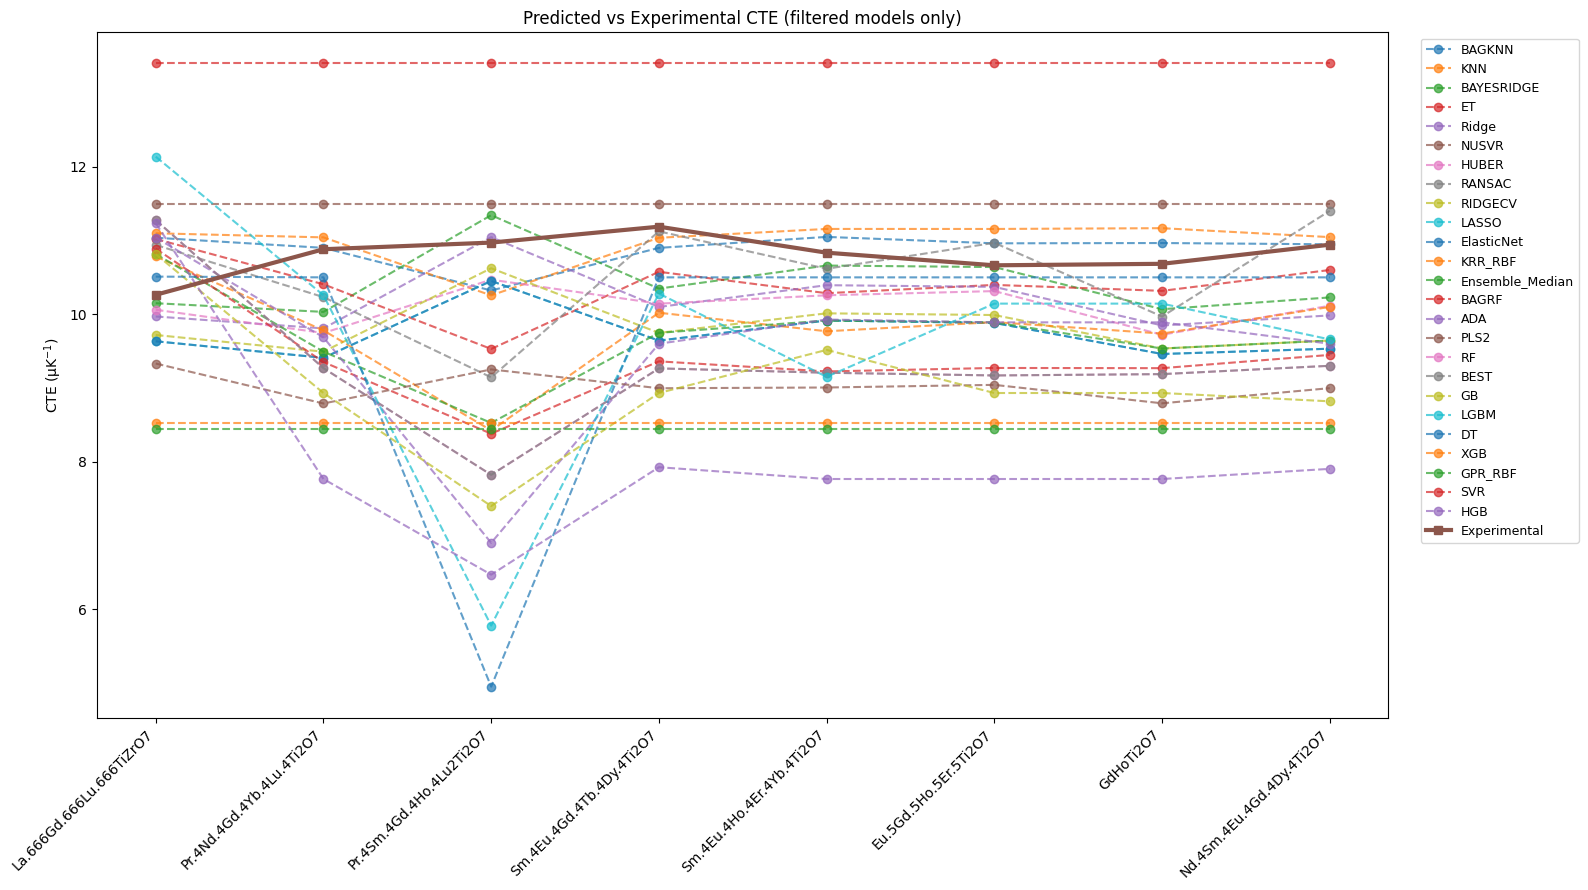

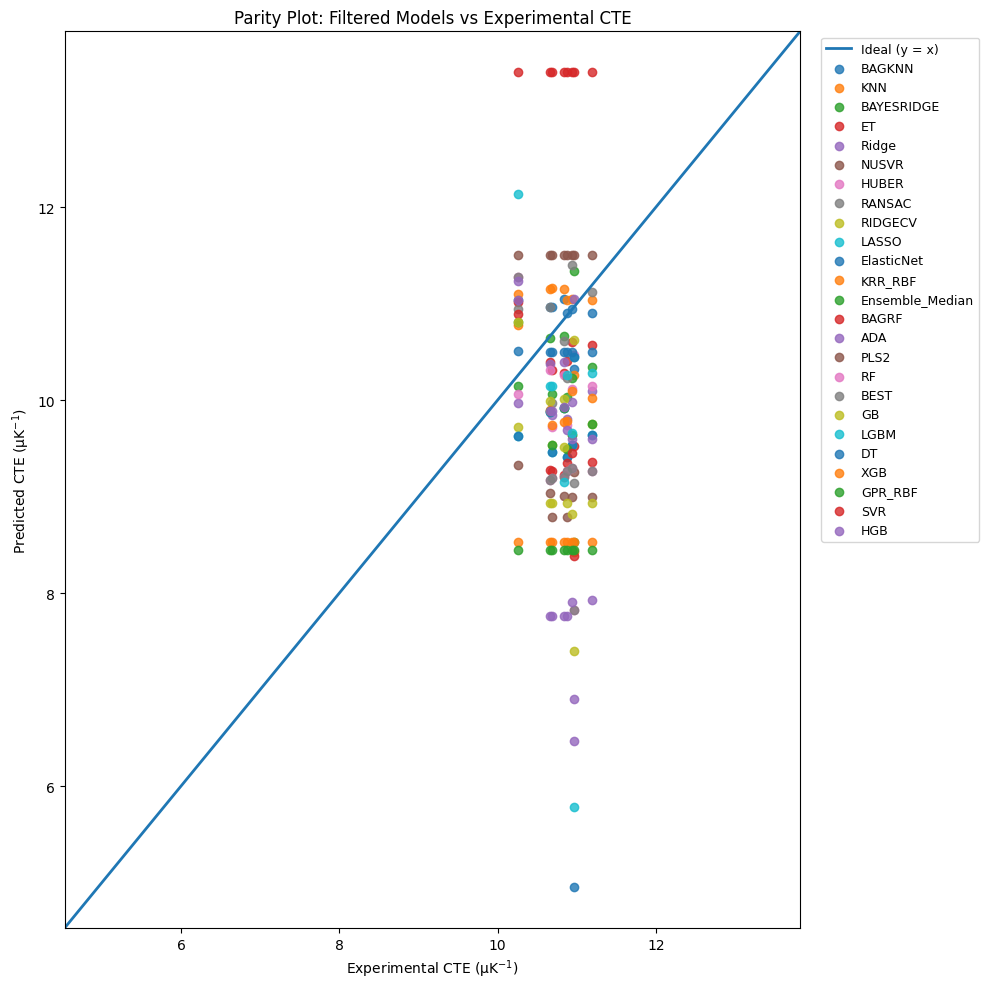

In [35]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- User-tunable parameters ----------------
PLOT_IN_MICRO = True          # Plot in µK^-1 for readability
ABS_ERR_CAP_MICRO = None      # e.g., 3.0 means discard any model whose max |error| > 3 µK^-1; set None to disable
MIN_MODELS_TO_PLOT = 3        # If filters remove everything, keep best N by RMSE
LEGEND_MAX_COLS = 1           # Adjust legend layout if many models pass
# ---------------------------------------------------------

# ---------------- Experimental Data ----------------
experimental_data = {
    "La.666Gd.666Lu.666TiZrO7": 10.26370957e-6,
    "Pr.4Nd.4Gd.4Yb.4Lu.4Ti2O7": 10.8812864e-6,
    "Pr.4Sm.4Gd.4Ho.4Lu2Ti2O7": 10.97135822e-6,
    "Sm.4Eu.4Gd.4Tb.4Dy.4Ti2O7": 11.18713217e-6,
    "Sm.4Eu.4Ho.4Er.4Yb.4Ti2O7": 10.83446e-6,
    "Eu.5Gd.5Ho.5Er.5Ti2O7":     10.66338e-6,
    "GdHoTi2O7":                 10.68365e-6,
    "Nd.4Sm.4Eu.4Gd.4Dy.4Ti2O7": 10.94286e-6,
}

# ---------------- Load predictions ----------------
PRED_ALL = "cte_predictions_all_models.csv"
PRED_RF_ONLY = "cte_predictions_new_materials.csv"  # fallback

if os.path.exists(PRED_ALL):
    preds = pd.read_csv(PRED_ALL)
    non_model_cols = {"Formula"}
    model_cols = [c for c in preds.columns if c not in non_model_cols]
else:
    preds = pd.read_csv(PRED_RF_ONLY).rename(columns={"Predicted_CTE": "RF"})
    model_cols = [c for c in preds.columns if c not in {"Formula"}]

if "Formula" not in preds.columns:
    raise ValueError("Predictions file must contain a 'Formula' column.")

# ---------------- Merge with experimental ----------------
preds["Experimental"] = preds["Formula"].map(experimental_data)
df = preds.dropna(subset=["Experimental"]).copy()
if df.empty:
    raise RuntimeError("No overlap between predictions and experimental_data formulas.")

print("Formulas matched with experimental data:")
print(df["Formula"].tolist())

# ---------------- Units ----------------
scale = 1e6 if PLOT_IN_MICRO else 1.0
ylabel = "CTE (µK$^{-1}$)" if PLOT_IN_MICRO else "CTE (K$^{-1}$)"
df_plot = df.copy()
for c in model_cols + ["Experimental"]:
    if c in df_plot.columns:
        df_plot[c] = df_plot[c] * scale

# ---------------- Metrics per model ----------------
def rmse(a, b):
    a = np.asarray(a); b = np.asarray(b)
    return float(np.sqrt(np.mean((a - b) ** 2)))

def mae(a, b):
    a = np.asarray(a); b = np.asarray(b)
    return float(np.mean(np.abs(a - b)))

def r2(a, b):
    a = np.asarray(a); b = np.asarray(b)
    ss_res = np.sum((a - b) ** 2)
    ss_tot = np.sum((b - np.mean(b)) ** 2)
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else float("nan")

yexp = df_plot["Experimental"].values

rows = []
per_model_max_abs_err = {}
for m in model_cols:
    if m not in df_plot.columns:
        continue
    yhat = df_plot[m].values
    rows.append({"Model": m,
                 "R2": r2(yhat, yexp),
                 f"MAE ({ylabel})": mae(yhat, yexp),
                 f"RMSE ({ylabel})": rmse(yhat, yexp)})
    per_model_max_abs_err[m] = float(np.max(np.abs(yhat - yexp)))

metrics = pd.DataFrame(rows).sort_values(by=f"RMSE ({ylabel})").reset_index(drop=True)
metrics.to_csv("cte_model_eval_vs_experimental.csv", index=False)
print("\nSaved metrics → cte_model_eval_vs_experimental.csv")
print(metrics)

# ---------------- Model filtering (hide outliers) ----------------
# 1) Robust global filter via Tukey fence on RMSE (keeps models near the bulk)
rmse_col = f"RMSE ({ylabel})"
q1 = metrics[rmse_col].quantile(0.25)
q3 = metrics[rmse_col].quantile(0.75)
iqr = q3 - q1
tukey_upper = q3 + 1.5 * iqr
mask_tukey = metrics[rmse_col] <= tukey_upper

# 2) Optional per-point absolute error cap (e.g., 3 µK^-1)
if ABS_ERR_CAP_MICRO is not None and PLOT_IN_MICRO:
    mask_abs = metrics["Model"].map(lambda m: per_model_max_abs_err.get(m, np.inf) <= ABS_ERR_CAP_MICRO)
    mask = mask_tukey & mask_abs
else:
    mask = mask_tukey

filtered = metrics[mask].copy()

# Ensure we keep at least a few models
if filtered.empty:
    filtered = metrics.head(MIN_MODELS_TO_PLOT).copy()

selected_models = filtered["Model"].tolist()
print("\nModels plotted (filtered):", selected_models)

# Save filtered predictions table for convenience
keep_cols = ["Formula", "Experimental"] + [m for m in selected_models if m in df_plot.columns]
df_plot[keep_cols].to_csv("cte_predictions_filtered_models.csv", index=False)
print("Saved filtered predictions → cte_predictions_filtered_models.csv")

# ---------------- Plot 1: per-formula line chart (only selected models) ----------------
plt.figure(figsize=(16, 9))
x = np.arange(len(df_plot))
for m in selected_models:
    if m in df_plot.columns:
        plt.plot(x, df_plot[m].values, marker="o", linestyle="--", alpha=0.7, label=m)
plt.plot(x, df_plot["Experimental"].values, marker="s", linewidth=3, label="Experimental")
plt.xticks(x, df_plot["Formula"].tolist(), rotation=45, ha="right")
plt.ylabel(ylabel)
plt.title("Predicted vs Experimental CTE (filtered models only)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9, ncol=LEGEND_MAX_COLS)
plt.tight_layout()
plt.show()

# ---------------- Plot 2: parity (ŷ vs y) for filtered models ----------------
plt.figure(figsize=(10, 10))
lo = float(min(df_plot["Experimental"].min(),
               *(df_plot[m].min() for m in selected_models if m in df_plot.columns)))
hi = float(max(df_plot["Experimental"].max(),
               *(df_plot[m].max() for m in selected_models if m in df_plot.columns)))
pad = 0.05 * (hi - lo if hi > lo else 1.0)
lo, hi = lo - pad, hi + pad

plt.plot([lo, hi], [lo, hi], linewidth=2, label="Ideal (y = x)")
for m in selected_models:
    if m in df_plot.columns:
        plt.scatter(yexp, df_plot[m].values, alpha=0.8, label=m)

plt.xlabel(f"Experimental {ylabel}")
plt.ylabel(f"Predicted {ylabel}")
plt.title("Parity Plot: Filtered Models vs Experimental CTE")
plt.xlim(lo, hi); plt.ylim(lo, hi)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9, ncol=LEGEND_MAX_COLS)
plt.tight_layout()
plt.show()



BAGKNN vs Experimental:
  R²   = -1.4983
  MAE  = 0.31605 CTE (µK$^{-1}$)
  RMSE = 0.40574 CTE (µK$^{-1}$)


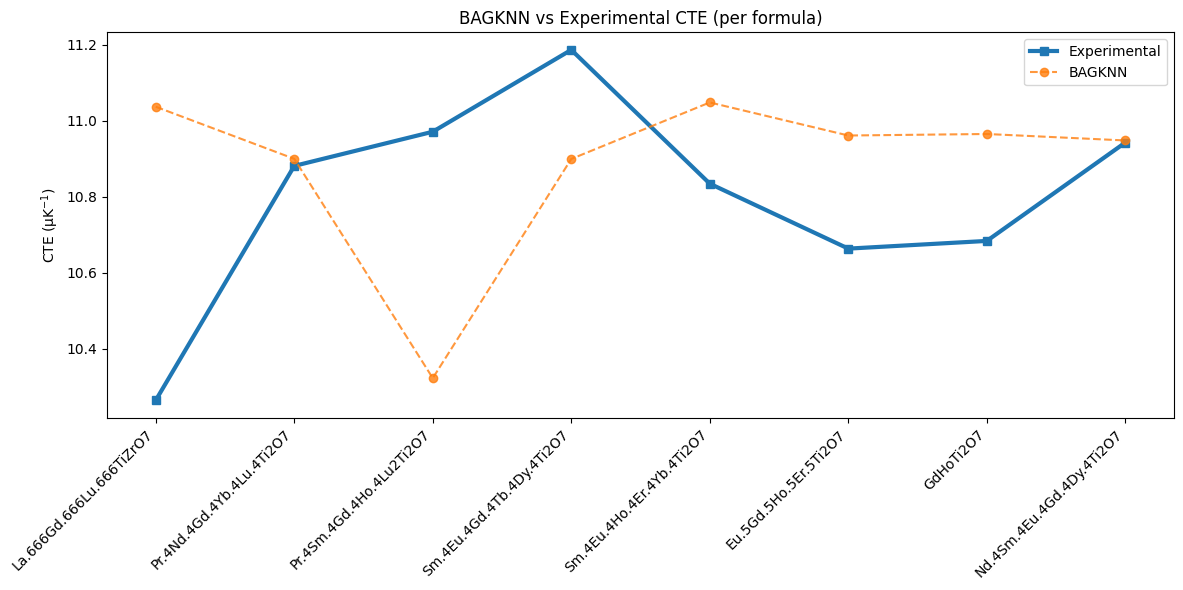

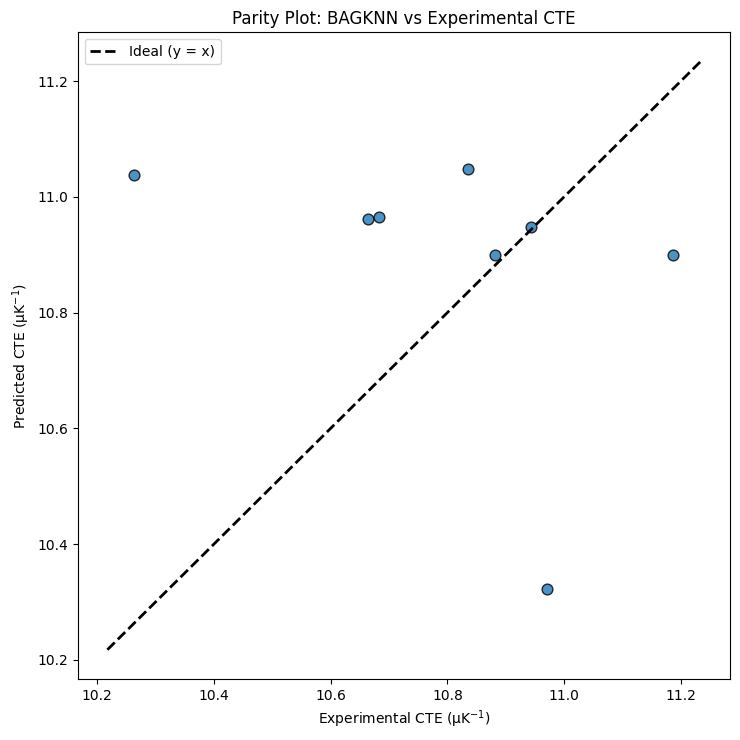

In [37]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- Experimental Data ----------------
experimental_data = {
    "La.666Gd.666Lu.666TiZrO7": 10.26370957e-6,
    "Pr.4Nd.4Gd.4Yb.4Lu.4Ti2O7": 10.8812864e-6,
    "Pr.4Sm.4Gd.4Ho.4Lu2Ti2O7": 10.97135822e-6,
    "Sm.4Eu.4Gd.4Tb.4Dy.4Ti2O7": 11.18713217e-6,
    "Sm.4Eu.4Ho.4Er.4Yb.4Ti2O7": 10.83446e-6,
    "Eu.5Gd.5Ho.5Er.5Ti2O7":     10.66338e-6,
    "GdHoTi2O7":                 10.68365e-6,
    "Nd.4Sm.4Eu.4Gd.4Dy.4Ti2O7": 10.94286e-6,
}

# ---------------- Load predictions ----------------
PRED_FILE = "cte_predictions_all_models.csv"
if not os.path.exists(PRED_FILE):
    raise FileNotFoundError(f"{PRED_FILE} not found — make sure the multi-model file is in this directory.")

df = pd.read_csv(PRED_FILE)

if "Formula" not in df.columns or "BAGKNN" not in df.columns:
    raise ValueError("The file must contain 'Formula' and 'BAGKNN' columns.")

# ---------------- Merge with experimental ----------------
df["Experimental"] = df["Formula"].map(experimental_data)
df = df.dropna(subset=["Experimental"]).copy()
if df.empty:
    raise RuntimeError("No overlap between BAGKNN predictions and experimental formulas.")

# ---------------- Unit scaling ----------------
PLOT_IN_MICRO = True
scale = 1e6 if PLOT_IN_MICRO else 1.0
ylabel = "CTE (µK$^{-1}$)" if PLOT_IN_MICRO else "CTE (K$^{-1}$)"
df["Predicted_plot"] = df["BAGKNN"] * scale
df["Experimental_plot"] = df["Experimental"] * scale

# ---------------- Metrics ----------------
def rmse(a, b): return np.sqrt(np.mean((np.array(a) - np.array(b)) ** 2))
def mae(a, b):  return np.mean(np.abs(np.array(a) - np.array(b)))
def r2(a, b):
    a = np.array(a); b = np.array(b)
    ss_res = np.sum((a - b) ** 2); ss_tot = np.sum((b - np.mean(b)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

yhat, yexp = df["Predicted_plot"], df["Experimental_plot"]
print("\nBAGKNN vs Experimental:")
print(f"  R²   = {r2(yhat, yexp):.4f}")
print(f"  MAE  = {mae(yhat, yexp):.5f} {ylabel}")
print(f"  RMSE = {rmse(yhat, yexp):.5f} {ylabel}")

# ---------------- Plot 1: Per-formula comparison ----------------
plt.figure(figsize=(12, 6))
x = np.arange(len(df))
plt.plot(x, df["Experimental_plot"], marker="s", linewidth=3, label="Experimental")
plt.plot(x, df["Predicted_plot"], marker="o", linestyle="--", alpha=0.8, label="BAGKNN")
plt.xticks(x, df["Formula"], rotation=45, ha="right")
plt.ylabel(ylabel)
plt.title("BAGKNN vs Experimental CTE (per formula)")
plt.legend()
plt.tight_layout()
plt.show()

# ---------------- Plot 2: Parity plot ----------------
plt.figure(figsize=(7.5, 7.5))
lo = min(yexp.min(), yhat.min())
hi = max(yexp.max(), yhat.max())
pad = 0.05 * (hi - lo)
plt.plot([lo - pad, hi + pad], [lo - pad, hi + pad], 'k--', lw=2, label="Ideal (y = x)")
plt.scatter(yexp, yhat, s=60, color='tab:blue', edgecolor='k', alpha=0.8)
plt.xlabel(f"Experimental {ylabel}")
plt.ylabel(f"Predicted {ylabel}")
plt.title("Parity Plot: BAGKNN vs Experimental CTE")
plt.legend()
plt.tight_layout()
plt.show()



Ridge vs Experimental:
  R²   = -7.2091
  MAE  = 0.63227 CTE (µK$^{-1}$)
  RMSE = 0.73548 CTE (µK$^{-1}$)


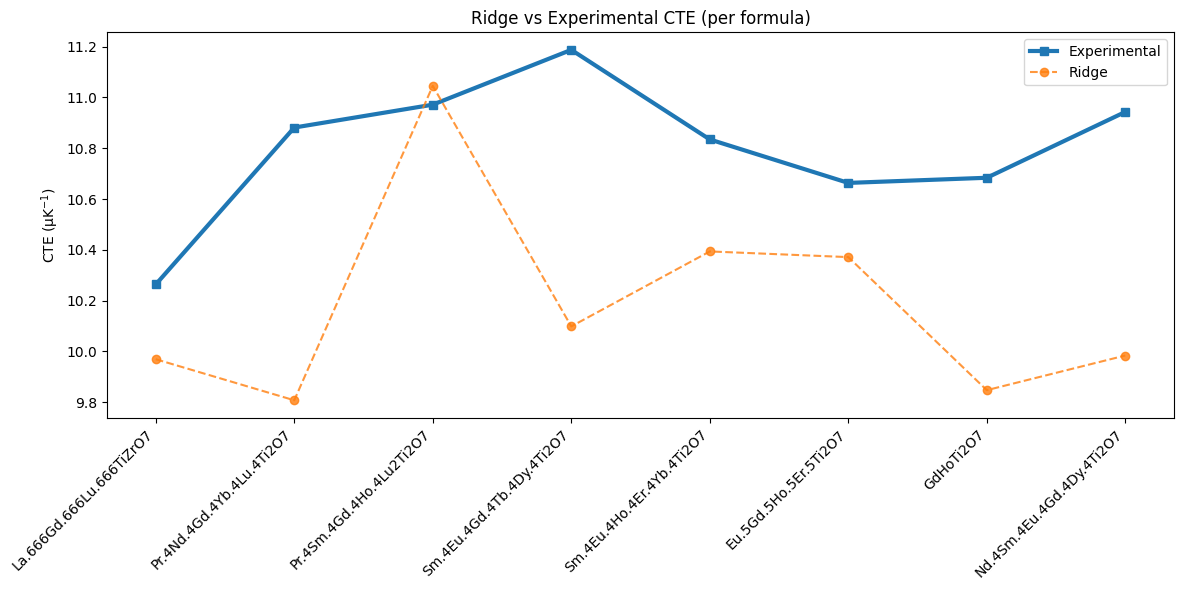

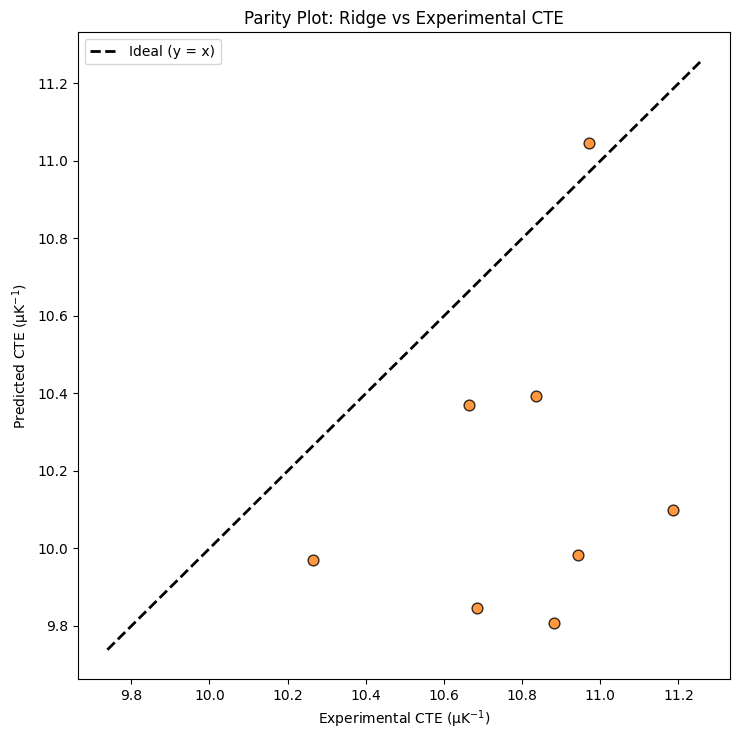

In [38]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- Experimental Data ----------------
experimental_data = {
    "La.666Gd.666Lu.666TiZrO7": 10.26370957e-6,
    "Pr.4Nd.4Gd.4Yb.4Lu.4Ti2O7": 10.8812864e-6,
    "Pr.4Sm.4Gd.4Ho.4Lu2Ti2O7": 10.97135822e-6,
    "Sm.4Eu.4Gd.4Tb.4Dy.4Ti2O7": 11.18713217e-6,
    "Sm.4Eu.4Ho.4Er.4Yb.4Ti2O7": 10.83446e-6,
    "Eu.5Gd.5Ho.5Er.5Ti2O7":     10.66338e-6,
    "GdHoTi2O7":                 10.68365e-6,
    "Nd.4Sm.4Eu.4Gd.4Dy.4Ti2O7": 10.94286e-6,
}

# ---------------- Load predictions ----------------
PRED_FILE = "cte_predictions_all_models.csv"
if not os.path.exists(PRED_FILE):
    raise FileNotFoundError(f"{PRED_FILE} not found — make sure the multi-model file is in this directory.")

df = pd.read_csv(PRED_FILE)

if "Formula" not in df.columns or "Ridge" not in df.columns:
    raise ValueError("The file must contain 'Formula' and 'Ridge' columns.")

# ---------------- Merge with experimental ----------------
df["Experimental"] = df["Formula"].map(experimental_data)
df = df.dropna(subset=["Experimental"]).copy()
if df.empty:
    raise RuntimeError("No overlap between Ridge predictions and experimental formulas.")

# ---------------- Unit scaling ----------------
PLOT_IN_MICRO = True
scale = 1e6 if PLOT_IN_MICRO else 1.0
ylabel = "CTE (µK$^{-1}$)" if PLOT_IN_MICRO else "CTE (K$^{-1}$)"
df["Predicted_plot"] = df["Ridge"] * scale
df["Experimental_plot"] = df["Experimental"] * scale

# ---------------- Metrics ----------------
def rmse(a, b): return np.sqrt(np.mean((np.array(a) - np.array(b)) ** 2))
def mae(a, b):  return np.mean(np.abs(np.array(a) - np.array(b)))
def r2(a, b):
    a = np.array(a); b = np.array(b)
    ss_res = np.sum((a - b) ** 2); ss_tot = np.sum((b - np.mean(b)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

yhat, yexp = df["Predicted_plot"], df["Experimental_plot"]
print("\nRidge vs Experimental:")
print(f"  R²   = {r2(yhat, yexp):.4f}")
print(f"  MAE  = {mae(yhat, yexp):.5f} {ylabel}")
print(f"  RMSE = {rmse(yhat, yexp):.5f} {ylabel}")

# ---------------- Plot 1: Per-formula comparison ----------------
plt.figure(figsize=(12, 6))
x = np.arange(len(df))
plt.plot(x, df["Experimental_plot"], marker="s", linewidth=3, label="Experimental")
plt.plot(x, df["Predicted_plot"], marker="o", linestyle="--", alpha=0.8, label="Ridge")
plt.xticks(x, df["Formula"], rotation=45, ha="right")
plt.ylabel(ylabel)
plt.title("Ridge vs Experimental CTE (per formula)")
plt.legend()
plt.tight_layout()
plt.show()

# ---------------- Plot 2: Parity plot ----------------
plt.figure(figsize=(7.5, 7.5))
lo = min(yexp.min(), yhat.min())
hi = max(yexp.max(), yhat.max())
pad = 0.05 * (hi - lo)
plt.plot([lo - pad, hi + pad], [lo - pad, hi + pad], 'k--', lw=2, label="Ideal (y = x)")
plt.scatter(yexp, yhat, s=60, color='tab:orange', edgecolor='k', alpha=0.8)
plt.xlabel(f"Experimental {ylabel}")
plt.ylabel(f"Predicted {ylabel}")
plt.title("Parity Plot: Ridge vs Experimental CTE")
plt.legend()
plt.tight_layout()
plt.show()
